# DATASCI 267 - GenAI - Assignment 5

### Overview

In Assignment 5 you will create and test a RAG system yourself as a proof of concept and then write a corresponding business report on your findings.

The overall scenario is as follows:

You work at a tech company that is looking for new ways to organize their question answering and search capabilities to accelerate both engineering activity and the marketing team's production.  Founded in 2018, your company has grown rapidly to 300 engineers across distributed teams in San Francisco, Austin, and remotely, plus a 40-person marketing organization split between demand generation, content, product marketing, and customer education. The company also wants to roll out new GenAI-based products, so a lot of the questions will center around Generative AI concepts. Product releases are done quarterly.

As a Senior ML Engineer on your company's newly formed AI Infrastructure team, you've been tapped to lead a four-week proof-of-concept (mini-POC) evaluating whether a Retrieval-Augmented Generation (RAG) system could address the challenges and support both the engineering and marketing organizations. Your executive sponsor is the VP of Engineering, who has secured buy-in from the CMO and allocated a small budget for this exploratory work.

Your POC needs to demonstrate:

**Engineering use case**: Can RAG effectively answer technical questions about GenAI concepts, internal system architecture, and implementation details by retrieving from diverse documentation sources?

**Marketing use case**: Can RAG help marketing staff quickly find accurate, approved messaging about GenAI features, competitive positioning, and technical capabilities to accelerate content production?

**Practical viability**: What are the implementation complexities, accuracy levels, and user experience considerations? Is this worth a larger investment?

Success will be measured by demonstrated accuracy compared to ground truth answers and a clear recommendation on whether to proceed with a full implementation.  If recommended, then a qualitative test will be conducted to get feedback from a small pilot group (5 engineers, 3 marketers).


You will receive a gold dataset with 'good' responses to questions from marketing and engineering teams. You need to develop metric(s) that help you to evaluate how well your RAG system performs relative to the gold data. You should work with the tunable hyperparameters of the setup (LLM, chunking, embeddings, ...) for your iterations.

You will also need to write up your findings as a short 4-5 page proposal.

(See instructions throughout this notebook.)

So overall, the goals of this assignment are for you to:

*  Implement a RAG system using LangChain
*  Be able to formulate metric(s) that you may want to choose as your evaluation of the degree to which your system replicates gold answers (labeled data) that we will provide.
* Try out various hyper-parameters, settings, and other techniques to see which configuration works the best (given your chosen metric)  
* Write a comprehensive evaluation report, which also includes risks and limitations (and a lot more)

The notebook is organized as follows:

1. Set-Up

2. Base RAG components

    We will provide a base LangChain-based framework for you to use as inspiration for your RAG system. The components we’ll need include:  

  - 2.1 Text Embeddings    
  - 2.2 Text Chunking   
  - 2.3 The Vector DB & Semantic Search  
  - 2.4 The Language Model   
  - 2.5 Testing the LLM in a LangChain Chain   
  - 2.6. Setting up a simple RAG Chain     


3. Using RAG  

    We will provide a collection of documents for you to use for your RAG system. We will also provide a test of questions with "Gold" answers.  

  - 3.1 Loading of Data  
  - 3.2 Test Queries
  - 3.3 Running Your Implemented Model(s) and Your Experiments


4.  Evaluations

    Here, you will develop your strategy and conduct your evaluations of your RAG system

  - 4.1 Metrics
  - 4.2 Best Runs with Metrics


5. Final Results

    In this section, you will answer some questions and provide a link to your final report

  - 5.1 Model Specifications
  - 5.2 Three Test Questions (and Results)
  - 5.3 Five Other Questions
  - 5.4 Link To Your 4-5 Page Final POC Report and Recommendation

RULES:  

* You must only use the language models we specify here for the functions we specify
* You must only use the embedding models we specify here for the functions we specify
* You must use the vector store we specify here
* You must only use the document collection we provide. And they ALL must be in your vector store.   
* Apart from the provided specifications, you are free to experiment with a wide variety of hyperparameters (chunk sizes, prompts, etc.), langchain components (text splitters, retrievers, etc.)


**To run this notebook** you should copy it to your personal Colab Pro Google account by uploading it into your Google Drive. From there you can open it as a Colab notebook and run it.  Note: it needs a T4 GPU to run when you are working with all our data.  You can run sections 1 and 2 without the GPU to orient yourself to how LangChain RAG systems work. You should also be able to run it in a free Colab notebook.

NOTES:
* The Open Source Model we use is not trained for safety. So unsafe answers could be returned.


===========================================================================================================

## 1. Setup

We will first install a number of libraries and import what we will need.





In [ ]:
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)

In [ ]:

import torch
import os
import bs4
import json
import numpy as np
import time
import pandas as pd

#import os
#os.environ['USER_AGENT'] = 'MyLangChainApp/1.0'

from pprint import pprint

import locale
#from langchain_community.embeddings import HuggingFaceEmbeddings

from google.colab import userdata

In [ ]:
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning, module='jupyter_client')
locale.getpreferredencoding = lambda: "UTF-8"

In [ ]:
%%capture
#!pip install -U sentence_transformers
#evaluation
#!pip install bleurt  # skipping as it is too slow
#!pip install bert-score
#!pip install rouge-score
#!pip install spacy
#!pip install ragas

#from bleurt import score
#import numpy as np
#from bert_score import score as bert_score


import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
#from pathlib import Path

In [ ]:
# mount google drive
from google.colab import drive
drive.mount('/content/drive')


# Define your directory
output_folder = "/content/drive/MyDrive/MIDS_267/final_project/output/"
data_folder = "/content/drive/MyDrive/MIDS_267/final_project/data/"

Mounted at /content/drive


Add your keys from the secret store (do **NOT** print them out or leave them exposed as plaintext in your notebook!):

In [ ]:
#COHERE_API_KEY = userdata.get('COHERE_API_KEY')
#CLAUDE_API_KEY = userdata.get('CLAUDE_API_KEY')
OPENAI_API_KEY = userdata.get('OPENAI_API_KEY')
HF_TOKEN = userdata.get('HF_TOKEN')


## 4. Tests & Evaluations

Here you should evaluate the results. First, you should implement your evaluation metrics and then you should run evaluation tests. This is really your area, but key results to show are:

1) Your metrics of choice  
2) How  your various models compare to the labeled validation data.

Make sure you look at the results for the marketing team and the research team separately.

**Note:** You do not need to run all models against all labeled questions, as that may take some time. Just do that for a few models/configs, and test a larger set with a smaller subset. But if you use a subset you must justify why you are using that specific subset of questions.

**This is free form so you will need to create your own cells, text documentation as you need, etc.**

After you have implemented you evaluation strategy please answer the questions below in sections 4.1 and 4.2.

Please feel free to add more text and code cells as needed.



### Analysis for Experiment 1: Retriever Parameters with MDS

Metrics score file : metric_results_retriever_mds_1206.csv


MDS SCORE ANALYSIS - RETRIEVER PARAMETERS VISUALIZATION
✓ Loaded 450 rows
✓ Configurations: 15
✓ Questions: 15

RETRIEVER PARAMETERS MDS ANALYSIS SUMMARY

Overall MDS: 0.5254 (±0.3409)
   Median: 0.6745

Best Configuration: high_overlap_k5
   MDS: 0.6983

Best Chunk Setting: high_overlap
   MDS: 0.6472

Best K Value: k=7
   MDS: 0.5515

 Audience Comparison:
   Marketing: 0.4994
   Research:  0.5507
   Winner:    Research (+0.0513)

 Problem Questions (MDS < 0.40): [7, 11, 19]

 Rows with Zero MDS: 117 (26.0%)

GENERATING VISUALIZATIONS
✓ Saved: /content/drive/MyDrive/MIDS_267/final_project/output/retriever_mds_overview.png
✓ Saved: /content/drive/MyDrive/MIDS_267/final_project/output/retriever_mds_chunk_analysis.png
✓ Saved: /content/drive/MyDrive/MIDS_267/final_project/output/retriever_mds_question_analysis.png
✓ Saved: /content/drive/MyDrive/MIDS_267/final_project/output/retriever_mds_comparison.png
✓ Saved: /content/drive/MyDrive/MIDS_267/final_project/output/retriever_mds_paramet

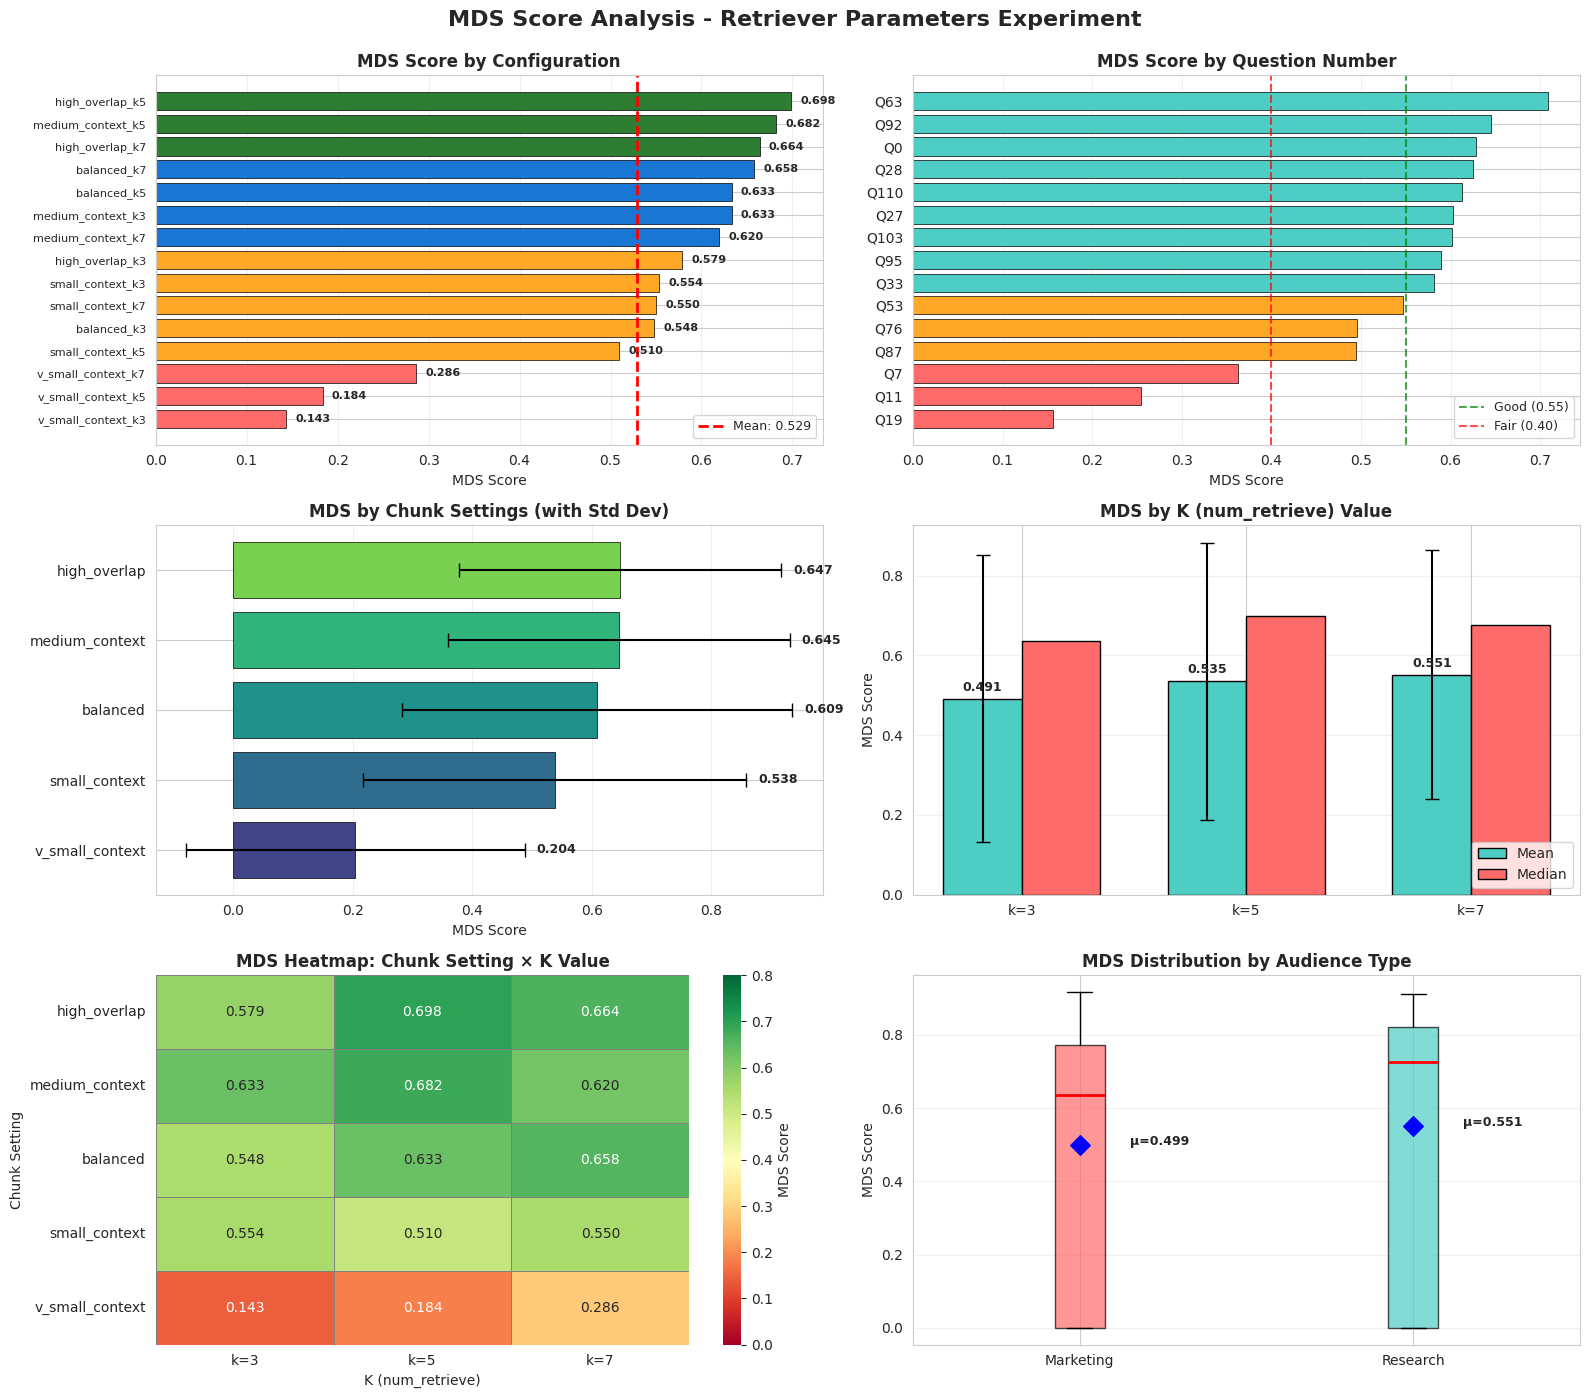

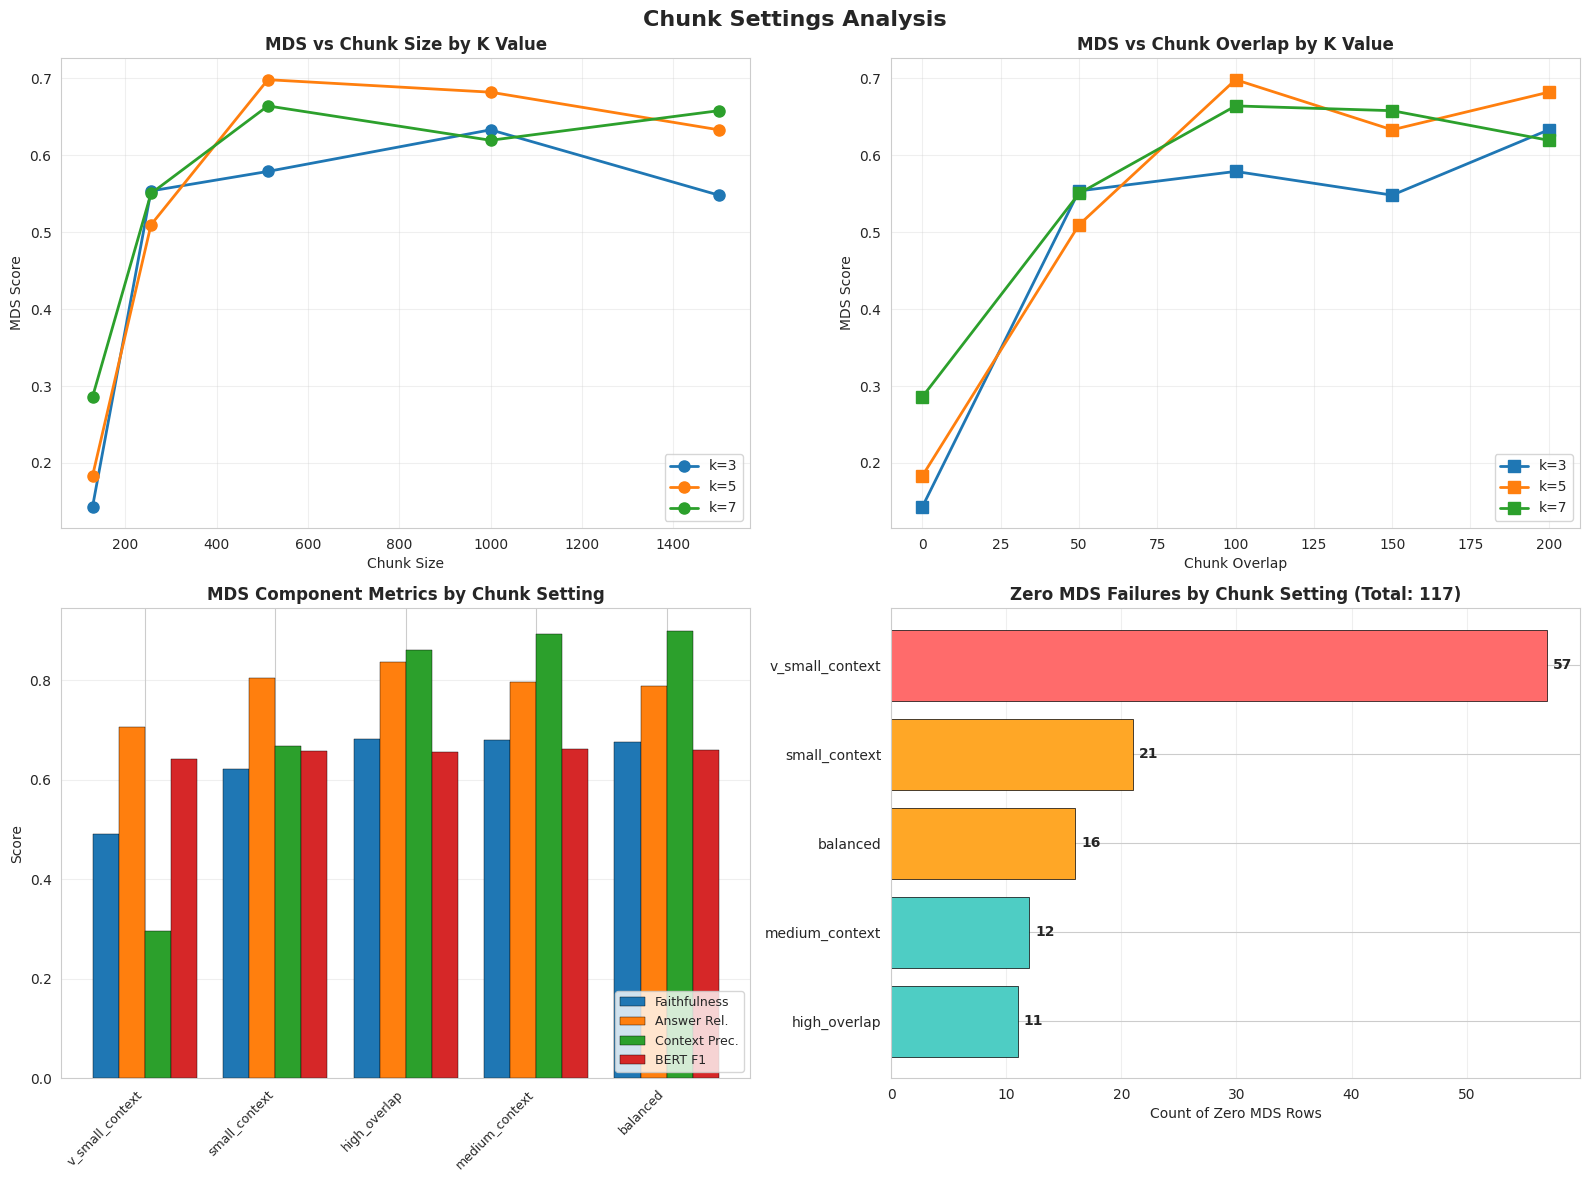

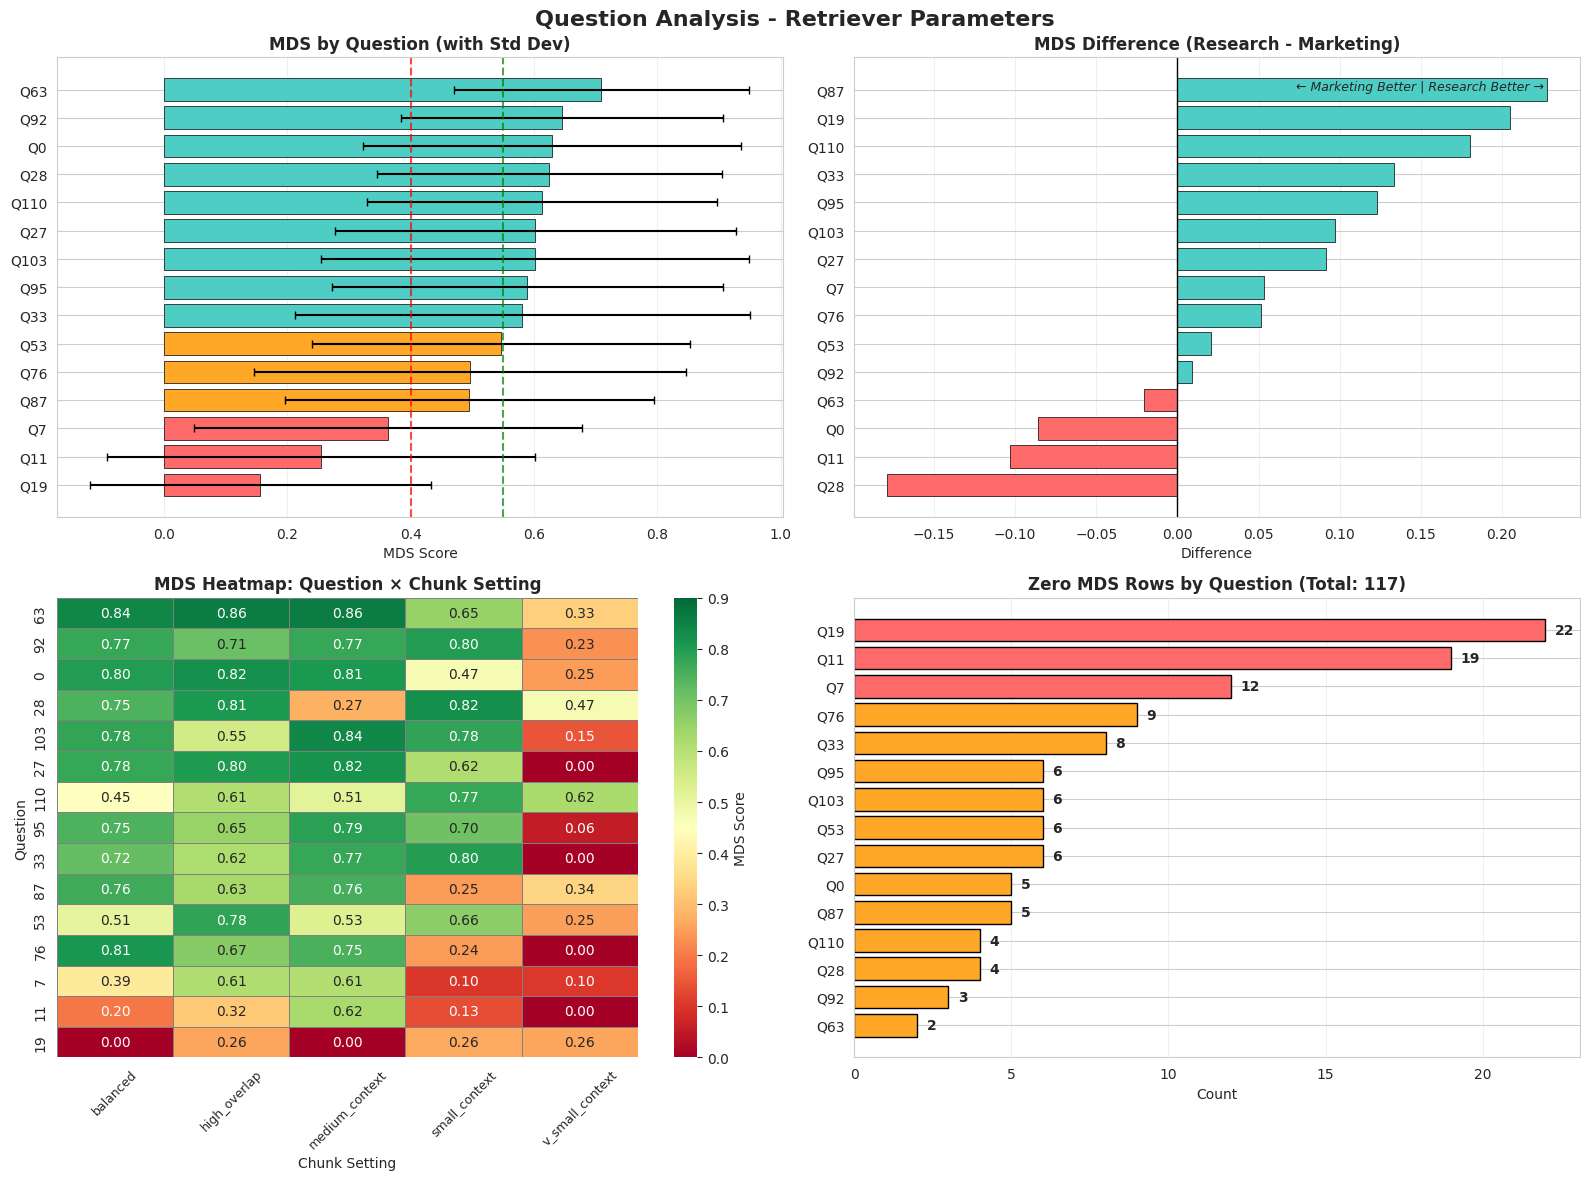

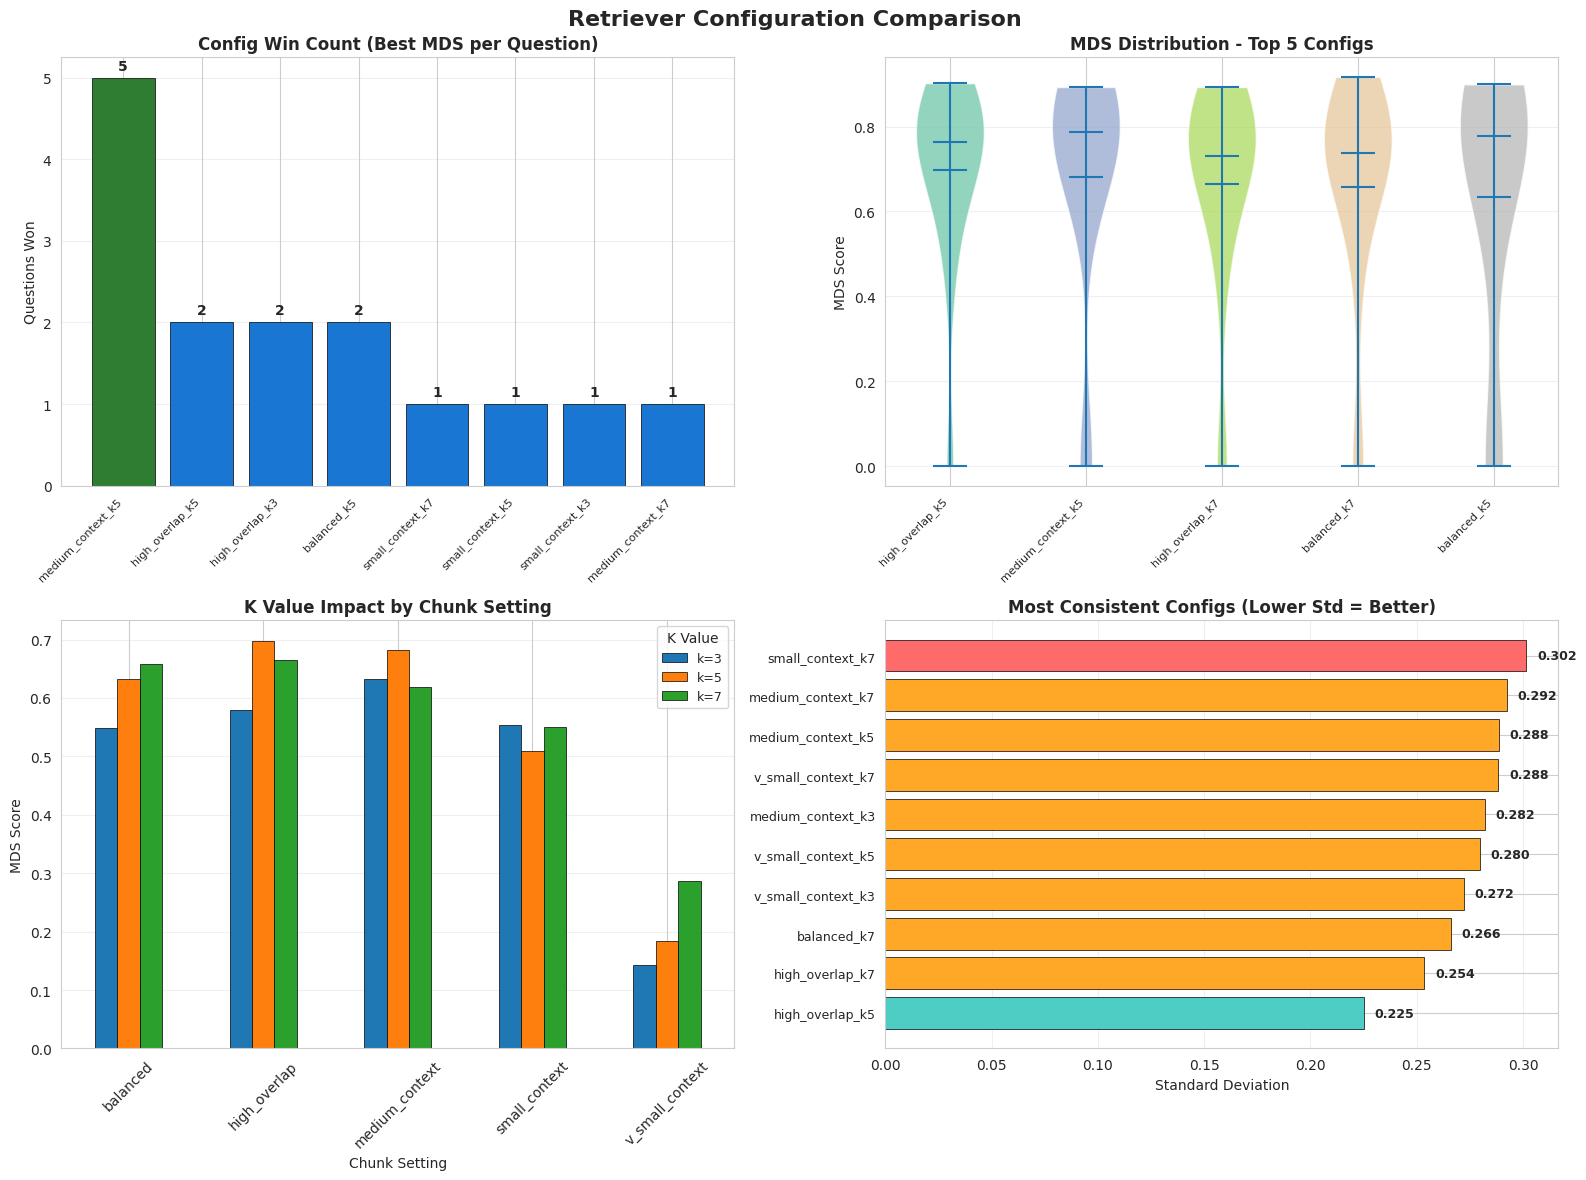

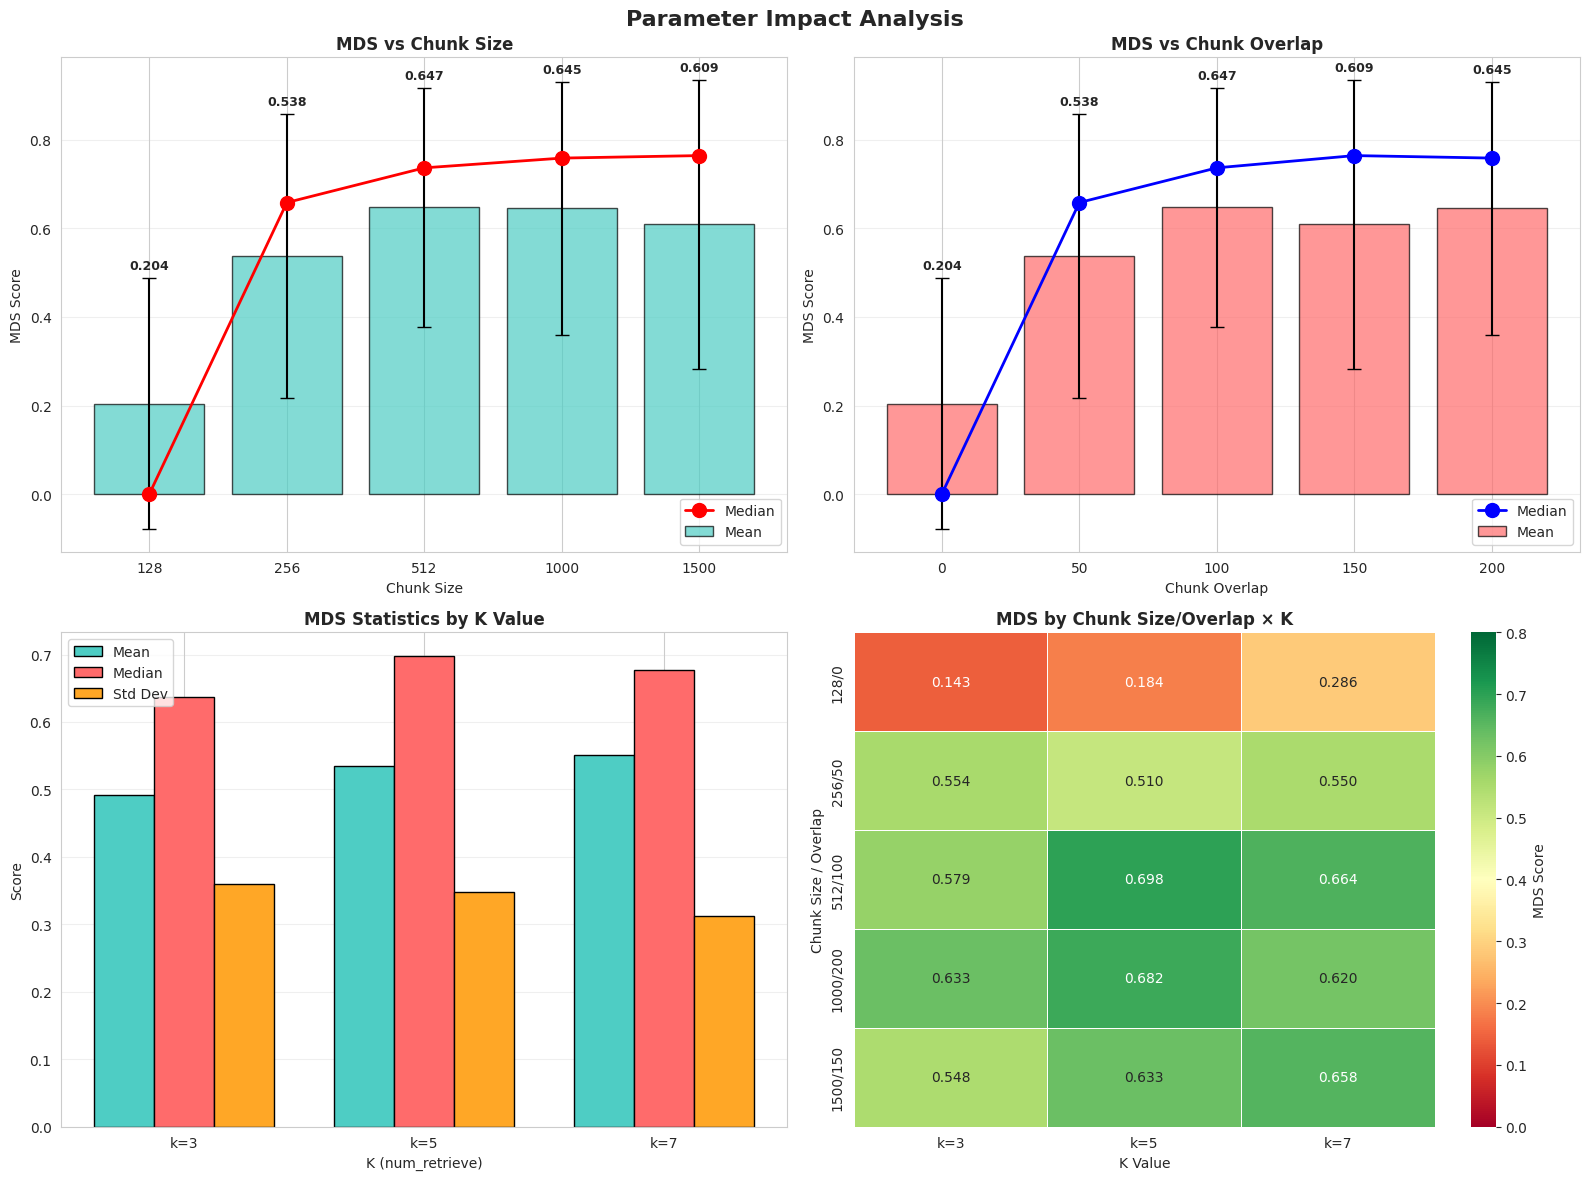

In [ ]:

"""
MDS Score Analysis - Retriever Parameters Visualization Script
Generates comprehensive charts for retriever parameter experiment with MDS metric
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration
INPUT_CSV = f'{output_folder}metric_results_retriever_mds_1206.csv'
OUTPUT_DIR = output_folder

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (16, 12)
plt.rcParams['font.size'] = 10


def load_data(csv_path):
    """Load the experiment data"""
    df = pd.read_csv(csv_path)
    df['full_config'] = df['config_name'] + '_k' + df['num_retrieve'].astype(str)
    print(f"✓ Loaded {len(df)} rows")
    print(f"✓ Configurations: {df['full_config'].nunique()}")
    print(f"✓ Questions: {df['question_num'].nunique()}")
    return df


def create_overview_visualization(df, output_path):
    """Create 6-panel overview visualization"""

    fig, axes = plt.subplots(3, 2, figsize=(16, 14))
    fig.suptitle('MDS Score Analysis - Retriever Parameters Experiment',
                 fontsize=16, fontweight='bold', y=0.995)

    # ========================================================================
    # 1. MDS by Full Configuration (horizontal bar)
    # ========================================================================
    ax = axes[0, 0]

    config_mds = df.groupby('full_config')['mds'].mean().sort_values(ascending=True)
    colors = ['#2E7D32' if i >= len(config_mds)-3 else '#1976D2' if i >= len(config_mds)-7
              else '#FFA726' if i >= 3 else '#FF6B6B' for i in range(len(config_mds))]

    ax.barh(range(len(config_mds)), config_mds.values, color=colors,
            edgecolor='black', linewidth=0.5)
    ax.set_yticks(range(len(config_mds)))
    ax.set_yticklabels(config_mds.index, fontsize=8)
    ax.set_title('MDS Score by Configuration', fontweight='bold', fontsize=12)
    ax.set_xlabel('MDS Score', fontsize=10)
    ax.grid(True, alpha=0.3, axis='x')

    for i, v in enumerate(config_mds.values):
        ax.text(v + 0.01, i, f'{v:.3f}', va='center', fontsize=8, fontweight='bold')

    ax.axvline(x=config_mds.mean(), color='red', linestyle='--', linewidth=2,
               label=f'Mean: {config_mds.mean():.3f}')
    ax.legend(loc='lower right', fontsize=9)

    # ========================================================================
    # 2. MDS by Question Number
    # ========================================================================
    ax = axes[0, 1]

    q_mds = df.groupby('question_num')['mds'].mean().sort_values(ascending=True)
    colors = ['#FF6B6B' if v < 0.40 else '#FFA726' if v < 0.55 else '#4ECDC4' for v in q_mds]

    ax.barh(range(len(q_mds)), q_mds.values, color=colors, edgecolor='black', linewidth=0.5)
    ax.set_yticks(range(len(q_mds)))
    ax.set_yticklabels([f'Q{q}' for q in q_mds.index])
    ax.set_title('MDS Score by Question Number', fontweight='bold', fontsize=12)
    ax.set_xlabel('MDS Score', fontsize=10)
    ax.grid(True, alpha=0.3, axis='x')

    ax.axvline(x=0.55, color='green', linestyle='--', alpha=0.7, linewidth=1.5, label='Good (0.55)')
    ax.axvline(x=0.40, color='red', linestyle='--', alpha=0.7, linewidth=1.5, label='Fair (0.40)')
    ax.legend(loc='lower right', fontsize=9)

    # ========================================================================
    # 3. MDS by Chunk Settings
    # ========================================================================
    ax = axes[1, 0]

    chunk_mds = df.groupby('config_name')['mds'].agg(['mean', 'std']).sort_values('mean', ascending=True)

    colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(chunk_mds)))

    ax.barh(range(len(chunk_mds)), chunk_mds['mean'], xerr=chunk_mds['std'],
            color=colors, edgecolor='black', linewidth=0.5, capsize=5)
    ax.set_yticks(range(len(chunk_mds)))
    ax.set_yticklabels(chunk_mds.index)
    ax.set_title('MDS by Chunk Settings (with Std Dev)', fontweight='bold', fontsize=12)
    ax.set_xlabel('MDS Score', fontsize=10)
    ax.grid(True, alpha=0.3, axis='x')

    for i, (idx, row) in enumerate(chunk_mds.iterrows()):
        ax.text(row['mean'] + row['std'] + 0.02, i, f'{row["mean"]:.3f}',
                va='center', fontsize=9, fontweight='bold')

    # ========================================================================
    # 4. MDS by K (num_retrieve) Value
    # ========================================================================
    ax = axes[1, 1]

    k_mds = df.groupby('num_retrieve')['mds'].agg(['mean', 'std', 'median'])

    x = np.arange(len(k_mds))
    width = 0.35

    bars1 = ax.bar(x - width/2, k_mds['mean'], width, label='Mean',
                   color='#4ECDC4', edgecolor='black', yerr=k_mds['std'], capsize=5)
    bars2 = ax.bar(x + width/2, k_mds['median'], width, label='Median',
                   color='#FF6B6B', edgecolor='black')

    ax.set_xticks(x)
    ax.set_xticklabels([f'k={int(k)}' for k in k_mds.index])
    ax.set_title('MDS by K (num_retrieve) Value', fontweight='bold', fontsize=12)
    ax.set_ylabel('MDS Score', fontsize=10)
    ax.legend(loc='lower right', fontsize=10)
    ax.grid(True, alpha=0.3, axis='y')

    for bar, val in zip(bars1, k_mds['mean']):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{val:.3f}', ha='center', fontsize=9, fontweight='bold')

    # ========================================================================
    # 5. Heatmap: Chunk Setting × K Value
    # ========================================================================
    ax = axes[2, 0]

    heatmap_data = df.pivot_table(values='mds', index='config_name',
                                   columns='num_retrieve', aggfunc='mean')
    heatmap_data.columns = [f'k={int(k)}' for k in heatmap_data.columns]

    # Sort by mean
    heatmap_data['mean'] = heatmap_data.mean(axis=1)
    heatmap_data = heatmap_data.sort_values('mean', ascending=False)
    heatmap_data = heatmap_data.drop('mean', axis=1)

    sns.heatmap(heatmap_data, annot=True, fmt='.3f', cmap='RdYlGn', ax=ax,
                cbar_kws={'label': 'MDS Score'}, linewidths=0.5, linecolor='gray',
                vmin=0, vmax=0.8)

    ax.set_title('MDS Heatmap: Chunk Setting × K Value', fontweight='bold', fontsize=12)
    ax.set_xlabel('K (num_retrieve)', fontsize=10)
    ax.set_ylabel('Chunk Setting', fontsize=10)

    # ========================================================================
    # 6. MDS by Audience Type (box plot)
    # ========================================================================
    ax = axes[2, 1]

    box_data = [df[df['audience_type']=='marketing']['mds'].dropna(),
                df[df['audience_type']=='research']['mds'].dropna()]

    bp = ax.boxplot(box_data, tick_labels=['Marketing', 'Research'], patch_artist=True)

    colors_box = ['#FF6B6B', '#4ECDC4']
    for patch, color in zip(bp['boxes'], colors_box):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)

    for median in bp['medians']:
        median.set_color('red')
        median.set_linewidth(2)

    ax.set_title('MDS Distribution by Audience Type', fontweight='bold', fontsize=12)
    ax.set_ylabel('MDS Score', fontsize=10)
    ax.grid(True, alpha=0.3, axis='y')

    # Add mean markers
    means = df.groupby('audience_type')['mds'].mean()
    for i, (aud, mean_val) in enumerate(means.items()):
        ax.scatter(i+1, mean_val, color='blue', s=100, zorder=5, marker='D')
        ax.text(i+1.15, mean_val, f'μ={mean_val:.3f}', fontsize=9, fontweight='bold')

    plt.tight_layout()
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    print(f"✓ Saved: {output_path}")


def create_chunk_analysis_visualization(df, output_path):
    """Create chunk settings focused visualization"""

    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('Chunk Settings Analysis', fontsize=16, fontweight='bold')

    # ========================================================================
    # 1. Chunk Size vs MDS (scatter with trend)
    # ========================================================================
    ax = axes[0, 0]

    chunk_data = df.groupby(['chunksize', 'num_retrieve'])['mds'].mean().reset_index()

    for k in sorted(df['num_retrieve'].unique()):
        k_data = chunk_data[chunk_data['num_retrieve'] == k]
        ax.plot(k_data['chunksize'], k_data['mds'], 'o-', label=f'k={int(k)}',
                linewidth=2, markersize=8)

    ax.set_xlabel('Chunk Size', fontsize=10)
    ax.set_ylabel('MDS Score', fontsize=10)
    ax.set_title('MDS vs Chunk Size by K Value', fontweight='bold', fontsize=12)
    ax.legend(loc='lower right', fontsize=10)
    ax.grid(True, alpha=0.3)

    # ========================================================================
    # 2. Chunk Overlap vs MDS
    # ========================================================================
    ax = axes[0, 1]

    overlap_data = df.groupby(['chunkoverlap', 'num_retrieve'])['mds'].mean().reset_index()

    for k in sorted(df['num_retrieve'].unique()):
        k_data = overlap_data[overlap_data['num_retrieve'] == k]
        ax.plot(k_data['chunkoverlap'], k_data['mds'], 's-', label=f'k={int(k)}',
                linewidth=2, markersize=8)

    ax.set_xlabel('Chunk Overlap', fontsize=10)
    ax.set_ylabel('MDS Score', fontsize=10)
    ax.set_title('MDS vs Chunk Overlap by K Value', fontweight='bold', fontsize=12)
    ax.legend(loc='lower right', fontsize=10)
    ax.grid(True, alpha=0.3)

    # ========================================================================
    # 3. Component Metrics by Chunk Setting
    # ========================================================================
    ax = axes[1, 0]

    metrics = ['ragas_score_faithfulness', 'ragas_score_answer_relevancy',
               'ragas_score_context_precision', 'bert_score_f1']
    metric_names = ['Faithfulness', 'Answer Rel.', 'Context Prec.', 'BERT F1']

    chunk_metrics = df.groupby('config_name')[metrics].mean()
    chunk_metrics = chunk_metrics.sort_values('ragas_score_context_precision', ascending=True)

    x = np.arange(len(chunk_metrics))
    width = 0.2

    for i, (metric, name) in enumerate(zip(metrics, metric_names)):
        ax.bar(x + i*width, chunk_metrics[metric], width, label=name,
               edgecolor='black', linewidth=0.3)

    ax.set_xticks(x + width * 1.5)
    ax.set_xticklabels(chunk_metrics.index, rotation=45, ha='right', fontsize=9)
    ax.set_title('MDS Component Metrics by Chunk Setting', fontweight='bold', fontsize=12)
    ax.set_ylabel('Score', fontsize=10)
    ax.legend(loc='lower right', fontsize=9)
    ax.grid(True, alpha=0.3, axis='y')

    # ========================================================================
    # 4. Zero MDS by Chunk Setting
    # ========================================================================
    ax = axes[1, 1]

    zero_mds = df[df['mds'] < 0.001]
    zero_by_chunk = zero_mds.groupby('config_name').size().sort_values(ascending=True)

    # Add missing configs with zero count
    all_configs = df['config_name'].unique()
    for config in all_configs:
        if config not in zero_by_chunk.index:
            zero_by_chunk[config] = 0
    zero_by_chunk = zero_by_chunk.sort_values(ascending=True)

    colors = ['#4ECDC4' if v < 15 else '#FFA726' if v < 30 else '#FF6B6B' for v in zero_by_chunk]

    ax.barh(range(len(zero_by_chunk)), zero_by_chunk.values, color=colors,
            edgecolor='black', linewidth=0.5)
    ax.set_yticks(range(len(zero_by_chunk)))
    ax.set_yticklabels(zero_by_chunk.index)
    ax.set_title(f'Zero MDS Failures by Chunk Setting (Total: {len(zero_mds)})',
                 fontweight='bold', fontsize=12)
    ax.set_xlabel('Count of Zero MDS Rows', fontsize=10)
    ax.grid(True, alpha=0.3, axis='x')

    for i, v in enumerate(zero_by_chunk.values):
        ax.text(v + 0.5, i, str(v), va='center', fontweight='bold')

    plt.tight_layout()
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    print(f"✓ Saved: {output_path}")


def create_question_analysis_visualization(df, output_path):
    """Create question-focused visualization"""

    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('Question Analysis - Retriever Parameters', fontsize=16, fontweight='bold')

    # ========================================================================
    # 1. Question Performance Ranking
    # ========================================================================
    ax = axes[0, 0]

    q_stats = df.groupby('question_num')['mds'].agg(['mean', 'std']).sort_values('mean', ascending=True)

    colors = ['#FF6B6B' if m < 0.40 else '#FFA726' if m < 0.55 else '#4ECDC4' for m in q_stats['mean']]

    ax.barh(range(len(q_stats)), q_stats['mean'], xerr=q_stats['std'],
            color=colors, edgecolor='black', linewidth=0.5, capsize=3)
    ax.set_yticks(range(len(q_stats)))
    ax.set_yticklabels([f'Q{q}' for q in q_stats.index])
    ax.set_title('MDS by Question (with Std Dev)', fontweight='bold', fontsize=12)
    ax.set_xlabel('MDS Score', fontsize=10)
    ax.grid(True, alpha=0.3, axis='x')

    ax.axvline(x=0.55, color='green', linestyle='--', alpha=0.7, linewidth=1.5)
    ax.axvline(x=0.40, color='red', linestyle='--', alpha=0.7, linewidth=1.5)

    # ========================================================================
    # 2. Research - Marketing Difference by Question
    # ========================================================================
    ax = axes[0, 1]

    pivot = df.pivot_table(values='mds', index='question_num', columns='audience_type', aggfunc='mean')
    pivot['diff'] = pivot['research'] - pivot['marketing']
    pivot = pivot.sort_values('diff', ascending=True)

    colors = ['#FF6B6B' if d < 0 else '#4ECDC4' for d in pivot['diff']]

    ax.barh(range(len(pivot)), pivot['diff'], color=colors, edgecolor='black', linewidth=0.5)
    ax.set_yticks(range(len(pivot)))
    ax.set_yticklabels([f'Q{q}' for q in pivot.index])
    ax.set_title('MDS Difference (Research - Marketing)', fontweight='bold', fontsize=12)
    ax.set_xlabel('Difference', fontsize=10)
    ax.axvline(x=0, color='black', linestyle='-', linewidth=1)
    ax.grid(True, alpha=0.3, axis='x')

    ax.text(0.95, 0.95, '← Marketing Better | Research Better →',
            transform=ax.transAxes, fontsize=9, ha='right', va='top', style='italic')

    # ========================================================================
    # 3. Heatmap: Question × Chunk Setting
    # ========================================================================
    ax = axes[1, 0]

    heatmap_q = df.pivot_table(values='mds', index='question_num',
                                columns='config_name', aggfunc='mean')

    # Sort by mean MDS
    heatmap_q = heatmap_q.loc[heatmap_q.mean(axis=1).sort_values(ascending=False).index]

    sns.heatmap(heatmap_q, annot=True, fmt='.2f', cmap='RdYlGn', ax=ax,
                cbar_kws={'label': 'MDS Score'}, linewidths=0.5, linecolor='gray',
                vmin=0, vmax=0.9)

    ax.set_title('MDS Heatmap: Question × Chunk Setting', fontweight='bold', fontsize=12)
    ax.set_xlabel('Chunk Setting', fontsize=10)
    ax.set_ylabel('Question', fontsize=10)
    ax.tick_params(axis='x', rotation=45, labelsize=9)

    # ========================================================================
    # 4. Zero MDS by Question
    # ========================================================================
    ax = axes[1, 1]

    zero_mds = df[df['mds'] < 0.001]

    if len(zero_mds) > 0:
        zero_by_q = zero_mds.groupby('question_num').size().sort_values(ascending=True)

        colors = ['#FFA726' if v <= 10 else '#FF6B6B' for v in zero_by_q]

        ax.barh(range(len(zero_by_q)), zero_by_q.values, color=colors, edgecolor='black')
        ax.set_yticks(range(len(zero_by_q)))
        ax.set_yticklabels([f'Q{q}' for q in zero_by_q.index])
        ax.set_title(f'Zero MDS Rows by Question (Total: {len(zero_mds)})',
                     fontweight='bold', fontsize=12)
        ax.set_xlabel('Count', fontsize=10)
        ax.grid(True, alpha=0.3, axis='x')

        for i, v in enumerate(zero_by_q.values):
            ax.text(v + 0.3, i, str(v), va='center', fontweight='bold')

    plt.tight_layout()
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    print(f"✓ Saved: {output_path}")


def create_comparison_visualization(df, output_path):
    """Create detailed comparison visualization"""

    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('Retriever Configuration Comparison', fontsize=16, fontweight='bold')

    # ========================================================================
    # 1. Best Config per Question
    # ========================================================================
    ax = axes[0, 0]

    from collections import Counter

    best_configs = []
    for q_num in df['question_num'].unique():
        q_data = df[df['question_num'] == q_num].groupby('full_config')['mds'].mean()
        best_configs.append(q_data.idxmax())

    config_wins = Counter(best_configs)
    configs = list(config_wins.keys())
    counts = list(config_wins.values())

    # Sort by count
    sorted_data = sorted(zip(counts, configs), reverse=True)
    counts, configs = zip(*sorted_data)

    colors = ['#2E7D32' if c == max(counts) else '#1976D2' for c in counts]

    ax.bar(range(len(configs)), counts, color=colors, edgecolor='black', linewidth=0.5)
    ax.set_xticks(range(len(configs)))
    ax.set_xticklabels(configs, rotation=45, ha='right', fontsize=8)
    ax.set_title('Config Win Count (Best MDS per Question)', fontweight='bold', fontsize=12)
    ax.set_ylabel('Questions Won', fontsize=10)
    ax.grid(True, alpha=0.3, axis='y')

    for i, v in enumerate(counts):
        ax.text(i, v + 0.1, str(v), ha='center', fontweight='bold', fontsize=10)

    # ========================================================================
    # 2. MDS Distribution by Config (Violin)
    # ========================================================================
    ax = axes[0, 1]

    # Get top 5 configs
    top_configs = df.groupby('full_config')['mds'].mean().nlargest(5).index.tolist()
    top_data = df[df['full_config'].isin(top_configs)]

    config_data = [top_data[top_data['full_config']==c]['mds'].dropna() for c in top_configs]

    parts = ax.violinplot(config_data, positions=range(len(top_configs)),
                          showmeans=True, showmedians=True)

    colors = plt.cm.Set2(np.linspace(0, 1, len(top_configs)))
    for i, pc in enumerate(parts['bodies']):
        pc.set_facecolor(colors[i])
        pc.set_alpha(0.7)

    ax.set_xticks(range(len(top_configs)))
    ax.set_xticklabels(top_configs, rotation=45, ha='right', fontsize=8)
    ax.set_title('MDS Distribution - Top 5 Configs', fontweight='bold', fontsize=12)
    ax.set_ylabel('MDS Score', fontsize=10)
    ax.grid(True, alpha=0.3, axis='y')

    # ========================================================================
    # 3. K Value Impact by Chunk Setting
    # ========================================================================
    ax = axes[1, 0]

    chunk_k = df.pivot_table(values='mds', index='config_name', columns='num_retrieve', aggfunc='mean')
    chunk_k.columns = [f'k={int(k)}' for k in chunk_k.columns]

    chunk_k.plot(kind='bar', ax=ax, edgecolor='black', linewidth=0.5)
    ax.set_title('K Value Impact by Chunk Setting', fontweight='bold', fontsize=12)
    ax.set_xlabel('Chunk Setting', fontsize=10)
    ax.set_ylabel('MDS Score', fontsize=10)
    ax.legend(title='K Value', loc='upper right', fontsize=9)
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True, alpha=0.3, axis='y')

    # ========================================================================
    # 4. Config Consistency (Std Dev)
    # ========================================================================
    ax = axes[1, 1]

    config_std = df.groupby('full_config')['mds'].std().sort_values(ascending=True)

    # Take top 10 most consistent
    config_std = config_std.head(10)

    colors = ['#4ECDC4' if v < 0.25 else '#FFA726' if v < 0.30 else '#FF6B6B' for v in config_std]

    ax.barh(range(len(config_std)), config_std.values, color=colors,
            edgecolor='black', linewidth=0.5)
    ax.set_yticks(range(len(config_std)))
    ax.set_yticklabels(config_std.index, fontsize=9)
    ax.set_title('Most Consistent Configs (Lower Std = Better)', fontweight='bold', fontsize=12)
    ax.set_xlabel('Standard Deviation', fontsize=10)
    ax.grid(True, alpha=0.3, axis='x')

    for i, v in enumerate(config_std.values):
        ax.text(v + 0.005, i, f'{v:.3f}', va='center', fontsize=9, fontweight='bold')

    plt.tight_layout()
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    print(f"✓ Saved: {output_path}")


def create_parameter_impact_visualization(df, output_path):
    """Create parameter impact visualization"""

    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('Parameter Impact Analysis', fontsize=16, fontweight='bold')

    # ========================================================================
    # 1. Chunk Size Impact
    # ========================================================================
    ax = axes[0, 0]

    chunk_impact = df.groupby('chunksize')['mds'].agg(['mean', 'std', 'median'])

    x = range(len(chunk_impact))
    ax.bar(x, chunk_impact['mean'], yerr=chunk_impact['std'],
           color='#4ECDC4', edgecolor='black', capsize=5, alpha=0.7, label='Mean')
    ax.plot(x, chunk_impact['median'], 'ro-', linewidth=2, markersize=10, label='Median')

    ax.set_xticks(x)
    ax.set_xticklabels(chunk_impact.index)
    ax.set_xlabel('Chunk Size', fontsize=10)
    ax.set_ylabel('MDS Score', fontsize=10)
    ax.set_title('MDS vs Chunk Size', fontweight='bold', fontsize=12)
    ax.legend(loc='lower right', fontsize=10)
    ax.grid(True, alpha=0.3, axis='y')

    for i, val in enumerate(chunk_impact['mean']):
        ax.text(i, val + chunk_impact['std'].iloc[i] + 0.02, f'{val:.3f}',
                ha='center', fontsize=9, fontweight='bold')

    # ========================================================================
    # 2. Chunk Overlap Impact
    # ========================================================================
    ax = axes[0, 1]

    overlap_impact = df.groupby('chunkoverlap')['mds'].agg(['mean', 'std', 'median'])

    x = range(len(overlap_impact))
    ax.bar(x, overlap_impact['mean'], yerr=overlap_impact['std'],
           color='#FF6B6B', edgecolor='black', capsize=5, alpha=0.7, label='Mean')
    ax.plot(x, overlap_impact['median'], 'bo-', linewidth=2, markersize=10, label='Median')

    ax.set_xticks(x)
    ax.set_xticklabels(overlap_impact.index)
    ax.set_xlabel('Chunk Overlap', fontsize=10)
    ax.set_ylabel('MDS Score', fontsize=10)
    ax.set_title('MDS vs Chunk Overlap', fontweight='bold', fontsize=12)
    ax.legend(loc='lower right', fontsize=10)
    ax.grid(True, alpha=0.3, axis='y')

    for i, val in enumerate(overlap_impact['mean']):
        ax.text(i, val + overlap_impact['std'].iloc[i] + 0.02, f'{val:.3f}',
                ha='center', fontsize=9, fontweight='bold')

    # ========================================================================
    # 3. K Value Impact
    # ========================================================================
    ax = axes[1, 0]

    k_impact = df.groupby('num_retrieve')['mds'].agg(['mean', 'std', 'median'])

    x = range(len(k_impact))
    width = 0.25

    ax.bar([i-width for i in x], k_impact['mean'], width, label='Mean',
           color='#4ECDC4', edgecolor='black')
    ax.bar(x, k_impact['median'], width, label='Median',
           color='#FF6B6B', edgecolor='black')
    ax.bar([i+width for i in x], k_impact['std'], width, label='Std Dev',
           color='#FFA726', edgecolor='black')

    ax.set_xticks(x)
    ax.set_xticklabels([f'k={int(k)}' for k in k_impact.index])
    ax.set_xlabel('K (num_retrieve)', fontsize=10)
    ax.set_ylabel('Score', fontsize=10)
    ax.set_title('MDS Statistics by K Value', fontweight='bold', fontsize=12)
    ax.legend(loc='upper left', fontsize=10)
    ax.grid(True, alpha=0.3, axis='y')

    # ========================================================================
    # 4. Combined Parameter Heatmap
    # ========================================================================
    ax = axes[1, 1]

    # Create combined heatmap
    combined = df.pivot_table(values='mds',
                               index=['chunksize', 'chunkoverlap'],
                               columns='num_retrieve',
                               aggfunc='mean')
    combined.columns = [f'k={int(k)}' for k in combined.columns]
    combined.index = [f'{cs}/{ov}' for cs, ov in combined.index]

    sns.heatmap(combined, annot=True, fmt='.3f', cmap='RdYlGn', ax=ax,
                cbar_kws={'label': 'MDS Score'}, linewidths=0.5, vmin=0, vmax=0.8)

    ax.set_title('MDS by Chunk Size/Overlap × K', fontweight='bold', fontsize=12)
    ax.set_xlabel('K Value', fontsize=10)
    ax.set_ylabel('Chunk Size / Overlap', fontsize=10)

    plt.tight_layout()
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    print(f"✓ Saved: {output_path}")


def print_summary(df):
    """Print key findings summary"""

    print("\n" + "=" * 80)
    print("RETRIEVER PARAMETERS MDS ANALYSIS SUMMARY")
    print("=" * 80)

    # Overall stats
    print(f"\nOverall MDS: {df['mds'].mean():.4f} (±{df['mds'].std():.4f})")
    print(f"   Median: {df['mds'].median():.4f}")

    # Best config
    best_config = df.groupby('full_config')['mds'].mean().idxmax()
    best_score = df.groupby('full_config')['mds'].mean().max()
    print(f"\nBest Configuration: {best_config}")
    print(f"   MDS: {best_score:.4f}")

    # Best chunk setting
    best_chunk = df.groupby('config_name')['mds'].mean().idxmax()
    best_chunk_score = df.groupby('config_name')['mds'].mean().max()
    print(f"\nBest Chunk Setting: {best_chunk}")
    print(f"   MDS: {best_chunk_score:.4f}")

    # Best K value
    best_k = df.groupby('num_retrieve')['mds'].mean().idxmax()
    best_k_score = df.groupby('num_retrieve')['mds'].mean().max()
    print(f"\nBest K Value: k={int(best_k)}")
    print(f"   MDS: {best_k_score:.4f}")

    # Audience comparison
    mkt_mean = df[df['audience_type']=='marketing']['mds'].mean()
    res_mean = df[df['audience_type']=='research']['mds'].mean()
    print(f"\n Audience Comparison:")
    print(f"   Marketing: {mkt_mean:.4f}")
    print(f"   Research:  {res_mean:.4f}")
    print(f"   Winner:    {'Research' if res_mean > mkt_mean else 'Marketing'} (+{abs(res_mean-mkt_mean):.4f})")

    # Problem questions
    q_mds = df.groupby('question_num')['mds'].mean()
    problem_qs = q_mds[q_mds < 0.40].index.tolist()
    print(f"\n Problem Questions (MDS < 0.40): {problem_qs}")

    # Zero MDS count
    zero_count = (df['mds'] < 0.001).sum()
    print(f"\n Rows with Zero MDS: {zero_count} ({zero_count/len(df)*100:.1f}%)")




print("\n" + "=" * 80)
print("MDS SCORE ANALYSIS - RETRIEVER PARAMETERS VISUALIZATION")
print("=" * 80)

# Load data
df = load_data(INPUT_CSV)

# Print summary
print_summary(df)

# Generate visualizations
print("\n" + "=" * 80)
print("GENERATING VISUALIZATIONS")
print("=" * 80)

create_overview_visualization(df, OUTPUT_DIR + 'retriever_mds_overview.png')
create_chunk_analysis_visualization(df, OUTPUT_DIR + 'retriever_mds_chunk_analysis.png')
create_question_analysis_visualization(df, OUTPUT_DIR + 'retriever_mds_question_analysis.png')
create_comparison_visualization(df, OUTPUT_DIR + 'retriever_mds_comparison.png')
create_parameter_impact_visualization(df, OUTPUT_DIR + 'retriever_mds_parameter_impact.png')






---

MDS Score Analysis - Retriever Parameters

Overview

| Metric | Value |
|--------|-------|
| **Total Rows** | 450 |
| **Configurations** | 15 (5 chunk settings × 3 K values) |
| **Questions** | 15 |
| **Audience Types** | Marketing, Research |
| **Mean MDS** | 0.5254 |
| **Median MDS** | 0.6745 |
| **Zero MDS Rows** | 117 (26.0%) |

---

Configuration Rankings (by MDS)

| Rank | Config | Chunk | Overlap | K | MDS Mean |
|------|--------|-------|---------|---|----------|
| 1 | **high_overlap_k5** | 512 | 100 | 5 | **0.6983** |
| 2 | medium_context_k5 | 1000 | 200 | 5 | 0.6821 |
| 3 | high_overlap_k7 | 512 | 100 | 7 | 0.6642 |
| 4 | balanced_k7 | 1500 | 150 | 7 | 0.6580 |
| 5 | medium_context_k3 | 1000 | 200 | 3 | 0.6331 |
| ... | ... | ... | ... | ... | ... |
| 13 | v_small_context_k7 | 128 | 0 | 7 | 0.2861 |
| 14 | v_small_context_k5 | 128 | 0 | 5 | 0.1835 |
| 15 | **v_small_context_k3** | 128 | 0 | 3 | **0.1434** |

---

Chunk Settings Ranking

| Rank | Config | Chunk Size | Overlap | MDS Mean |
|------|--------|------------|---------|----------|
| 1 | **high_overlap** | 512 | 100 | **0.6472** |
| 2 | medium_context | 1000 | 200 | 0.6454 |
| 3 | balanced | 1500 | 150 | 0.6088 |
| 4 | small_context | 256 | 50 | 0.5379 |
| 5 | **v_small_context** | 128 | 0 | **0.2043** |

---

K (num_retrieve) Impact

| K Value | MDS Mean | MDS Median |
|---------|----------|------------|
| **k=7** | **0.5515** | 0.6767 |
| k=5 | 0.5351 | 0.6981 |
| k=3 | 0.4915 | 0.6363 |

**Insight:** More retrieved chunks (k=7) performs best, k=3 is worst.

---

Audience Comparison

| Audience | MDS Mean | MDS Median |
|----------|----------|------------|
| Marketing | 0.4994 | 0.6349 |
| **Research** | **0.5507** | **0.7248** |
| **Difference** | **+5.1%** | Research better |

---

MDS by Question and Audience

| Q# | Marketing | Research | Diff | Better |
|-----|-----------|----------|------|--------|
| Q63 | 0.7193 | 0.6987 | -0.021 | ≈ Similar |
| Q92 | 0.6407 | 0.6497 | +0.009 | ≈ Similar |
| Q0 | 0.6718 | 0.5856 | -0.086 | Marketing  |
| Q28 | 0.7143 | 0.5354 | **-0.179** | Marketing |
| Q110 | 0.5160 | 0.6963 | **+0.180** | Research |
| Q27 | 0.5565 | 0.6479 | +0.091 | Research |
| Q103 | 0.5514 | 0.6483 | +0.097 | Research |
| Q95 | 0.5279 | 0.6510 | +0.123 | Research |
| Q33 | 0.5142 | 0.6479 | +0.134 | Research  |
| Q87 | 0.3715 | 0.5993 | **+0.228** | Research |
| Q76 | 0.4701 | 0.5215 | +0.051 | Research  |
| Q53 | 0.5366 | 0.5574 | +0.021 | ≈ Similar |
| Q7 | 0.3362 | 0.3895 | +0.053 | Research |
| Q19 | 0.0536 | 0.2588 | +0.205 | Research  |
| Q11 | 0.3061 | 0.2031 | -0.103 | Marketing |
| **AVG** | **0.4991** | **0.5527** | **+0.054** | **Research** |

---

Problematic Rows (MDS ≈ 0)

**117 rows (26%)** have zero MDS:

| Config | Zero MDS Count |
|--------|----------------|
| **v_small_context** | **57** (worst) |
| small_context | 21 |
| balanced | 16 |
| medium_context | 12 |
| high_overlap | 11 (best) |

| Question | Zero MDS Count |
|----------|----------------|
| Q19 | 22 |
| Q11 | 19 |
| Q7 | 12 |

**Root Cause:** Zero Context Precision (chunks too small to capture relevant context)

---

Key Insights

1. **Best Config:** `high_overlap_k5` (chunk=512, overlap=100, k=5)
   - MDS: 0.6983
   - Best balance of chunk size and retrieval

2. **Optimal Chunk Size:** 512 or 1000
   - 128 too small → poor context precision
   - 1500 not significantly better

3. **Optimal Overlap:** 100-200
   - 0 overlap causes context fragmentation

4. **K Value:** k=5 or k=7 recommended
   - k=3 underperforms

5. **Avoid:** `v_small_context` (128/0)
   - 57 zero-MDS failures (49% of all failures)
   - MDS only 0.2043

6. **Research outperforms Marketing** by +5.1%




### Analysis for Experiment 2: Embedding model with MDS

Metric results : metric_results_embeddings_mds_1206.csv




MDS SCORE ANALYSIS - EMBEDDING MODELS VISUALIZATION
✓ Loaded 150 rows
✓ Embedding models: 5
✓ Questions: 15

EMBEDDING MODEL MDS ANALYSIS SUMMARY

Overall MDS: 0.5844 (±0.3186)
   Median: 0.7210

Best Embedding Model: multi-qa-mpnet-base-dot-v1
   MDS: 0.6643

Worst Embedding Model: all-distilroberta-v1
   MDS: 0.5066

Audience Comparison:
   Marketing: 0.5904
   Research:  0.5784
   Winner:    Marketing (+0.0120)

Problem Questions (MDS < 0.4): [7, 11, 19]

 Rows with Zero MDS: 31 (20.7%)

GENERATING VISUALIZATIONS
✓ Saved: /content/drive/MyDrive/MIDS_267/final_project/output/embeddings_mds_overview.png
✓ Saved: /content/drive/MyDrive/MIDS_267/final_project/output/embeddings_mds_model_analysis.png
✓ Saved: /content/drive/MyDrive/MIDS_267/final_project/output/embeddings_mds_question_analysis.png
✓ Saved: /content/drive/MyDrive/MIDS_267/final_project/output/embeddings_mds_comparison.png


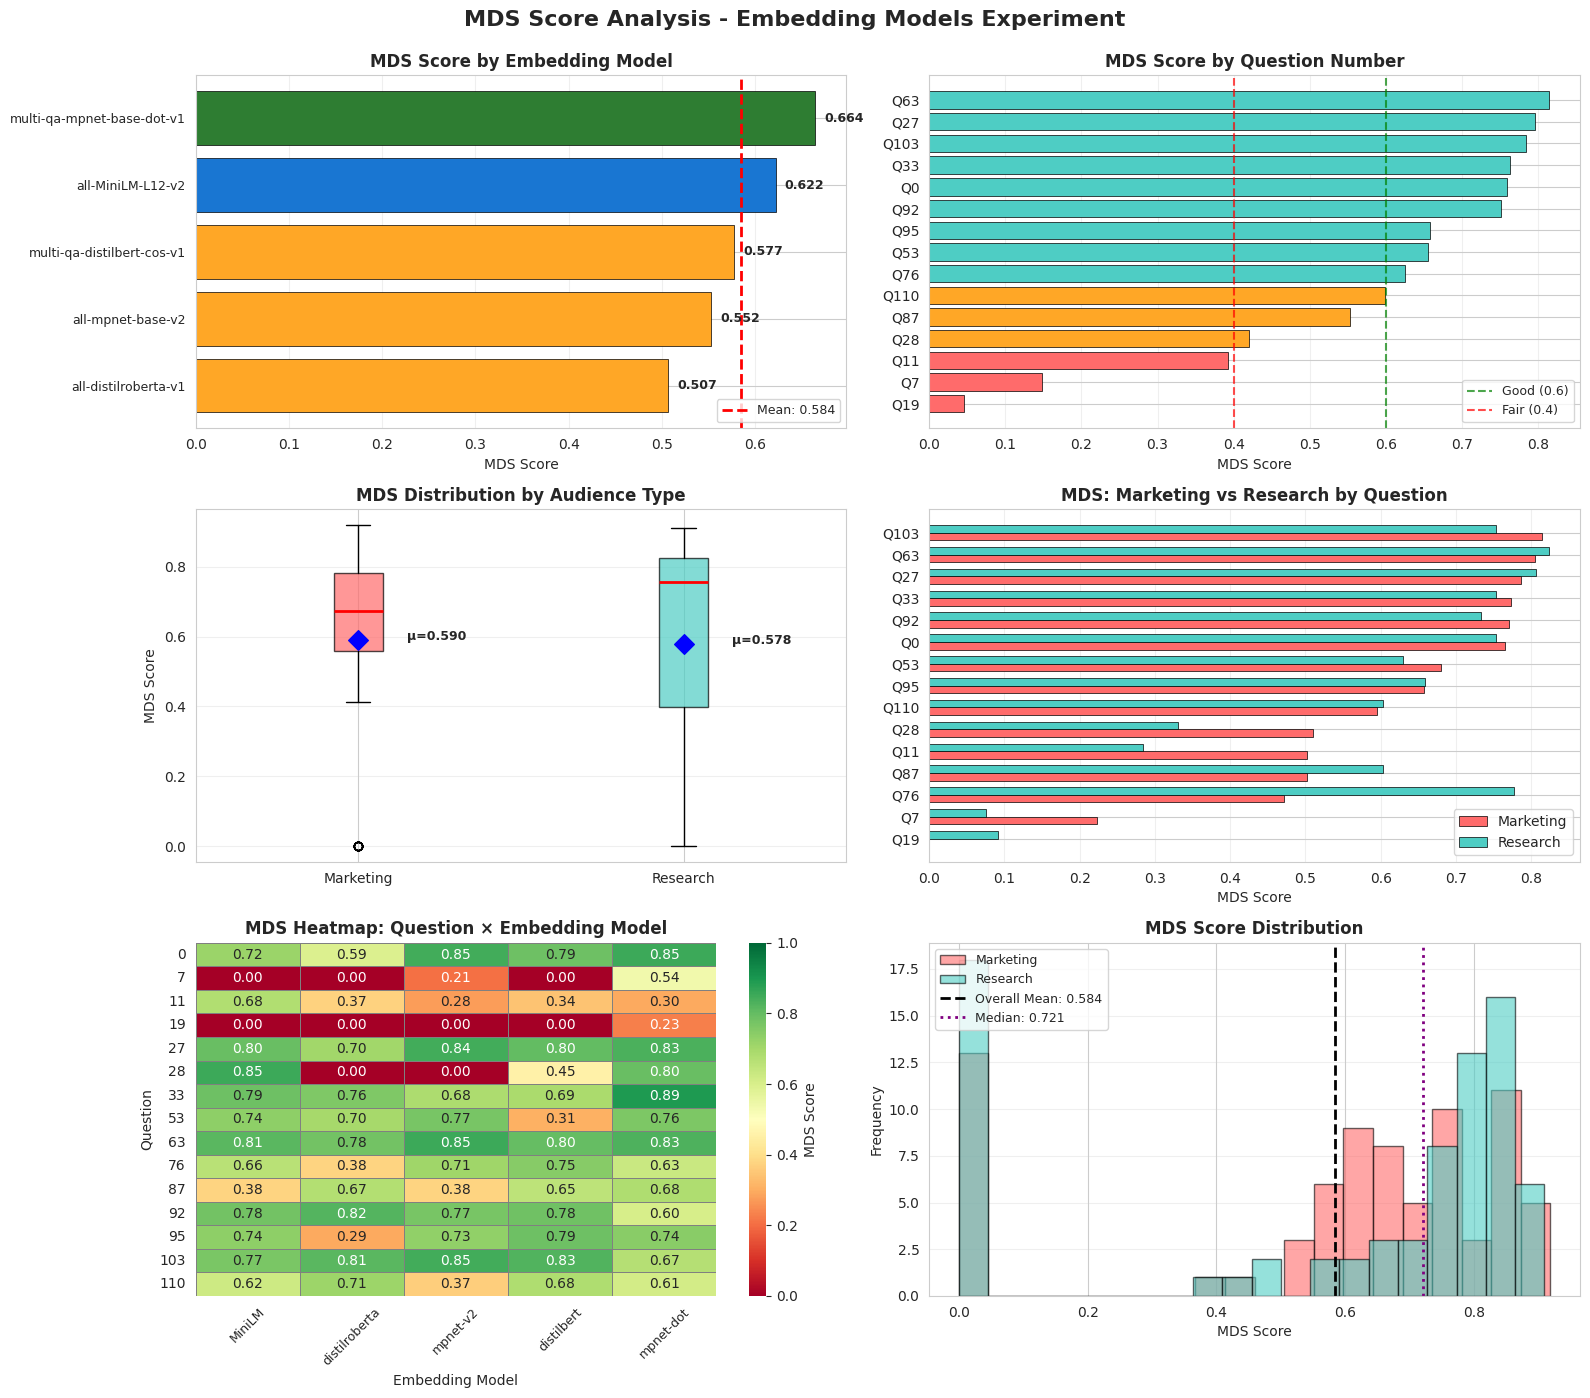

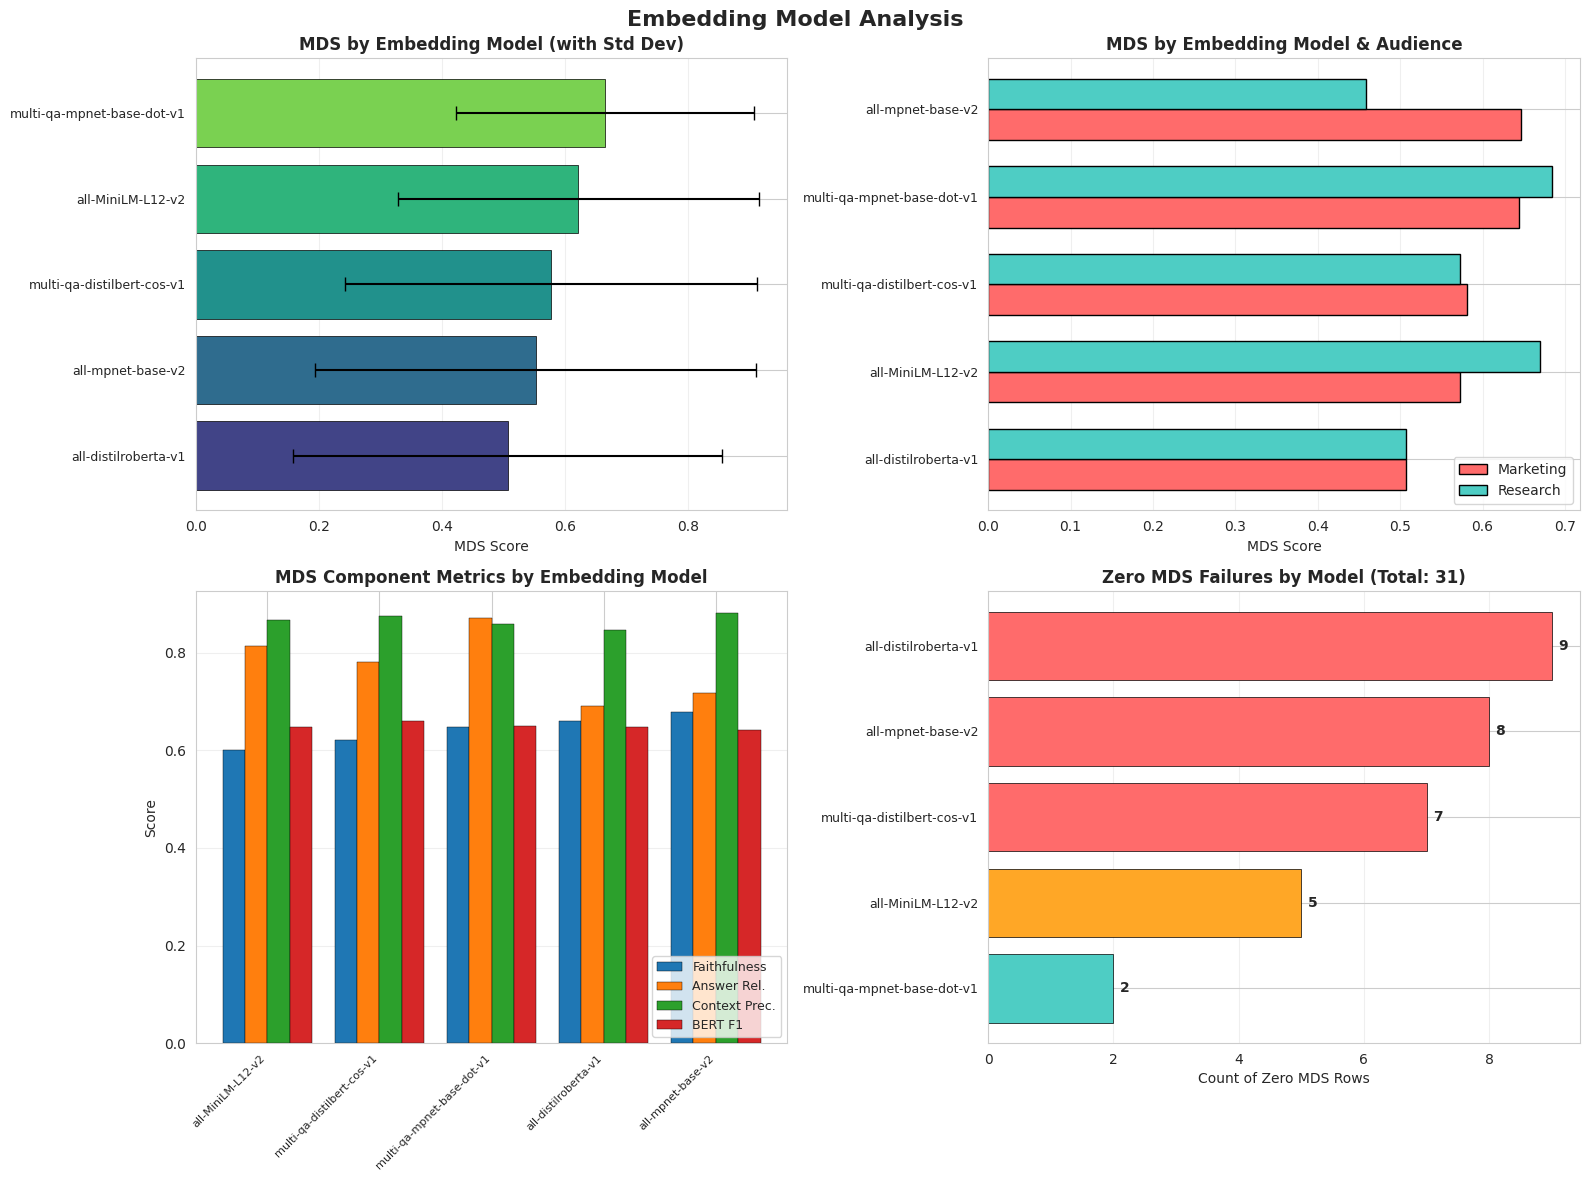

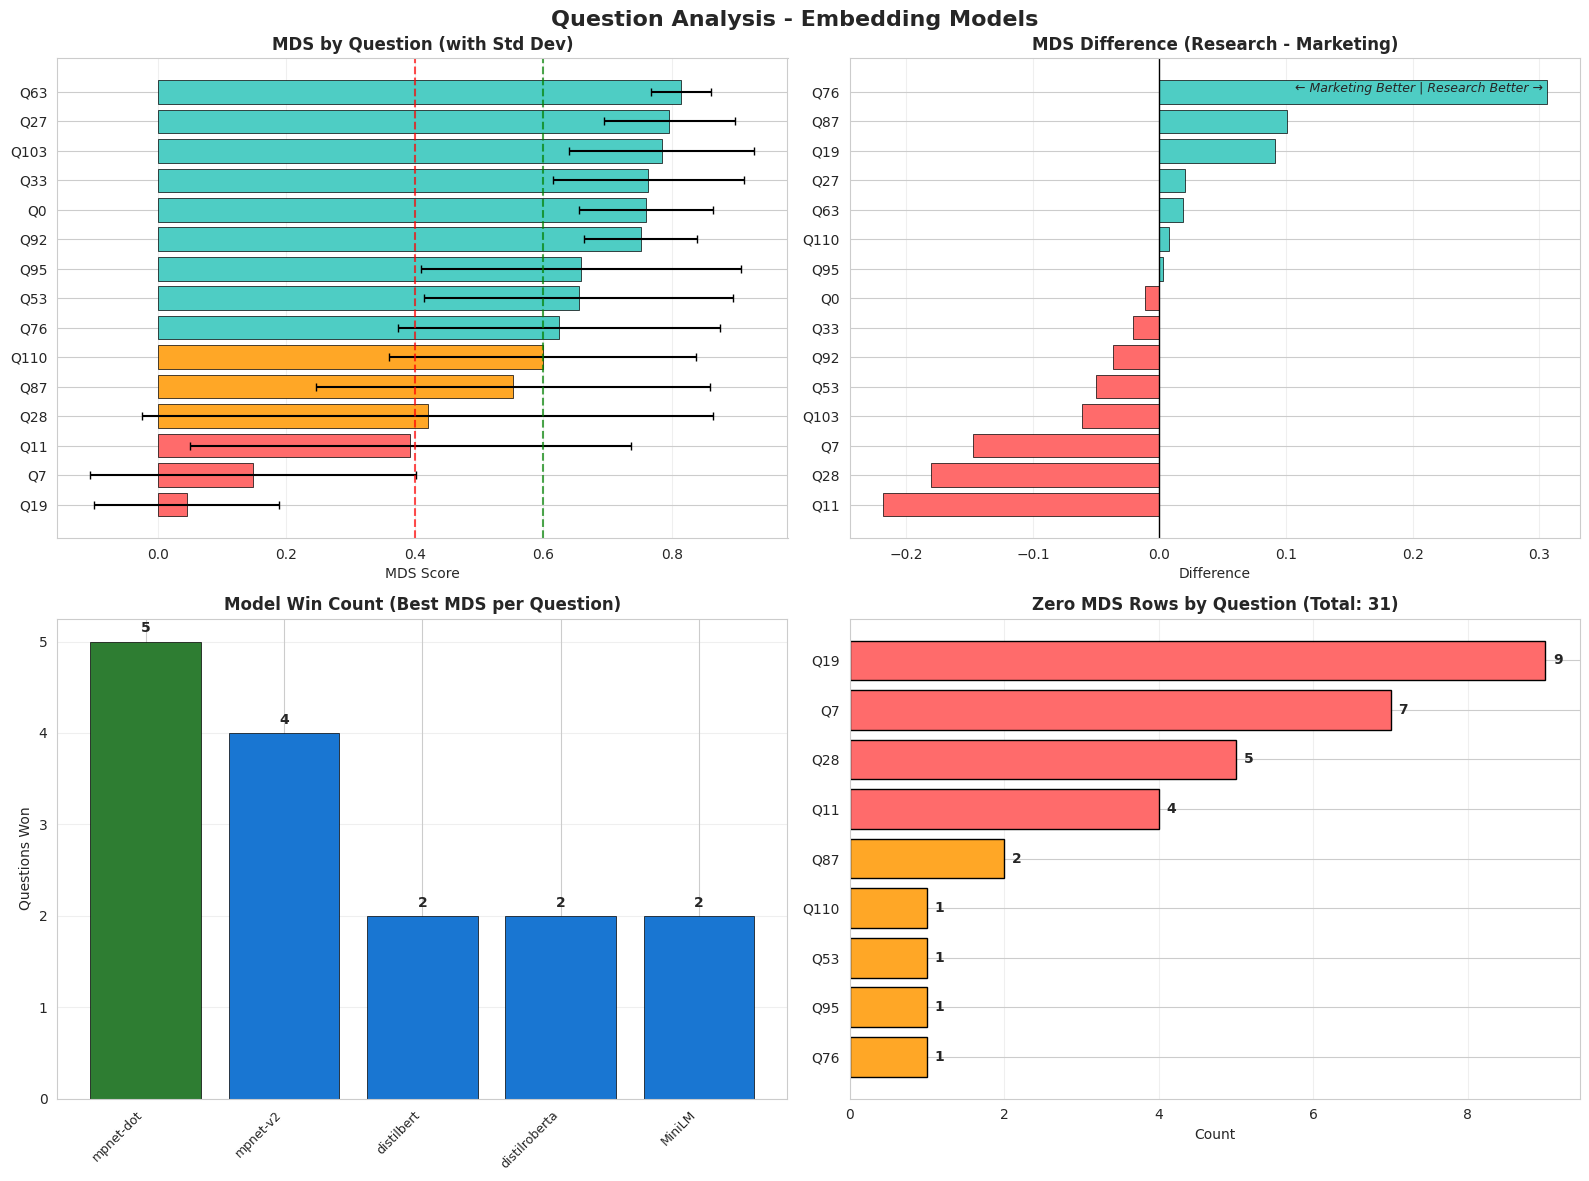

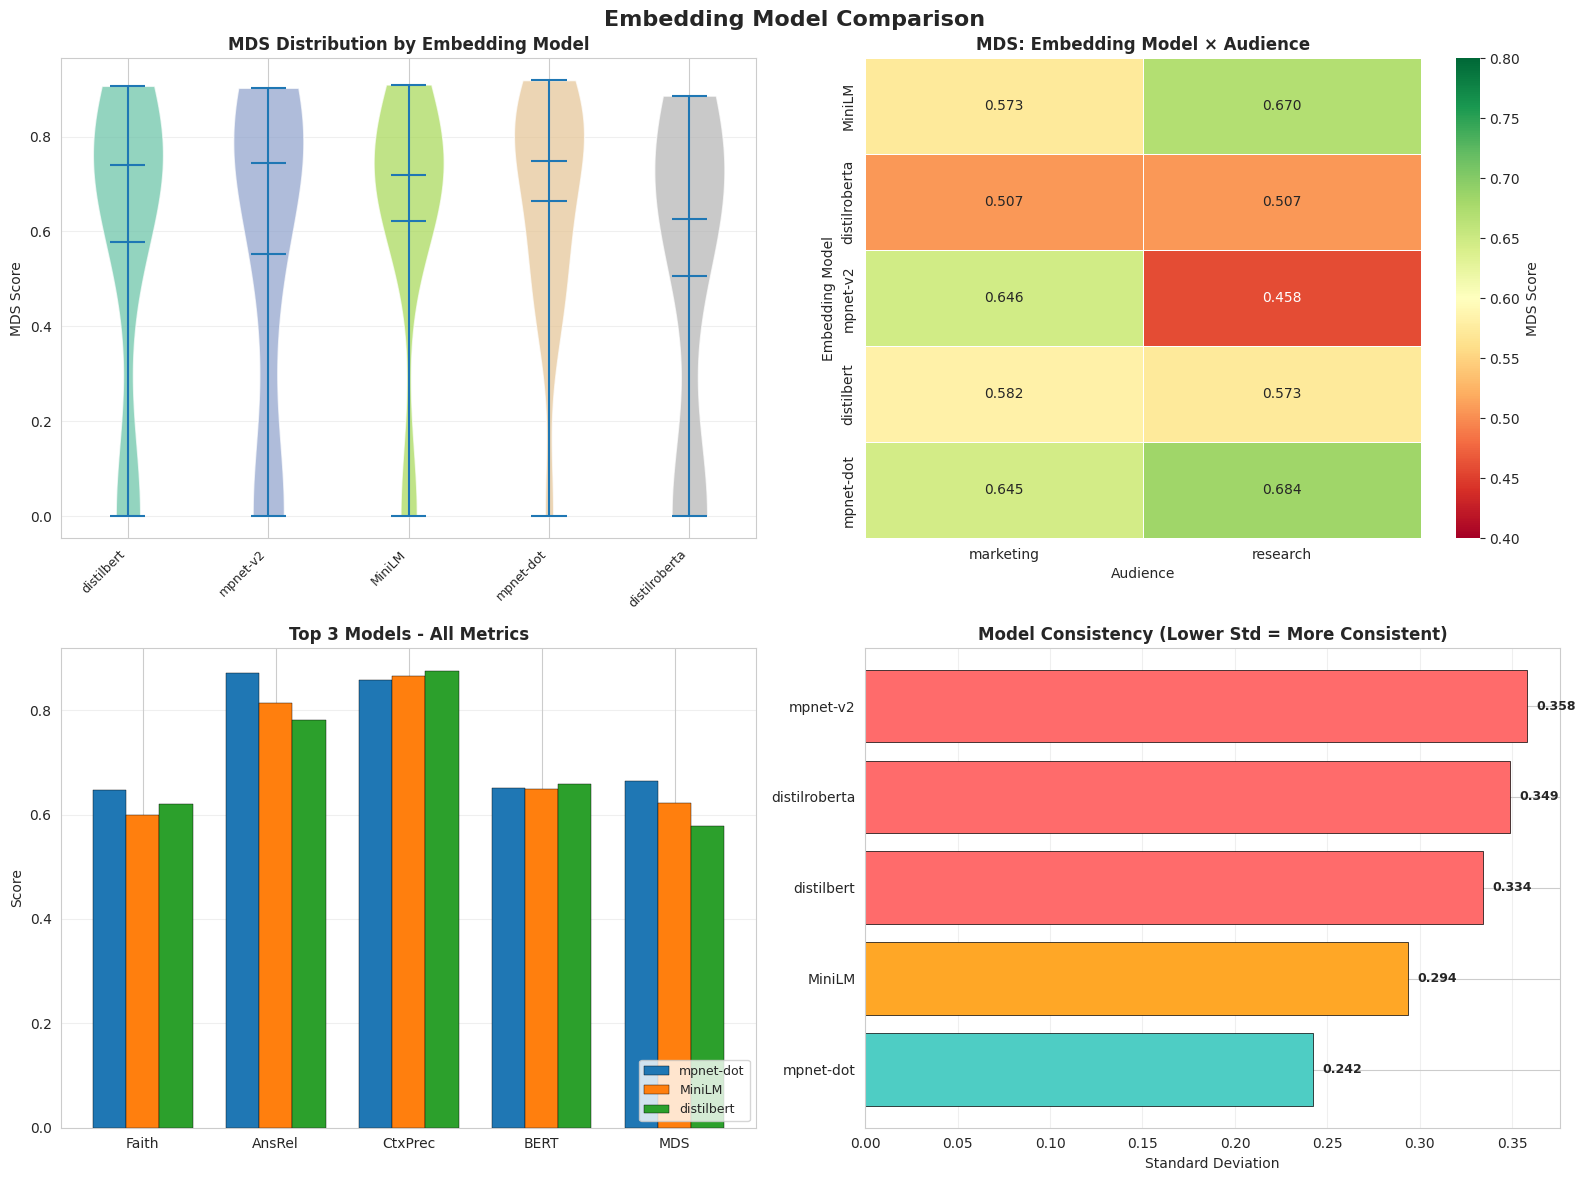

In [ ]:

"""
MDS Score Analysis - Embedding Models Visualization Script
Generates comprehensive charts for embedding model experiment with MDS metric
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration
INPUT_CSV = f'{output_folder}metric_results_embeddings_mds_1206.csv'
OUTPUT_DIR = output_folder

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (16, 12)
plt.rcParams['font.size'] = 10


def load_data(csv_path):
    """Load the experiment data"""
    df = pd.read_csv(csv_path)
    print(f"✓ Loaded {len(df)} rows")
    print(f"✓ Embedding models: {df['embedding_model'].nunique()}")
    print(f"✓ Questions: {df['question_num'].nunique()}")
    return df


def create_overview_visualization(df, output_path):
    """Create 6-panel overview visualization"""

    fig, axes = plt.subplots(3, 2, figsize=(16, 14))
    fig.suptitle('MDS Score Analysis - Embedding Models Experiment',
                 fontsize=16, fontweight='bold', y=0.995)

    # ========================================================================
    # 1. MDS by Embedding Model (horizontal bar)
    # ========================================================================
    ax = axes[0, 0]

    model_mds = df.groupby('embedding_model')['mds'].mean().sort_values(ascending=True)
    colors = ['#2E7D32' if i == len(model_mds)-1 else '#1976D2' if i >= len(model_mds)-2
              else '#FFA726' for i in range(len(model_mds))]

    bars = ax.barh(range(len(model_mds)), model_mds.values, color=colors,
                   edgecolor='black', linewidth=0.5)
    ax.set_yticks(range(len(model_mds)))
    ax.set_yticklabels(model_mds.index, fontsize=9)
    ax.set_title('MDS Score by Embedding Model', fontweight='bold', fontsize=12)
    ax.set_xlabel('MDS Score', fontsize=10)
    ax.grid(True, alpha=0.3, axis='x')

    for i, v in enumerate(model_mds.values):
        ax.text(v + 0.01, i, f'{v:.3f}', va='center', fontsize=9, fontweight='bold')

    ax.axvline(x=model_mds.mean(), color='red', linestyle='--', linewidth=2,
               label=f'Mean: {model_mds.mean():.3f}')
    ax.legend(loc='lower right', fontsize=9)

    # ========================================================================
    # 2. MDS by Question Number
    # ========================================================================
    ax = axes[0, 1]

    q_mds = df.groupby('question_num')['mds'].mean().sort_values(ascending=True)
    colors = ['#FF6B6B' if v < 0.4 else '#FFA726' if v < 0.6 else '#4ECDC4' for v in q_mds]

    ax.barh(range(len(q_mds)), q_mds.values, color=colors, edgecolor='black', linewidth=0.5)
    ax.set_yticks(range(len(q_mds)))
    ax.set_yticklabels([f'Q{q}' for q in q_mds.index])
    ax.set_title('MDS Score by Question Number', fontweight='bold', fontsize=12)
    ax.set_xlabel('MDS Score', fontsize=10)
    ax.grid(True, alpha=0.3, axis='x')

    # Threshold lines
    ax.axvline(x=0.6, color='green', linestyle='--', alpha=0.7, linewidth=1.5, label='Good (0.6)')
    ax.axvline(x=0.4, color='red', linestyle='--', alpha=0.7, linewidth=1.5, label='Fair (0.4)')
    ax.legend(loc='lower right', fontsize=9)

    # ========================================================================
    # 3. MDS by Audience Type (box plot)
    # ========================================================================
    ax = axes[1, 0]

    box_data = [df[df['audience_type']=='marketing']['mds'].dropna(),
                df[df['audience_type']=='research']['mds'].dropna()]

    bp = ax.boxplot(box_data, labels=['Marketing', 'Research'], patch_artist=True)

    colors_box = ['#FF6B6B', '#4ECDC4']
    for patch, color in zip(bp['boxes'], colors_box):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)

    for median in bp['medians']:
        median.set_color('red')
        median.set_linewidth(2)

    ax.set_title('MDS Distribution by Audience Type', fontweight='bold', fontsize=12)
    ax.set_ylabel('MDS Score', fontsize=10)
    ax.grid(True, alpha=0.3, axis='y')

    # Add mean markers
    means = df.groupby('audience_type')['mds'].mean()
    for i, (aud, mean_val) in enumerate(means.items()):
        ax.scatter(i+1, mean_val, color='blue', s=100, zorder=5, marker='D')
        ax.text(i+1.15, mean_val, f'μ={mean_val:.3f}', fontsize=9, fontweight='bold')

    # ========================================================================
    # 4. Marketing vs Research by Question
    # ========================================================================
    ax = axes[1, 1]

    pivot = df.pivot_table(values='mds', index='question_num', columns='audience_type', aggfunc='mean')
    pivot = pivot.sort_values('marketing', ascending=True)

    x = np.arange(len(pivot))
    width = 0.35

    ax.barh(x - width/2, pivot['marketing'], width, label='Marketing',
            color='#FF6B6B', edgecolor='black', linewidth=0.5)
    ax.barh(x + width/2, pivot['research'], width, label='Research',
            color='#4ECDC4', edgecolor='black', linewidth=0.5)

    ax.set_title('MDS: Marketing vs Research by Question', fontweight='bold', fontsize=12)
    ax.set_xlabel('MDS Score', fontsize=10)
    ax.set_yticks(x)
    ax.set_yticklabels([f'Q{q}' for q in pivot.index])
    ax.legend(loc='lower right', fontsize=10)
    ax.grid(True, alpha=0.3, axis='x')

    # ========================================================================
    # 5. Heatmap: Embedding Model × Question
    # ========================================================================
    ax = axes[2, 0]

    heatmap_data = df.pivot_table(values='mds', index='question_num',
                                   columns='embedding_model', aggfunc='mean')

    # Shorten model names
    short_names = {
        'multi-qa-mpnet-base-dot-v1': 'mpnet-dot',
        'all-MiniLM-L12-v2': 'MiniLM',
        'multi-qa-distilbert-cos-v1': 'distilbert',
        'all-mpnet-base-v2': 'mpnet-v2',
        'all-distilroberta-v1': 'distilroberta'
    }
    heatmap_data.columns = [short_names.get(c, c) for c in heatmap_data.columns]

    sns.heatmap(heatmap_data, annot=True, fmt='.2f', cmap='RdYlGn', ax=ax,
                cbar_kws={'label': 'MDS Score'}, linewidths=0.5, linecolor='gray',
                vmin=0, vmax=1)

    ax.set_title('MDS Heatmap: Question × Embedding Model', fontweight='bold', fontsize=12)
    ax.set_xlabel('Embedding Model', fontsize=10)
    ax.set_ylabel('Question', fontsize=10)
    ax.tick_params(axis='x', rotation=45, labelsize=9)

    # ========================================================================
    # 6. MDS Distribution Histogram
    # ========================================================================
    ax = axes[2, 1]

    ax.hist(df[df['audience_type']=='marketing']['mds'], bins=20, alpha=0.6,
            label='Marketing', color='#FF6B6B', edgecolor='black')
    ax.hist(df[df['audience_type']=='research']['mds'], bins=20, alpha=0.6,
            label='Research', color='#4ECDC4', edgecolor='black')

    ax.axvline(x=df['mds'].mean(), color='black', linestyle='--', linewidth=2,
               label=f'Overall Mean: {df["mds"].mean():.3f}')
    ax.axvline(x=df['mds'].median(), color='purple', linestyle=':', linewidth=2,
               label=f'Median: {df["mds"].median():.3f}')

    ax.set_title('MDS Score Distribution', fontweight='bold', fontsize=12)
    ax.set_xlabel('MDS Score', fontsize=10)
    ax.set_ylabel('Frequency', fontsize=10)
    ax.legend(loc='upper left', fontsize=9)
    ax.grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    print(f"✓ Saved: {output_path}")


def create_embedding_analysis_visualization(df, output_path):
    """Create embedding model focused visualization"""

    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('Embedding Model Analysis', fontsize=16, fontweight='bold')

    # ========================================================================
    # 1. Model Performance with Error Bars
    # ========================================================================
    ax = axes[0, 0]

    model_stats = df.groupby('embedding_model')['mds'].agg(['mean', 'std']).sort_values('mean', ascending=True)

    colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(model_stats)))

    ax.barh(range(len(model_stats)), model_stats['mean'], xerr=model_stats['std'],
            color=colors, edgecolor='black', linewidth=0.5, capsize=5)
    ax.set_yticks(range(len(model_stats)))
    ax.set_yticklabels(model_stats.index, fontsize=9)
    ax.set_title('MDS by Embedding Model (with Std Dev)', fontweight='bold', fontsize=12)
    ax.set_xlabel('MDS Score', fontsize=10)
    ax.grid(True, alpha=0.3, axis='x')

    # ========================================================================
    # 2. Model × Audience Comparison
    # ========================================================================
    ax = axes[0, 1]

    model_audience = df.pivot_table(values='mds', index='embedding_model',
                                     columns='audience_type', aggfunc='mean')
    model_audience = model_audience.sort_values('marketing', ascending=True)

    x = np.arange(len(model_audience))
    width = 0.35

    ax.barh(x - width/2, model_audience['marketing'], width,
            label='Marketing', color='#FF6B6B', edgecolor='black')
    ax.barh(x + width/2, model_audience['research'], width,
            label='Research', color='#4ECDC4', edgecolor='black')

    ax.set_title('MDS by Embedding Model & Audience', fontweight='bold', fontsize=12)
    ax.set_xlabel('MDS Score', fontsize=10)
    ax.set_yticks(x)
    ax.set_yticklabels(model_audience.index, fontsize=9)
    ax.legend(loc='lower right', fontsize=10)
    ax.grid(True, alpha=0.3, axis='x')

    # ========================================================================
    # 3. Component Metrics by Model
    # ========================================================================
    ax = axes[1, 0]

    metrics = ['ragas_score_faithfulness', 'ragas_score_answer_relevancy',
               'ragas_score_context_precision', 'bert_score_f1']
    metric_names = ['Faithfulness', 'Answer Rel.', 'Context Prec.', 'BERT F1']

    model_metrics = df.groupby('embedding_model')[metrics].mean()
    model_metrics = model_metrics.sort_values('ragas_score_faithfulness', ascending=True)

    x = np.arange(len(model_metrics))
    width = 0.2

    for i, (metric, name) in enumerate(zip(metrics, metric_names)):
        ax.bar(x + i*width, model_metrics[metric], width, label=name,
               edgecolor='black', linewidth=0.3)

    ax.set_xticks(x + width * 1.5)
    ax.set_xticklabels(model_metrics.index, rotation=45, ha='right', fontsize=8)
    ax.set_title('MDS Component Metrics by Embedding Model', fontweight='bold', fontsize=12)
    ax.set_ylabel('Score', fontsize=10)
    ax.legend(loc='lower right', fontsize=9)
    ax.grid(True, alpha=0.3, axis='y')

    # ========================================================================
    # 4. Zero MDS Count by Model
    # ========================================================================
    ax = axes[1, 1]

    zero_mds = df[df['mds'] < 0.001]
    zero_by_model = zero_mds.groupby('embedding_model').size().sort_values(ascending=True)

    # Add models with zero count
    all_models = df['embedding_model'].unique()
    for model in all_models:
        if model not in zero_by_model.index:
            zero_by_model[model] = 0
    zero_by_model = zero_by_model.sort_values(ascending=True)

    colors = ['#4ECDC4' if v <= 2 else '#FFA726' if v <= 5 else '#FF6B6B' for v in zero_by_model]

    ax.barh(range(len(zero_by_model)), zero_by_model.values, color=colors,
            edgecolor='black', linewidth=0.5)
    ax.set_yticks(range(len(zero_by_model)))
    ax.set_yticklabels(zero_by_model.index, fontsize=9)
    ax.set_title(f'Zero MDS Failures by Model (Total: {len(zero_mds)})',
                 fontweight='bold', fontsize=12)
    ax.set_xlabel('Count of Zero MDS Rows', fontsize=10)
    ax.grid(True, alpha=0.3, axis='x')

    for i, v in enumerate(zero_by_model.values):
        ax.text(v + 0.1, i, str(v), va='center', fontweight='bold')

    plt.tight_layout()
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    print(f"✓ Saved: {output_path}")


def create_question_analysis_visualization(df, output_path):
    """Create question-focused visualization"""

    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('Question Analysis - Embedding Models', fontsize=16, fontweight='bold')

    # ========================================================================
    # 1. Question Performance Ranking
    # ========================================================================
    ax = axes[0, 0]

    q_stats = df.groupby('question_num')['mds'].agg(['mean', 'std']).sort_values('mean', ascending=True)

    colors = ['#FF6B6B' if m < 0.4 else '#FFA726' if m < 0.6 else '#4ECDC4' for m in q_stats['mean']]

    ax.barh(range(len(q_stats)), q_stats['mean'], xerr=q_stats['std'],
            color=colors, edgecolor='black', linewidth=0.5, capsize=3)
    ax.set_yticks(range(len(q_stats)))
    ax.set_yticklabels([f'Q{q}' for q in q_stats.index])
    ax.set_title('MDS by Question (with Std Dev)', fontweight='bold', fontsize=12)
    ax.set_xlabel('MDS Score', fontsize=10)
    ax.grid(True, alpha=0.3, axis='x')

    ax.axvline(x=0.6, color='green', linestyle='--', alpha=0.7, linewidth=1.5)
    ax.axvline(x=0.4, color='red', linestyle='--', alpha=0.7, linewidth=1.5)

    # ========================================================================
    # 2. Research - Marketing Difference by Question
    # ========================================================================
    ax = axes[0, 1]

    pivot = df.pivot_table(values='mds', index='question_num', columns='audience_type', aggfunc='mean')
    pivot['diff'] = pivot['research'] - pivot['marketing']
    pivot = pivot.sort_values('diff', ascending=True)

    colors = ['#FF6B6B' if d < 0 else '#4ECDC4' for d in pivot['diff']]

    ax.barh(range(len(pivot)), pivot['diff'], color=colors, edgecolor='black', linewidth=0.5)
    ax.set_yticks(range(len(pivot)))
    ax.set_yticklabels([f'Q{q}' for q in pivot.index])
    ax.set_title('MDS Difference (Research - Marketing)', fontweight='bold', fontsize=12)
    ax.set_xlabel('Difference', fontsize=10)
    ax.axvline(x=0, color='black', linestyle='-', linewidth=1)
    ax.grid(True, alpha=0.3, axis='x')

    ax.text(0.95, 0.95, '← Marketing Better | Research Better →',
            transform=ax.transAxes, fontsize=9, ha='right', va='top', style='italic')

    # ========================================================================
    # 3. Best Embedding Model per Question
    # ========================================================================
    ax = axes[1, 0]

    from collections import Counter

    best_models = []
    for q_num in df['question_num'].unique():
        q_data = df[df['question_num'] == q_num].groupby('embedding_model')['mds'].mean()
        best_models.append(q_data.idxmax())

    model_wins = Counter(best_models)
    models = list(model_wins.keys())
    counts = list(model_wins.values())

    # Sort by count
    sorted_data = sorted(zip(counts, models), reverse=True)
    counts, models = zip(*sorted_data)

    # Shorten names
    short_names = {
        'multi-qa-mpnet-base-dot-v1': 'mpnet-dot',
        'all-MiniLM-L12-v2': 'MiniLM',
        'multi-qa-distilbert-cos-v1': 'distilbert',
        'all-mpnet-base-v2': 'mpnet-v2',
        'all-distilroberta-v1': 'distilroberta'
    }
    short_models = [short_names.get(m, m) for m in models]

    colors = ['#2E7D32' if c == max(counts) else '#1976D2' for c in counts]

    ax.bar(range(len(models)), counts, color=colors, edgecolor='black', linewidth=0.5)
    ax.set_xticks(range(len(models)))
    ax.set_xticklabels(short_models, rotation=45, ha='right', fontsize=9)
    ax.set_title('Model Win Count (Best MDS per Question)', fontweight='bold', fontsize=12)
    ax.set_ylabel('Questions Won', fontsize=10)
    ax.grid(True, alpha=0.3, axis='y')

    for i, v in enumerate(counts):
        ax.text(i, v + 0.1, str(v), ha='center', fontweight='bold', fontsize=10)

    # ========================================================================
    # 4. Zero MDS by Question
    # ========================================================================
    ax = axes[1, 1]

    zero_mds = df[df['mds'] < 0.001]

    if len(zero_mds) > 0:
        zero_by_q = zero_mds.groupby('question_num').size().sort_values(ascending=True)

        colors = ['#FFA726' if v <= 3 else '#FF6B6B' for v in zero_by_q]

        ax.barh(range(len(zero_by_q)), zero_by_q.values, color=colors, edgecolor='black')
        ax.set_yticks(range(len(zero_by_q)))
        ax.set_yticklabels([f'Q{q}' for q in zero_by_q.index])
        ax.set_title(f'Zero MDS Rows by Question (Total: {len(zero_mds)})',
                     fontweight='bold', fontsize=12)
        ax.set_xlabel('Count', fontsize=10)
        ax.grid(True, alpha=0.3, axis='x')

        for i, v in enumerate(zero_by_q.values):
            ax.text(v + 0.1, i, str(v), va='center', fontweight='bold')

    plt.tight_layout()
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    print(f"✓ Saved: {output_path}")


def create_comparison_visualization(df, output_path):
    """Create detailed comparison visualization"""

    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('Embedding Model Comparison', fontsize=16, fontweight='bold')

    # ========================================================================
    # 1. Violin Plot by Model
    # ========================================================================
    ax = axes[0, 0]

    models = df['embedding_model'].unique()
    model_data = [df[df['embedding_model']==m]['mds'].dropna() for m in models]

    # Shorten names
    short_names = {
        'multi-qa-mpnet-base-dot-v1': 'mpnet-dot',
        'all-MiniLM-L12-v2': 'MiniLM',
        'multi-qa-distilbert-cos-v1': 'distilbert',
        'all-mpnet-base-v2': 'mpnet-v2',
        'all-distilroberta-v1': 'distilroberta'
    }
    short_labels = [short_names.get(m, m) for m in models]

    parts = ax.violinplot(model_data, positions=range(len(models)),
                          showmeans=True, showmedians=True)

    colors = plt.cm.Set2(np.linspace(0, 1, len(models)))
    for i, pc in enumerate(parts['bodies']):
        pc.set_facecolor(colors[i])
        pc.set_alpha(0.7)

    ax.set_xticks(range(len(models)))
    ax.set_xticklabels(short_labels, rotation=45, ha='right', fontsize=9)
    ax.set_title('MDS Distribution by Embedding Model', fontweight='bold', fontsize=12)
    ax.set_ylabel('MDS Score', fontsize=10)
    ax.grid(True, alpha=0.3, axis='y')

    # ========================================================================
    # 2. Heatmap: Model × Audience
    # ========================================================================
    ax = axes[0, 1]

    model_aud = df.pivot_table(values='mds', index='embedding_model',
                                columns='audience_type', aggfunc='mean')
    model_aud.index = [short_names.get(m, m) for m in model_aud.index]

    sns.heatmap(model_aud, annot=True, fmt='.3f', cmap='RdYlGn', ax=ax,
                cbar_kws={'label': 'MDS Score'}, linewidths=0.5, vmin=0.4, vmax=0.8)

    ax.set_title('MDS: Embedding Model × Audience', fontweight='bold', fontsize=12)
    ax.set_xlabel('Audience', fontsize=10)
    ax.set_ylabel('Embedding Model', fontsize=10)

    # ========================================================================
    # 3. Radar Chart - Model Comparison
    # ========================================================================
    ax = axes[1, 0]

    metrics = ['ragas_score_faithfulness', 'ragas_score_answer_relevancy',
               'ragas_score_context_precision', 'bert_score_f1', 'mds']
    metric_labels = ['Faith', 'AnsRel', 'CtxPrec', 'BERT', 'MDS']

    # Get top 3 models
    top_models = df.groupby('embedding_model')['mds'].mean().nlargest(3).index

    # Bar chart instead of radar for simplicity
    x = np.arange(len(metrics))
    width = 0.25

    for i, model in enumerate(top_models):
        model_scores = df[df['embedding_model']==model][metrics].mean()
        short_name = short_names.get(model, model)
        ax.bar(x + i*width, model_scores, width, label=short_name,
               edgecolor='black', linewidth=0.3)

    ax.set_xticks(x + width)
    ax.set_xticklabels(metric_labels)
    ax.set_title('Top 3 Models - All Metrics', fontweight='bold', fontsize=12)
    ax.set_ylabel('Score', fontsize=10)
    ax.legend(loc='lower right', fontsize=9)
    ax.grid(True, alpha=0.3, axis='y')

    # ========================================================================
    # 4. Model Consistency (Std Dev)
    # ========================================================================
    ax = axes[1, 1]

    model_consistency = df.groupby('embedding_model')['mds'].std().sort_values(ascending=True)
    model_consistency.index = [short_names.get(m, m) for m in model_consistency.index]

    colors = ['#4ECDC4' if v < 0.27 else '#FFA726' if v < 0.32 else '#FF6B6B'
              for v in model_consistency]

    ax.barh(range(len(model_consistency)), model_consistency.values,
            color=colors, edgecolor='black', linewidth=0.5)
    ax.set_yticks(range(len(model_consistency)))
    ax.set_yticklabels(model_consistency.index)
    ax.set_title('Model Consistency (Lower Std = More Consistent)', fontweight='bold', fontsize=12)
    ax.set_xlabel('Standard Deviation', fontsize=10)
    ax.grid(True, alpha=0.3, axis='x')

    for i, v in enumerate(model_consistency.values):
        ax.text(v + 0.005, i, f'{v:.3f}', va='center', fontsize=9, fontweight='bold')

    plt.tight_layout()
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    print(f"✓ Saved: {output_path}")


def print_summary(df):
    """Print key findings summary"""

    print("\n" + "=" * 80)
    print("EMBEDDING MODEL MDS ANALYSIS SUMMARY")
    print("=" * 80)

    # Overall stats
    print(f"\nOverall MDS: {df['mds'].mean():.4f} (±{df['mds'].std():.4f})")
    print(f"   Median: {df['mds'].median():.4f}")

    # Best model
    best_model = df.groupby('embedding_model')['mds'].mean().idxmax()
    best_score = df.groupby('embedding_model')['mds'].mean().max()
    print(f"\nBest Embedding Model: {best_model}")
    print(f"   MDS: {best_score:.4f}")

    # Worst model
    worst_model = df.groupby('embedding_model')['mds'].mean().idxmin()
    worst_score = df.groupby('embedding_model')['mds'].mean().min()
    print(f"\nWorst Embedding Model: {worst_model}")
    print(f"   MDS: {worst_score:.4f}")

    # Audience comparison
    mkt_mean = df[df['audience_type']=='marketing']['mds'].mean()
    res_mean = df[df['audience_type']=='research']['mds'].mean()
    print(f"\nAudience Comparison:")
    print(f"   Marketing: {mkt_mean:.4f}")
    print(f"   Research:  {res_mean:.4f}")
    print(f"   Winner:    {'Research' if res_mean > mkt_mean else 'Marketing'} ({abs(res_mean-mkt_mean):+.4f})")

    # Problem questions
    q_mds = df.groupby('question_num')['mds'].mean()
    problem_qs = q_mds[q_mds < 0.4].index.tolist()
    print(f"\nProblem Questions (MDS < 0.4): {problem_qs}")

    # Zero MDS count
    zero_count = (df['mds'] < 0.001).sum()
    print(f"\n Rows with Zero MDS: {zero_count} ({zero_count/len(df)*100:.1f}%)")




print("\n" + "=" * 80)
print("MDS SCORE ANALYSIS - EMBEDDING MODELS VISUALIZATION")
print("=" * 80)

# Load data
df = load_data(INPUT_CSV)

# Print summary
print_summary(df)

# Generate visualizations
print("\n" + "=" * 80)
print("GENERATING VISUALIZATIONS")
print("=" * 80)

create_overview_visualization(df, OUTPUT_DIR + 'embeddings_mds_overview.png')
create_embedding_analysis_visualization(df, OUTPUT_DIR + 'embeddings_mds_model_analysis.png')
create_question_analysis_visualization(df, OUTPUT_DIR + 'embeddings_mds_question_analysis.png')
create_comparison_visualization(df, OUTPUT_DIR + 'embeddings_mds_comparison.png')





---

MDS Score Analysis - Embedding Models

Overview

| Metric | Value |
|--------|-------|
| **Total Rows** | 150 |
| **Embedding Models** | 5 |
| **Questions** | 15 |
| **Audience Types** | Marketing, Research |
| **Mean MDS** | 0.5844 |
| **Median MDS** | 0.7210 |
| **Zero MDS Rows** | 31 (20.7%) |

---

Embedding Model Rankings

| Rank | Embedding Model | MDS Mean | MDS Std | Faith | AnsRel |
|------|-----------------|----------|---------|-------|--------|
| 1 | **multi-qa-mpnet-base-dot-v1** | **0.6643** | 0.2420 | 0.647 | 0.872 |
| 2 | all-MiniLM-L12-v2 | 0.6216 | 0.2936 | 0.600 | 0.814 |
| 3 | multi-qa-distilbert-cos-v1 | 0.5772 | 0.3343 | 0.621 | 0.781 |
| 4 | all-mpnet-base-v2 | 0.5523 | 0.3578 | 0.678 | 0.716 |
| 5 | all-distilroberta-v1 | 0.5066 | 0.3489 | 0.659 | 0.691 |

---

Audience Comparison

| Audience | MDS Mean | MDS Median |
|----------|----------|------------|
| Marketing | 0.5904 | 0.6737 |
| Research | 0.5784 | 0.7571 |
| **Difference** | **-0.012** | Marketing slightly better |

---

MDS by Question and Audience

| Q# | MDS (Mkt) | MDS (Res) | Diff | Faith (Mkt) | Faith (Res) |
|-----|-----------|-----------|------|-------------|-------------|
| Q63 | 0.8052 | 0.8238 | +0.019 | 0.702 | 0.735 |
| Q27 | 0.7862 | 0.8064 | +0.020 | 0.689 | 0.777 |
| Q103 | 0.8149 | 0.7535 | -0.061 | 0.690 | 0.676 |
| Q33 | 0.7735 | 0.7528 | -0.021 | 0.742 | 0.674 |
| Q0 | 0.7652 | 0.7534 | -0.012 | 0.841 | 0.838 |
| Q92 | 0.7701 | 0.7331 | -0.037 | 0.835 | 0.710 |
| Q95 | 0.6571 | 0.6596 | +0.003 | 0.512 | 0.920 |
| Q53 | 0.6799 | 0.6299 | -0.050 | 0.507 | 0.816 |
| Q76 | 0.4718 | **0.7778** | **+0.306** | 0.463 | 0.726 |
| Q110 | 0.5952 | 0.6027 | +0.008 | 0.367 | 0.771 |
| Q87 | 0.5022 | 0.6030 | +0.101 | 0.530 | 0.682 |
| Q28 | 0.5102 | 0.3301 | **-0.180** | 0.833 | 0.723 |
| Q11 | 0.5025 | 0.2839 | **-0.219** | 0.447 | 0.727 |
| Q7 | 0.2225 | 0.0750 | -0.147 | 0.483 | 0.029 |
| Q19 | 0.0000 | 0.0910 | +0.091 | 0.080 | 0.700 |
| **AVG** | **0.5904** | **0.5784** | **-0.012** | **0.581** | **0.700** |

---

Problematic Rows (MDS ≈ 0)

**31 rows** have zero MDS due to zero values in metrics:

| Question | Zero MDS Count | Root Cause |
|----------|----------------|------------|
| Q19 | 9 | Zero Faithfulness / Answer Relevancy |
| Q7 | 7 | Zero Answer Relevancy / Faithfulness |
| Q28 | 5 | Zero Answer Relevancy |
| Q11 | 4 | Zero Faithfulness / Answer Relevancy |

| Embedding Model | Zero MDS Count |
|-----------------|----------------|
| all-distilroberta-v1 | 9 (worst) |
| all-mpnet-base-v2 | 8 |
| multi-qa-distilbert-cos-v1 | 7 |
| all-MiniLM-L12-v2 | 5 |
| **multi-qa-mpnet-base-dot-v1** | **2 (best)** |

---

Best Embedding Model per Question

| Model | Questions Won |
|-------|---------------|
| **multi-qa-mpnet-base-dot-v1** | 5 (Q0, Q7, Q19, Q33, Q87) |
| all-mpnet-base-v2 | 4 (Q27, Q53, Q63, Q103) |
| all-MiniLM-L12-v2 | 2 (Q11, Q28) |
| multi-qa-distilbert-cos-v1 | 2 (Q76, Q95) |
| all-distilroberta-v1 | 2 (Q92, Q110) |

---

Key Insights

1. **Best Model:** `multi-qa-mpnet-base-dot-v1` (MDS: 0.6643)
   - Highest average MDS
   - Fewest zero-MDS failures (only 2)
   - Best for Research audience

2. **Runner-up:** `all-MiniLM-L12-v2` (MDS: 0.6216)
   - Good balance of quality and speed

3. **Avoid:** `all-distilroberta-v1` (MDS: 0.5066)
   - Lowest performance
   - Most zero-MDS failures (9)

4. **Audience Difference:** Unlike LLM params, embeddings show **Marketing slightly better** overall (-1.2%)

5. **Biggest Gaps:**
   - Q76: Research +30.6% better
   - Q11: Marketing +21.9% better
   - Q28: Marketing +18.0% better

6. **Problem Questions:** Q19, Q7, Q28, Q11 need investigation (zero Faithfulness/Answer Relevancy)




### Analysis for Experiment 3 : LLM params with MDS

Metric Scores for experiment outputs: metric_results_llm_mds_1206.csv


MDS SCORE ANALYSIS - VISUALIZATION
✓ Loaded 240 rows
✓ Configurations: 8
✓ Questions: 15

 MDS ANALYSIS SUMMARY

 Overall MDS: 0.6931 (±0.2458)

 Best Config: low_temp_wide_nucleus (MDS: 0.7419)

 Audience Comparison:
   Marketing: 0.6679
   Research:  0.7183
   Winner:    Research (+0.0503)

 Problem Questions (MDS < 0.5): [19, 76]

 Rows with Zero MDS: 22

GENERATING VISUALIZATIONS
✓ Saved: /content/drive/MyDrive/MIDS_267/final_project/output/mds_overview.png
✓ Saved: /content/drive/MyDrive/MIDS_267/final_project/output/mds_config_analysis.png
✓ Saved: /content/drive/MyDrive/MIDS_267/final_project/output/mds_question_analysis.png
✓ Saved: /content/drive/MyDrive/MIDS_267/final_project/output/mds_audience_comparison.png

✓ COMPLETE!

Generated files:
  1. /content/drive/MyDrive/MIDS_267/final_project/output/mds_overview.png
  2. /content/drive/MyDrive/MIDS_267/final_project/output/mds_config_analysis.png
  3. /content/drive/MyDrive/MIDS_267/final_project/output/mds_question_analysis.p

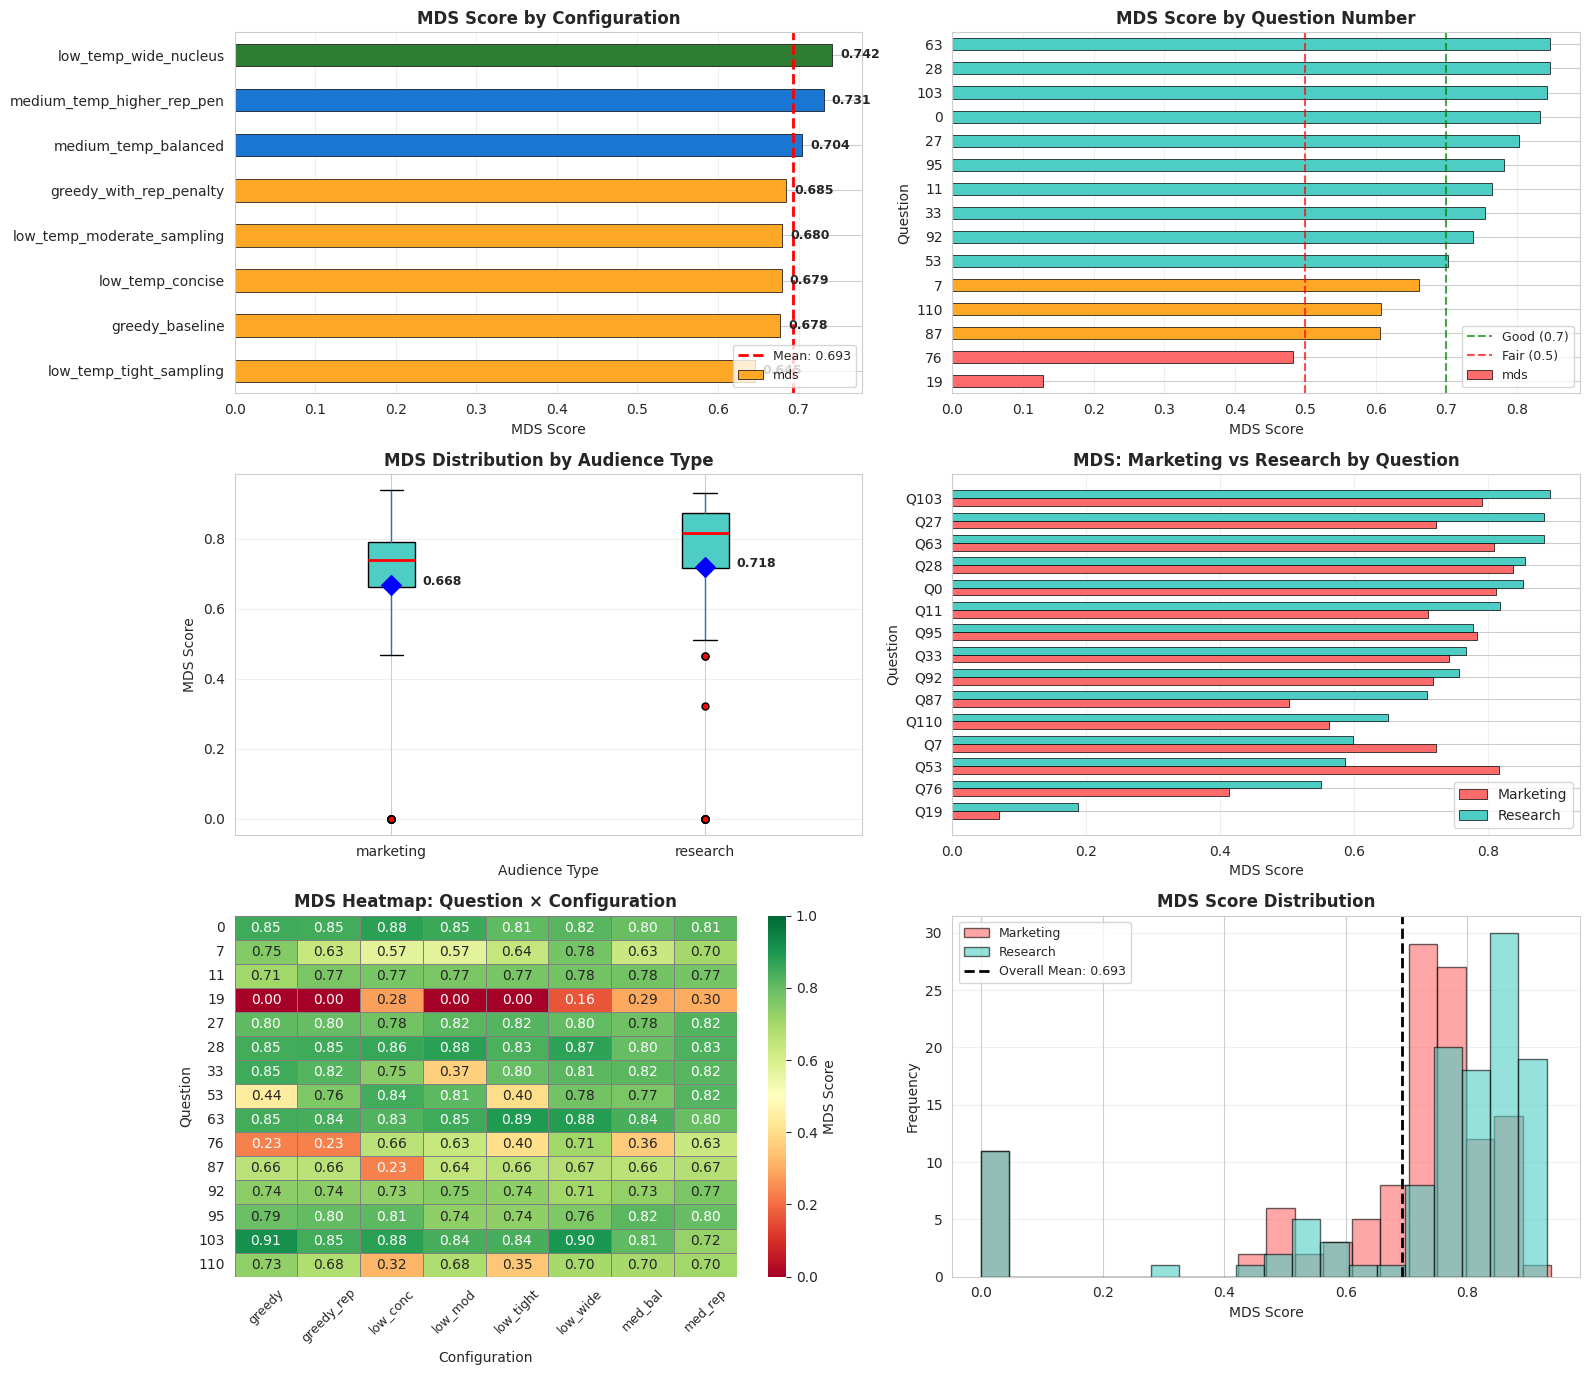

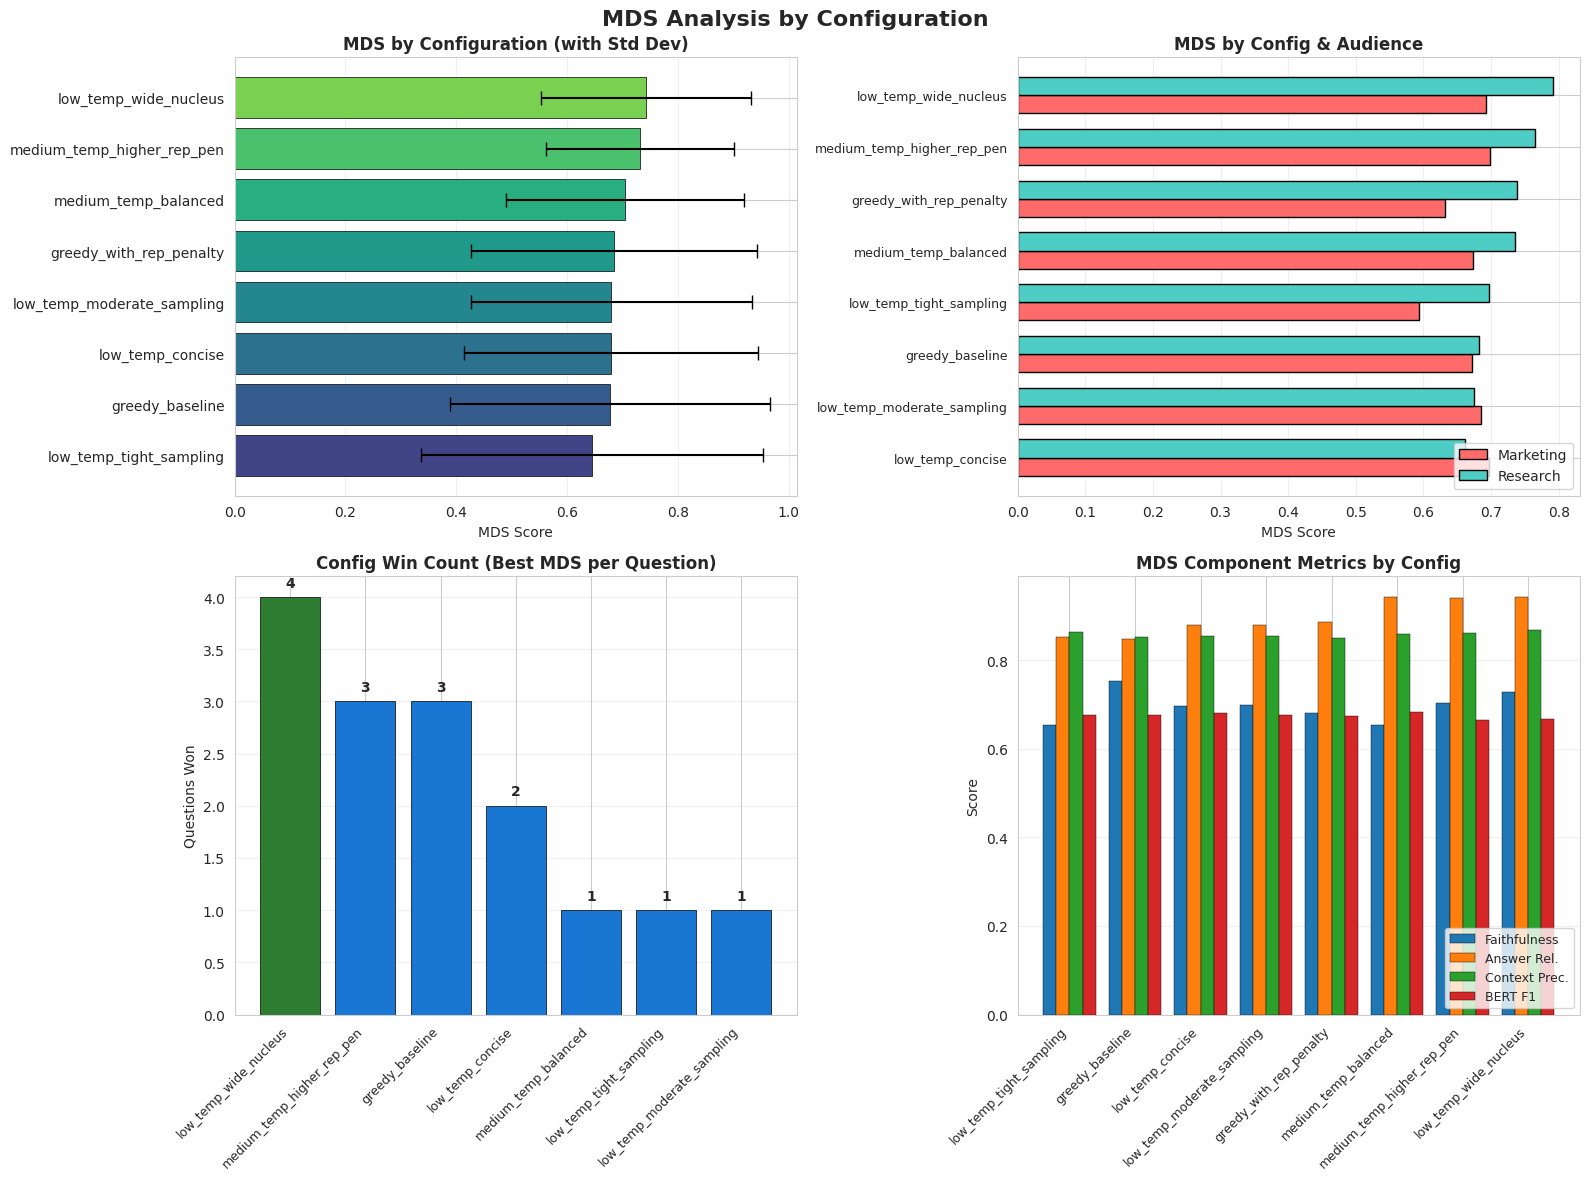

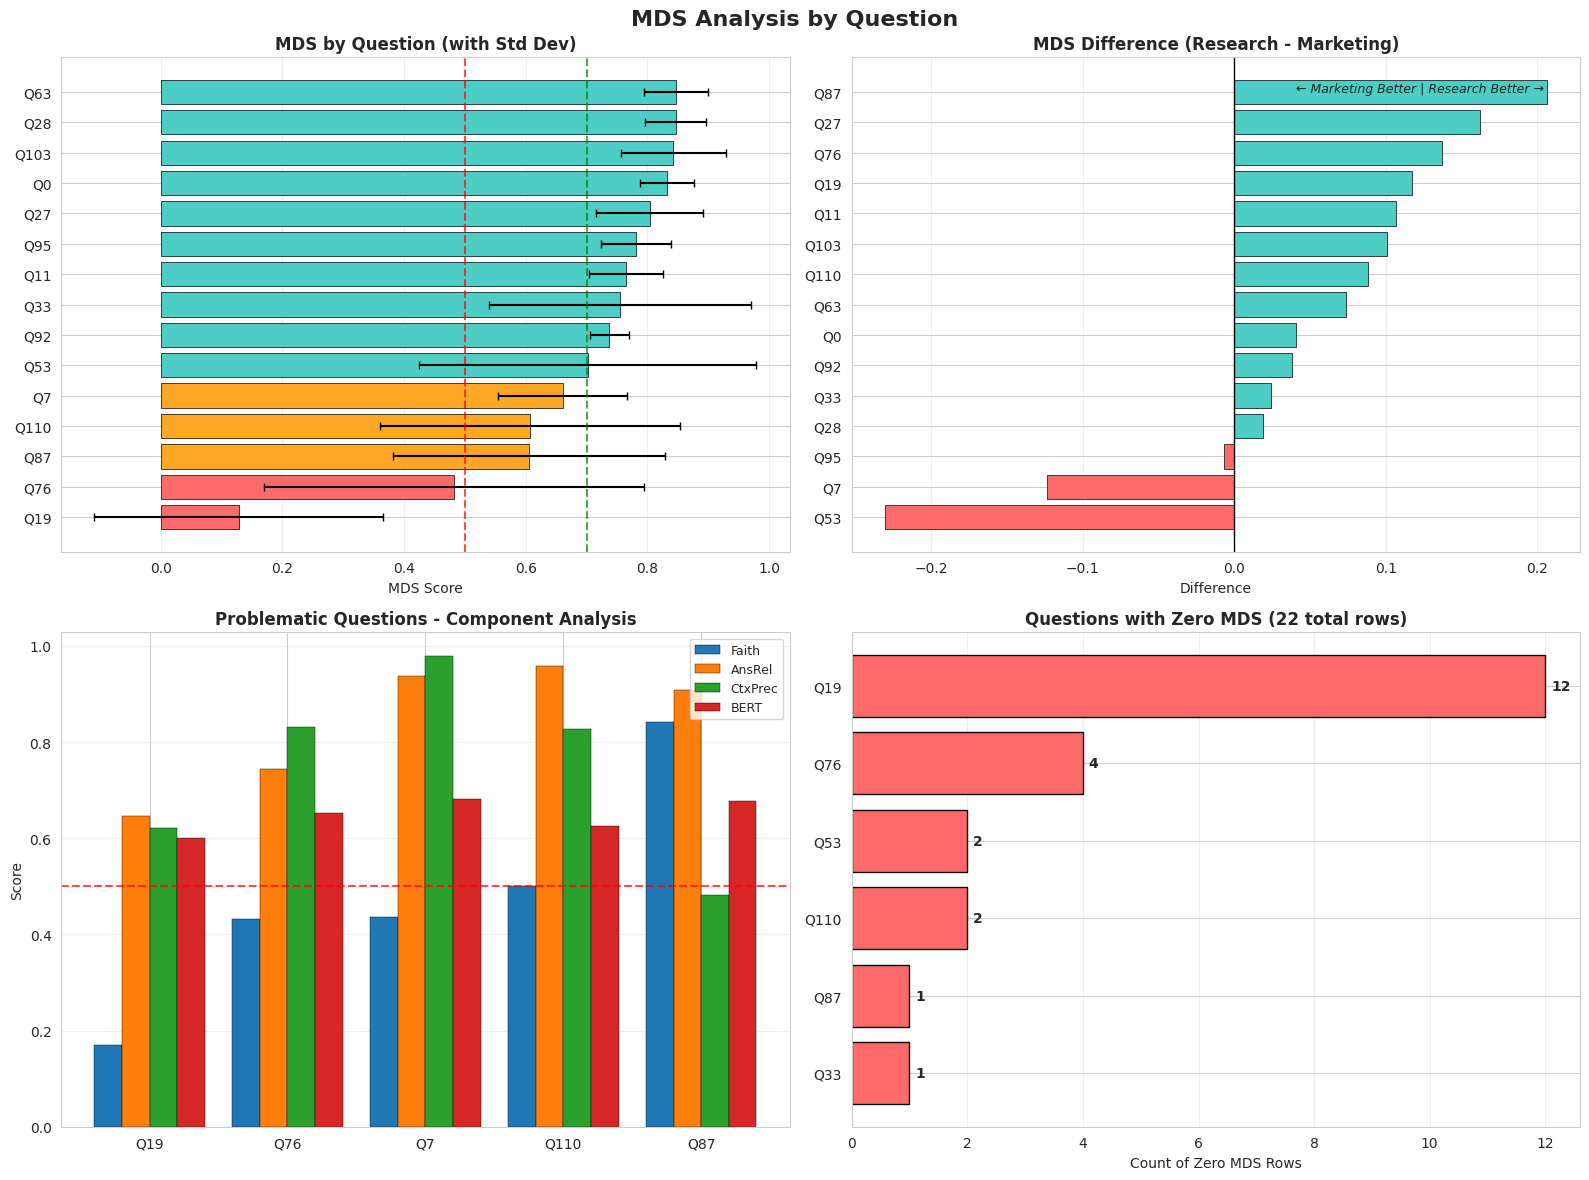

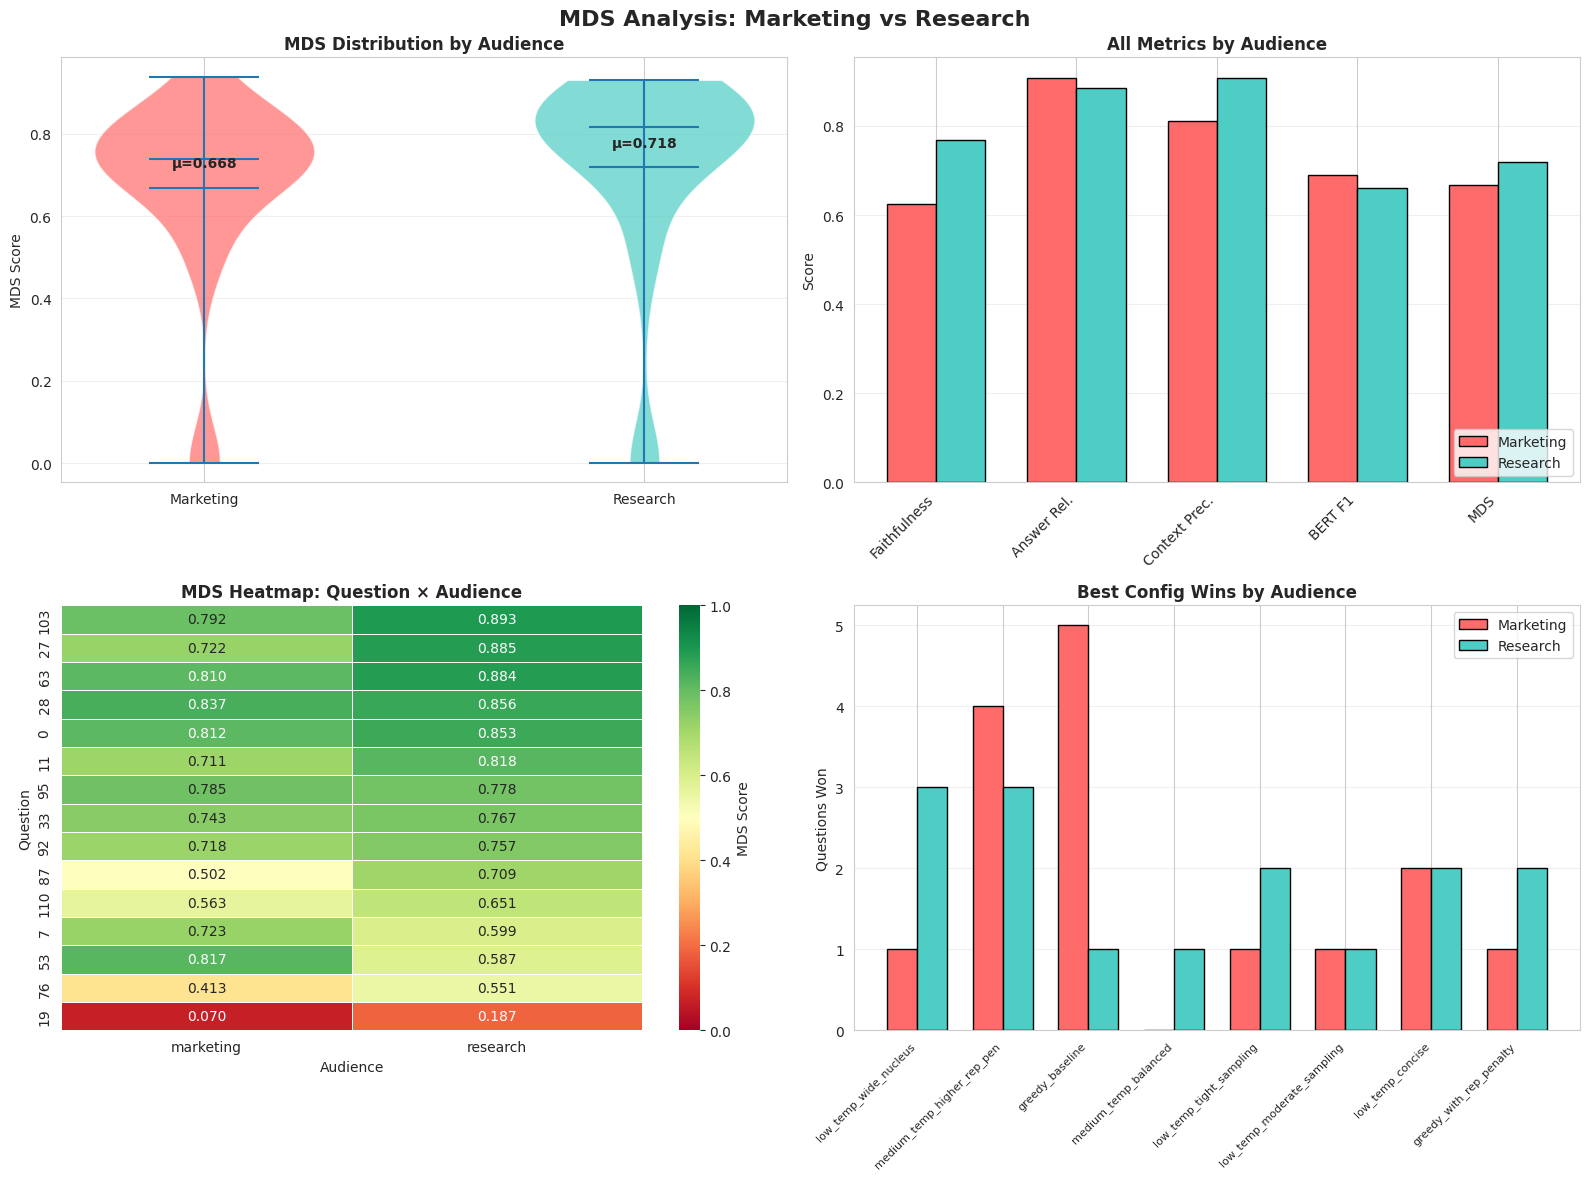

In [ ]:

"""
MDS Score Analysis - Visualization Script
Generates comprehensive charts for LLM parameter experiment with MDS metric
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration
INPUT_CSV = f'{output_folder}metric_results_llm_mds_1206.csv'
OUTPUT_DIR =output_folder

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (16, 12)
plt.rcParams['font.size'] = 10


def load_data(csv_path):
    """Load the experiment data"""
    df = pd.read_csv(csv_path)
    print(f"✓ Loaded {len(df)} rows")
    print(f"✓ Configurations: {df['config_name'].nunique()}")
    print(f"✓ Questions: {df['question_num'].nunique()}")
    return df


def create_overview_visualization(df, output_path):
    """Create 6-panel overview visualization"""

    fig, axes = plt.subplots(3, 2, figsize=(16, 14))
    fig.suptitle('MDS Score Analysis - LLM Parameter Experiment',
                 fontsize=16, fontweight='bold', y=0.995)

    # ========================================================================
    # 1. MDS by Configuration (horizontal bar)
    # ========================================================================
    ax = axes[0, 0]

    config_mds = df.groupby('config_name')['mds'].mean().sort_values(ascending=True)
    colors = ['#2E7D32' if i == len(config_mds)-1 else '#1976D2' if i >= len(config_mds)-3
              else '#FFA726' for i in range(len(config_mds))]

    config_mds.plot(kind='barh', ax=ax, color=colors, edgecolor='black', linewidth=0.5)
    ax.set_title('MDS Score by Configuration', fontweight='bold', fontsize=12)
    ax.set_xlabel('MDS Score', fontsize=10)
    ax.set_ylabel('')
    ax.grid(True, alpha=0.3, axis='x')

    for i, v in enumerate(config_mds):
        ax.text(v + 0.01, i, f'{v:.3f}', va='center', fontsize=9, fontweight='bold')

    ax.axvline(x=config_mds.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {config_mds.mean():.3f}')
    ax.legend(loc='lower right', fontsize=9)

    # ========================================================================
    # 2. MDS by Question Number
    # ========================================================================
    ax = axes[0, 1]

    q_mds = df.groupby('question_num')['mds'].mean().sort_values(ascending=True)
    colors = ['#FF6B6B' if v < 0.5 else '#FFA726' if v < 0.7 else '#4ECDC4' for v in q_mds]

    q_mds.plot(kind='barh', ax=ax, color=colors, edgecolor='black', linewidth=0.5)
    ax.set_title('MDS Score by Question Number', fontweight='bold', fontsize=12)
    ax.set_xlabel('MDS Score', fontsize=10)
    ax.set_ylabel('Question', fontsize=10)
    ax.grid(True, alpha=0.3, axis='x')

    # Threshold lines
    ax.axvline(x=0.7, color='green', linestyle='--', alpha=0.7, linewidth=1.5, label='Good (0.7)')
    ax.axvline(x=0.5, color='red', linestyle='--', alpha=0.7, linewidth=1.5, label='Fair (0.5)')
    ax.legend(loc='lower right', fontsize=9)

    # ========================================================================
    # 3. MDS by Audience Type (box plot)
    # ========================================================================
    ax = axes[1, 0]

    df.boxplot(column='mds', by='audience_type', ax=ax,
               patch_artist=True,
               boxprops=dict(facecolor='#4ECDC4', color='black'),
               medianprops=dict(color='red', linewidth=2),
               flierprops=dict(marker='o', markerfacecolor='red', markersize=5))

    ax.set_title('MDS Distribution by Audience Type', fontweight='bold', fontsize=12)
    ax.set_xlabel('Audience Type', fontsize=10)
    ax.set_ylabel('MDS Score', fontsize=10)
    plt.suptitle('')  # Remove automatic title
    ax.grid(True, alpha=0.3, axis='y')

    # Add mean markers
    means = df.groupby('audience_type')['mds'].mean()
    for i, (aud, mean_val) in enumerate(means.items()):
        ax.scatter(i+1, mean_val, color='blue', s=100, zorder=5, marker='D', label='Mean' if i==0 else '')
        ax.text(i+1.1, mean_val, f'{mean_val:.3f}', fontsize=9, fontweight='bold')

    # ========================================================================
    # 4. Marketing vs Research by Question
    # ========================================================================
    ax = axes[1, 1]

    pivot = df.pivot_table(values='mds', index='question_num', columns='audience_type', aggfunc='mean')
    pivot = pivot.sort_values('research', ascending=True)

    x = np.arange(len(pivot))
    width = 0.35

    bars1 = ax.barh(x - width/2, pivot['marketing'], width, label='Marketing',
                    color='#FF6B6B', edgecolor='black', linewidth=0.5)
    bars2 = ax.barh(x + width/2, pivot['research'], width, label='Research',
                    color='#4ECDC4', edgecolor='black', linewidth=0.5)

    ax.set_title('MDS: Marketing vs Research by Question', fontweight='bold', fontsize=12)
    ax.set_xlabel('MDS Score', fontsize=10)
    ax.set_ylabel('Question', fontsize=10)
    ax.set_yticks(x)
    ax.set_yticklabels([f'Q{q}' for q in pivot.index])
    ax.legend(loc='lower right', fontsize=10)
    ax.grid(True, alpha=0.3, axis='x')

    # ========================================================================
    # 5. Heatmap: Config × Question
    # ========================================================================
    ax = axes[2, 0]

    heatmap_data = df.pivot_table(values='mds', index='question_num', columns='config_name', aggfunc='mean')

    # Shorten config names for display
    short_names = {
        'greedy_baseline': 'greedy',
        'greedy_with_rep_penalty': 'greedy_rep',
        'low_temp_tight_sampling': 'low_tight',
        'low_temp_moderate_sampling': 'low_mod',
        'low_temp_wide_nucleus': 'low_wide',
        'low_temp_concise': 'low_conc',
        'medium_temp_balanced': 'med_bal',
        'medium_temp_higher_rep_pen': 'med_rep'
    }
    heatmap_data.columns = [short_names.get(c, c) for c in heatmap_data.columns]

    sns.heatmap(heatmap_data, annot=True, fmt='.2f', cmap='RdYlGn', ax=ax,
                cbar_kws={'label': 'MDS Score'}, linewidths=0.5, linecolor='gray',
                vmin=0, vmax=1)

    ax.set_title('MDS Heatmap: Question × Configuration', fontweight='bold', fontsize=12)
    ax.set_xlabel('Configuration', fontsize=10)
    ax.set_ylabel('Question', fontsize=10)
    ax.tick_params(axis='x', rotation=45, labelsize=9)

    # ========================================================================
    # 6. MDS Distribution Histogram
    # ========================================================================
    ax = axes[2, 1]

    ax.hist(df[df['audience_type']=='marketing']['mds'], bins=20, alpha=0.6,
            label='Marketing', color='#FF6B6B', edgecolor='black')
    ax.hist(df[df['audience_type']=='research']['mds'], bins=20, alpha=0.6,
            label='Research', color='#4ECDC4', edgecolor='black')

    ax.axvline(x=df['mds'].mean(), color='black', linestyle='--', linewidth=2,
               label=f'Overall Mean: {df["mds"].mean():.3f}')

    ax.set_title('MDS Score Distribution', fontweight='bold', fontsize=12)
    ax.set_xlabel('MDS Score', fontsize=10)
    ax.set_ylabel('Frequency', fontsize=10)
    ax.legend(loc='upper left', fontsize=9)
    ax.grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    print(f"✓ Saved: {output_path}")


def create_config_analysis_visualization(df, output_path):
    """Create configuration-focused visualization"""

    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('MDS Analysis by Configuration', fontsize=16, fontweight='bold')

    # ========================================================================
    # 1. Config Performance with Error Bars
    # ========================================================================
    ax = axes[0, 0]

    config_stats = df.groupby('config_name')['mds'].agg(['mean', 'std']).sort_values('mean', ascending=True)

    colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(config_stats)))

    ax.barh(range(len(config_stats)), config_stats['mean'], xerr=config_stats['std'],
            color=colors, edgecolor='black', linewidth=0.5, capsize=5)
    ax.set_yticks(range(len(config_stats)))
    ax.set_yticklabels(config_stats.index)
    ax.set_title('MDS by Configuration (with Std Dev)', fontweight='bold', fontsize=12)
    ax.set_xlabel('MDS Score', fontsize=10)
    ax.grid(True, alpha=0.3, axis='x')

    # ========================================================================
    # 2. Config × Audience Comparison
    # ========================================================================
    ax = axes[0, 1]

    config_audience = df.pivot_table(values='mds', index='config_name', columns='audience_type', aggfunc='mean')
    config_audience = config_audience.sort_values('research', ascending=True)

    x = np.arange(len(config_audience))
    width = 0.35

    bars1 = ax.barh(x - width/2, config_audience['marketing'], width,
                    label='Marketing', color='#FF6B6B', edgecolor='black')
    bars2 = ax.barh(x + width/2, config_audience['research'], width,
                    label='Research', color='#4ECDC4', edgecolor='black')

    ax.set_title('MDS by Config & Audience', fontweight='bold', fontsize=12)
    ax.set_xlabel('MDS Score', fontsize=10)
    ax.set_yticks(x)
    ax.set_yticklabels(config_audience.index, fontsize=9)
    ax.legend(loc='lower right', fontsize=10)
    ax.grid(True, alpha=0.3, axis='x')

    # ========================================================================
    # 3. Config Win Count (Best per Question)
    # ========================================================================
    ax = axes[1, 0]

    from collections import Counter

    best_configs = []
    for q_num in df['question_num'].unique():
        q_data = df[df['question_num'] == q_num].groupby('config_name')['mds'].mean()
        best_configs.append(q_data.idxmax())

    win_counts = Counter(best_configs)
    configs = list(win_counts.keys())
    counts = list(win_counts.values())

    # Sort by count
    sorted_data = sorted(zip(counts, configs), reverse=True)
    counts, configs = zip(*sorted_data)

    colors = ['#2E7D32' if c == max(counts) else '#1976D2' for c in counts]

    ax.bar(range(len(configs)), counts, color=colors, edgecolor='black', linewidth=0.5)
    ax.set_xticks(range(len(configs)))
    ax.set_xticklabels(configs, rotation=45, ha='right', fontsize=9)
    ax.set_title('Config Win Count (Best MDS per Question)', fontweight='bold', fontsize=12)
    ax.set_ylabel('Questions Won', fontsize=10)
    ax.grid(True, alpha=0.3, axis='y')

    for i, v in enumerate(counts):
        ax.text(i, v + 0.1, str(v), ha='center', fontweight='bold', fontsize=10)

    # ========================================================================
    # 4. MDS Components Comparison
    # ========================================================================
    ax = axes[1, 1]

    metrics = ['ragas_score_faithfulness', 'ragas_score_answer_relevancy',
               'ragas_score_context_precision', 'bert_score_f1']
    metric_names = ['Faithfulness', 'Answer Rel.', 'Context Prec.', 'BERT F1']

    config_metrics = df.groupby('config_name')[metrics].mean()
    config_metrics = config_metrics.loc[config_stats.index]  # Same order as MDS ranking

    x = np.arange(len(config_metrics))
    width = 0.2

    for i, (metric, name) in enumerate(zip(metrics, metric_names)):
        ax.bar(x + i*width, config_metrics[metric], width, label=name, edgecolor='black', linewidth=0.3)

    ax.set_xticks(x + width * 1.5)
    ax.set_xticklabels(config_metrics.index, rotation=45, ha='right', fontsize=9)
    ax.set_title('MDS Component Metrics by Config', fontweight='bold', fontsize=12)
    ax.set_ylabel('Score', fontsize=10)
    ax.legend(loc='lower right', fontsize=9)
    ax.grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    print(f"✓ Saved: {output_path}")


def create_question_analysis_visualization(df, output_path):
    """Create question-focused visualization"""

    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('MDS Analysis by Question', fontsize=16, fontweight='bold')

    # ========================================================================
    # 1. Question Performance Ranking
    # ========================================================================
    ax = axes[0, 0]

    q_stats = df.groupby('question_num')['mds'].agg(['mean', 'std']).sort_values('mean', ascending=True)

    colors = ['#FF6B6B' if m < 0.5 else '#FFA726' if m < 0.7 else '#4ECDC4' for m in q_stats['mean']]

    ax.barh(range(len(q_stats)), q_stats['mean'], xerr=q_stats['std'],
            color=colors, edgecolor='black', linewidth=0.5, capsize=3)
    ax.set_yticks(range(len(q_stats)))
    ax.set_yticklabels([f'Q{q}' for q in q_stats.index])
    ax.set_title('MDS by Question (with Std Dev)', fontweight='bold', fontsize=12)
    ax.set_xlabel('MDS Score', fontsize=10)
    ax.grid(True, alpha=0.3, axis='x')

    # Add threshold lines
    ax.axvline(x=0.7, color='green', linestyle='--', alpha=0.7, linewidth=1.5)
    ax.axvline(x=0.5, color='red', linestyle='--', alpha=0.7, linewidth=1.5)

    # ========================================================================
    # 2. Research - Marketing Difference by Question
    # ========================================================================
    ax = axes[0, 1]

    pivot = df.pivot_table(values='mds', index='question_num', columns='audience_type', aggfunc='mean')
    pivot['diff'] = pivot['research'] - pivot['marketing']
    pivot = pivot.sort_values('diff', ascending=True)

    colors = ['#FF6B6B' if d < 0 else '#4ECDC4' for d in pivot['diff']]

    ax.barh(range(len(pivot)), pivot['diff'], color=colors, edgecolor='black', linewidth=0.5)
    ax.set_yticks(range(len(pivot)))
    ax.set_yticklabels([f'Q{q}' for q in pivot.index])
    ax.set_title('MDS Difference (Research - Marketing)', fontweight='bold', fontsize=12)
    ax.set_xlabel('Difference', fontsize=10)
    ax.axvline(x=0, color='black', linestyle='-', linewidth=1)
    ax.grid(True, alpha=0.3, axis='x')

    # Annotations
    ax.text(0.95, 0.95, '← Marketing Better | Research Better →',
            transform=ax.transAxes, fontsize=9, ha='right', va='top', style='italic')

    # ========================================================================
    # 3. Problematic Questions Deep Dive
    # ========================================================================
    ax = axes[1, 0]

    # Questions with low MDS or high variance
    problem_qs = [19, 76, 7, 110, 87]

    metrics = ['ragas_score_faithfulness', 'ragas_score_answer_relevancy',
               'ragas_score_context_precision', 'bert_score_f1']
    metric_names = ['Faith', 'AnsRel', 'CtxPrec', 'BERT']

    problem_data = df[df['question_num'].isin(problem_qs)].groupby('question_num')[metrics].mean()
    problem_data = problem_data.loc[problem_qs]  # Maintain order

    x = np.arange(len(problem_data))
    width = 0.2

    for i, (metric, name) in enumerate(zip(metrics, metric_names)):
        ax.bar(x + i*width, problem_data[metric], width, label=name, edgecolor='black', linewidth=0.3)

    ax.set_xticks(x + width * 1.5)
    ax.set_xticklabels([f'Q{q}' for q in problem_data.index])
    ax.set_title('Problematic Questions - Component Analysis', fontweight='bold', fontsize=12)
    ax.set_ylabel('Score', fontsize=10)
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, alpha=0.3, axis='y')
    ax.axhline(y=0.5, color='red', linestyle='--', alpha=0.7, linewidth=1.5)

    # ========================================================================
    # 4. Zero MDS Analysis
    # ========================================================================
    ax = axes[1, 1]

    zero_mds = df[df['mds'] < 0.001]

    if len(zero_mds) > 0:
        zero_by_q = zero_mds.groupby('question_num').size().sort_values(ascending=True)

        ax.barh(range(len(zero_by_q)), zero_by_q.values, color='#FF6B6B', edgecolor='black')
        ax.set_yticks(range(len(zero_by_q)))
        ax.set_yticklabels([f'Q{q}' for q in zero_by_q.index])
        ax.set_title(f'Questions with Zero MDS ({len(zero_mds)} total rows)', fontweight='bold', fontsize=12)
        ax.set_xlabel('Count of Zero MDS Rows', fontsize=10)
        ax.grid(True, alpha=0.3, axis='x')

        for i, v in enumerate(zero_by_q.values):
            ax.text(v + 0.1, i, str(v), va='center', fontweight='bold')
    else:
        ax.text(0.5, 0.5, 'No Zero MDS Values', ha='center', va='center', fontsize=14)
        ax.set_title('Questions with Zero MDS', fontweight='bold', fontsize=12)

    plt.tight_layout()
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    print(f"✓ Saved: {output_path}")


def create_audience_comparison_visualization(df, output_path):
    """Create audience-focused visualization"""

    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('MDS Analysis: Marketing vs Research', fontsize=16, fontweight='bold')

    # ========================================================================
    # 1. Overall Comparison (Violin Plot)
    # ========================================================================
    ax = axes[0, 0]

    parts = ax.violinplot([df[df['audience_type']=='marketing']['mds'].dropna(),
                           df[df['audience_type']=='research']['mds'].dropna()],
                          positions=[1, 2], showmeans=True, showmedians=True)

    colors = ['#FF6B6B', '#4ECDC4']
    for i, pc in enumerate(parts['bodies']):
        pc.set_facecolor(colors[i])
        pc.set_alpha(0.7)

    ax.set_xticks([1, 2])
    ax.set_xticklabels(['Marketing', 'Research'])
    ax.set_title('MDS Distribution by Audience', fontweight='bold', fontsize=12)
    ax.set_ylabel('MDS Score', fontsize=10)
    ax.grid(True, alpha=0.3, axis='y')

    # Add stats
    mkt_mean = df[df['audience_type']=='marketing']['mds'].mean()
    res_mean = df[df['audience_type']=='research']['mds'].mean()
    ax.text(1, mkt_mean + 0.05, f'μ={mkt_mean:.3f}', ha='center', fontsize=10, fontweight='bold')
    ax.text(2, res_mean + 0.05, f'μ={res_mean:.3f}', ha='center', fontsize=10, fontweight='bold')

    # ========================================================================
    # 2. Component Metrics by Audience
    # ========================================================================
    ax = axes[0, 1]

    metrics = ['ragas_score_faithfulness', 'ragas_score_answer_relevancy',
               'ragas_score_context_precision', 'bert_score_f1', 'mds']
    metric_names = ['Faithfulness', 'Answer Rel.', 'Context Prec.', 'BERT F1', 'MDS']

    mkt_scores = df[df['audience_type']=='marketing'][metrics].mean()
    res_scores = df[df['audience_type']=='research'][metrics].mean()

    x = np.arange(len(metrics))
    width = 0.35

    ax.bar(x - width/2, mkt_scores, width, label='Marketing', color='#FF6B6B', edgecolor='black')
    ax.bar(x + width/2, res_scores, width, label='Research', color='#4ECDC4', edgecolor='black')

    ax.set_xticks(x)
    ax.set_xticklabels(metric_names, rotation=45, ha='right')
    ax.set_title('All Metrics by Audience', fontweight='bold', fontsize=12)
    ax.set_ylabel('Score', fontsize=10)
    ax.legend(loc='lower right', fontsize=10)
    ax.grid(True, alpha=0.3, axis='y')

    # ========================================================================
    # 3. Heatmap: Question × Audience
    # ========================================================================
    ax = axes[1, 0]

    pivot = df.pivot_table(values='mds', index='question_num', columns='audience_type', aggfunc='mean')
    pivot = pivot.sort_values('research', ascending=False)

    sns.heatmap(pivot, annot=True, fmt='.3f', cmap='RdYlGn', ax=ax,
                cbar_kws={'label': 'MDS Score'}, linewidths=0.5, vmin=0, vmax=1)

    ax.set_title('MDS Heatmap: Question × Audience', fontweight='bold', fontsize=12)
    ax.set_xlabel('Audience', fontsize=10)
    ax.set_ylabel('Question', fontsize=10)

    # ========================================================================
    # 4. Best Config per Audience
    # ========================================================================
    ax = axes[1, 1]

    # Get best config for each audience × question
    best_mkt = []
    best_res = []

    for q in df['question_num'].unique():
        mkt_data = df[(df['question_num']==q) & (df['audience_type']=='marketing')]
        res_data = df[(df['question_num']==q) & (df['audience_type']=='research')]

        best_mkt.append(mkt_data.groupby('config_name')['mds'].mean().idxmax())
        best_res.append(res_data.groupby('config_name')['mds'].mean().idxmax())

    from collections import Counter

    mkt_wins = Counter(best_mkt)
    res_wins = Counter(best_res)

    all_configs = list(set(mkt_wins.keys()) | set(res_wins.keys()))

    x = np.arange(len(all_configs))
    width = 0.35

    mkt_counts = [mkt_wins.get(c, 0) for c in all_configs]
    res_counts = [res_wins.get(c, 0) for c in all_configs]

    ax.bar(x - width/2, mkt_counts, width, label='Marketing', color='#FF6B6B', edgecolor='black')
    ax.bar(x + width/2, res_counts, width, label='Research', color='#4ECDC4', edgecolor='black')

    ax.set_xticks(x)
    ax.set_xticklabels(all_configs, rotation=45, ha='right', fontsize=8)
    ax.set_title('Best Config Wins by Audience', fontweight='bold', fontsize=12)
    ax.set_ylabel('Questions Won', fontsize=10)
    ax.legend(loc='upper right', fontsize=10)
    ax.grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    print(f"✓ Saved: {output_path}")


def print_summary(df):
    """Print key findings summary"""

    print("\n" + "=" * 80)
    print(" MDS ANALYSIS SUMMARY")
    print("=" * 80)

    # Overall stats
    print(f"\n Overall MDS: {df['mds'].mean():.4f} (±{df['mds'].std():.4f})")

    # Best config
    best_config = df.groupby('config_name')['mds'].mean().idxmax()
    best_score = df.groupby('config_name')['mds'].mean().max()
    print(f"\n Best Config: {best_config} (MDS: {best_score:.4f})")

    # Audience comparison
    mkt_mean = df[df['audience_type']=='marketing']['mds'].mean()
    res_mean = df[df['audience_type']=='research']['mds'].mean()
    print(f"\n Audience Comparison:")
    print(f"   Marketing: {mkt_mean:.4f}")
    print(f"   Research:  {res_mean:.4f}")
    print(f"   Winner:    {'Research' if res_mean > mkt_mean else 'Marketing'} (+{abs(res_mean-mkt_mean):.4f})")

    # Problem questions
    q_mds = df.groupby('question_num')['mds'].mean()
    problem_qs = q_mds[q_mds < 0.5].index.tolist()
    print(f"\n Problem Questions (MDS < 0.5): {problem_qs}")

    # Zero MDS count
    zero_count = (df['mds'] < 0.001).sum()
    print(f"\n Rows with Zero MDS: {zero_count}")




print("\n" + "=" * 80)
print("MDS SCORE ANALYSIS - VISUALIZATION")
print("=" * 80)

# Load data
df = load_data(INPUT_CSV)

# Print summary
print_summary(df)

# Generate visualizations
print("\n" + "=" * 80)
print("GENERATING VISUALIZATIONS")
print("=" * 80)

create_overview_visualization(df, OUTPUT_DIR + 'mds_overview.png')
create_config_analysis_visualization(df, OUTPUT_DIR + 'mds_config_analysis.png')
create_question_analysis_visualization(df, OUTPUT_DIR + 'mds_question_analysis.png')
create_audience_comparison_visualization(df, OUTPUT_DIR + 'mds_audience_comparison.png')

print("\n" + "=" * 80)
print("✓ COMPLETE!")
print("=" * 80)
print(f"\nGenerated files:")
print(f"  1. {OUTPUT_DIR}mds_overview.png")
print(f"  2. {OUTPUT_DIR}mds_config_analysis.png")
print(f"  3. {OUTPUT_DIR}mds_question_analysis.png")
print(f"  4. {OUTPUT_DIR}mds_audience_comparison.png")





#### MDS Score Analysis Summary

Overall Statistics

| Metric | Value |
|--------|-------|
| **Mean MDS** | 0.6931 |
| **Median MDS** | 0.7603 |
| **Min** | 0.0000 |
| **Max** | 0.9384 |
| **Std** | 0.2458 |
| **Problematic rows (MDS ≈ 0)** | 22 |

---

Configuration Rankings (by MDS)

| Rank | Config | MDS Mean | MDS Std |
|------|--------|----------|---------|
| 1 | **low_temp_wide_nucleus** | **0.7419** | 0.1899 |
| 2 | medium_temp_higher_rep_pen | 0.7314 | 0.1691 |
| 3 | medium_temp_balanced | 0.7045 | 0.2151 |
| 4 | greedy_with_rep_penalty | 0.6850 | 0.2581 |
| 5 | low_temp_moderate_sampling | 0.6799 | 0.2538 |
| 6 | low_temp_concise | 0.6793 | 0.2647 |
| 7 | greedy_baseline | 0.6776 | 0.2888 |
| 8 | low_temp_tight_sampling | 0.6454 | 0.3087 |

---

Audience Comparison

| Audience | MDS Mean | MDS Median |
|----------|----------|------------|
| Marketing | 0.6679 | 0.7383 |
| **Research** | **0.7183** | **0.8165** |
| **Difference** | **+5.0%** | Research better |

---

MDS by Question and Audience

| Q# | MDS (Mkt) | MDS (Res) | Diff | Faith (Mkt) | Faith (Res) |
|-----|-----------|-----------|------|-------------|-------------|
| Q63 | 0.8101 | 0.8837 | +0.074 | 0.667 | 0.930 |
| Q28 | 0.8373 | 0.8561 | +0.019 | 0.840 | 0.929 |
| Q103 | 0.7923 | 0.8934 | +0.101 | 0.600 | 0.933 |
| Q0 | 0.8120 | 0.8531 | +0.041 | 0.771 | 0.923 |
| Q27 | 0.7223 | 0.8848 | +0.163 | 0.500 | 0.943 |
| Q95 | 0.7848 | 0.7781 | -0.007 | 0.767 | 0.700 |
| Q11 | 0.7111 | 0.8178 | +0.107 | 1.000 | 0.942 |
| Q33 | 0.7426 | 0.7670 | +0.024 | 0.521 | 0.918 |
| Q92 | 0.7183 | 0.7567 | +0.038 | 0.784 | 0.930 |
| Q53 | 0.8174 | 0.5867 | **-0.231** | 0.777 | 0.759 |
| Q7 | 0.7225 | 0.5990 | **-0.124** | 0.517 | 0.356 |
| Q110 | 0.5626 | 0.6507 | +0.088 | 0.375 | 0.625 |
| Q87 | 0.5025 | 0.7089 | +0.206 | 0.750 | 0.934 |
| Q76 | 0.4133 | 0.5506 | +0.137 | 0.451 | 0.414 |
| Q19 | 0.0699 | 0.1874 | +0.117 | 0.042 | 0.297 |
| **AVG** | **0.6679** | **0.7183** | **+0.050** | **0.624** | **0.769** |

---

Problematic Rows (MDS ≈ 0)

**22 rows** have MDS ≈ 0 due to **zero values** in metrics:

| Question | Count | Root Cause |
|----------|-------|------------|
| Q19 | 12 | Zero Faithfulness or Answer Relevancy |
| Q76 | 4 | Zero Answer Relevancy |
| Q110 | 2 | Zero Faithfulness |
| Q53 | 2 | Zero Answer Relevancy |
| Q33 | 1 | Zero Faithfulness |
| Q87 | 1 | Zero Faithfulness |

---

### 💡 Key Insights

1. **Best Config:** `low_temp_wide_nucleus` (MDS: 0.7419)
   - Temperature: 0.2, Top-P: 0.95, Sampling: True

2. **Research outperforms Marketing** by +5% on average

3. **Best per Audience:**
   - Marketing: `medium_temp_higher_rep_pen` (0.6985)
   - Research: `low_temp_wide_nucleus` (0.7919)

4. **Research excels on:** Q87 (+20.6%), Q27 (+16.3%), Q76 (+13.7%)

5. **Marketing excels on:** Q53 (-23.1%), Q7 (-12.4%)

6. **Problem Questions:** Q19 (MDS: 0.13) and Q76 (MDS: 0.48) need investigation - zero faithfulness values

### Summary after 3 Experiments

# RAG System Optimization - Optimal Parameters Summary

##  Experiment Comparison

| Experiment | Best MDS | Mean MDS | Median MDS | Zero MDS Rows | Total Rows |
|------------|----------|----------|------------|---------------|------------|
| **LLM Parameters** | **0.7419** | 0.6931 | 0.7603 | 22 (9.2%) | 240 |
| Retriever Parameters | 0.6983 | 0.5254 | 0.6745 | 117 (26.0%) | 450 |
| Embedding Models | 0.6643 | 0.5844 | 0.7210 | 31 (20.7%) | 150 |

**Key Insight:** LLM parameter tuning has the biggest impact on MDS scores!

---

##  Optimal Parameters by Experiment

### 1. LLM Parameters (MDS: 0.7419)

| Parameter | Optimal Value |
|-----------|---------------|
| **Config Name** | low_temp_wide_nucleus |
| Temperature | 0.2 |
| Top-P | 0.95 |
| Do Sample | True |
| Repetition Penalty | 1.1 |
| Max New Tokens | 200 |

---

### 2. Embedding Model (MDS: 0.6643)

| Parameter | Optimal Value |
|-----------|---------------|
| **Model Name** | multi-qa-mpnet-base-dot-v1 |
| Type | Sentence Transformer |
| Optimized For | Question-Answering / Semantic Search |

**Runner-up:** all-MiniLM-L12-v2 (MDS: 0.6216) - faster, slight quality loss

---

### 3. Retriever Parameters (MDS: 0.6983)

| Parameter | Optimal Value |
|-----------|---------------|
| **Config Name** | high_overlap_k5 |
| Chunk Size | 512 |
| Chunk Overlap | 100 |
| Num Retrieve (K) | 5 |

---

##  Final Recommended RAG Configuration

```python
optimal_rag_config = {
    # Retriever Settings
    "chunk_size": 512,
    "chunk_overlap": 100,
    "num_retrieve": 5,
    
    # Embedding Model
    "embedding_model": "multi-qa-mpnet-base-dot-v1",
    
    # LLM Settings
    "llm_name": "mistralai/Mistral-7B-Instruct-v0.3",
    "temperature": 0.2,
    "top_p": 0.95,
    "do_sample": True,
    "repetition_penalty": 1.1,
    "max_new_tokens": 200
}
```

---

##  Parameter Rankings

### LLM Configurations (Top 5)

| Rank | Config | MDS |
|------|--------|-----|
| 1 | low_temp_wide_nucleus | 0.7419 |
| 2 | medium_temp_higher_rep_pen | 0.7314 |
| 3 | medium_temp_balanced | 0.7045 |
| 4 | greedy_with_rep_penalty | 0.6850 |
| 5 | low_temp_moderate_sampling | 0.6799 |

### Embedding Models (All)

| Rank | Model | MDS |
|------|-------|-----|
| 1 | multi-qa-mpnet-base-dot-v1 | 0.6643 |
| 2 | all-MiniLM-L12-v2 | 0.6216 |
| 3 | multi-qa-distilbert-cos-v1 | 0.5772 |
| 4 | all-mpnet-base-v2 | 0.5523 |
| 5 | all-distilroberta-v1 | 0.5066 |

### Retriever Configurations (Top 5)

| Rank | Config | Chunk | Overlap | K | MDS |
|------|--------|-------|---------|---|-----|
| 1 | high_overlap_k5 | 512 | 100 | 5 | 0.6983 |
| 2 | medium_context_k5 | 1000 | 200 | 5 | 0.6821 |
| 3 | high_overlap_k7 | 512 | 100 | 7 | 0.6642 |
| 4 | balanced_k7 | 1500 | 150 | 7 | 0.6580 |
| 5 | medium_context_k3 | 1000 | 200 | 3 | 0.6331 |

---

##  Audience Comparison

| Experiment | Marketing MDS | Research MDS | Winner |
|------------|---------------|--------------|--------|
| LLM Parameters | 0.6679 | 0.7183 | Research (+5.0%) |
| Retriever Parameters | 0.4994 | 0.5507 | Research (+5.1%) |
| Embedding Models | 0.5904 | 0.5784 | Marketing (+1.2%) |

**Overall:** Research audience prompts perform better in 2 out of 3 experiments.

---

##  Problem Questions (Across All Experiments)

| Question | LLM MDS | Retriever MDS | Embedding MDS | Issue |
|----------|---------|---------------|---------------|-------|
| Q19 | 0.129 | 0.156 | 0.046 | Zero Faithfulness |
| Q7 | 0.661 | 0.363 | 0.149 | Low Answer Relevancy |
| Q11 | 0.764 | 0.255 | 0.393 | Variable Performance |
| Q76 | 0.482 | 0.496 | 0.625 | Context Issues |

---

##  Key Insights

1. **LLM tuning matters most** - Best MDS improvement from LLM parameters
2. **Temperature 0.2 beats greedy (0.0)** - Slight randomness helps
3. **Wider nucleus (top_p=0.95)** outperforms tight sampling
4. **Chunk size 512 is optimal** - Not too small, not too large
5. **Overlap 100-200** prevents context fragmentation
6. **K=5 or K=7** retrieves enough relevant chunks
7. **multi-qa-mpnet-base-dot-v1** best for QA tasks
8. **Avoid chunk size 128** - Causes zero context precision



### Analysis for Experiment: Prompt Template

# 📊 MDS Score Analysis - RAG Prompts

## Overview

| Metric | Value |
|--------|-------|
| Total Rows | 120 |
| Prompt Configurations | 8 (3 research + 5 marketing) |
| Questions | 15 |
| Mean MDS | 0.6785 |
| Median MDS | 0.7531 |
| Zero MDS Rows | 11 (9.2%) |

---

## 🏆 Prompt Configuration Rankings

| Rank | Config | Audience | MDS Mean | Faithfulness | Answer Rel. |
|------|--------|----------|----------|--------------|-------------|
| 1 | **research_1** | Research | **0.7599** | **0.889** | 0.866 |
| 2 | research_2 | Research | 0.7460 | 0.750 | 0.939 |
| 3 | research_3 | Research | 0.7039 | 0.810 | 0.901 |
| 4 | marketing_5 | Marketing | 0.6828 | 0.635 | 0.939 |
| 5 | marketing_2 | Marketing | 0.6763 | 0.638 | 0.954 |
| 6 | marketing_3 | Marketing | 0.6553 | 0.572 | 0.935 |
| 7 | marketing_4 | Marketing | 0.6467 | 0.518 | 0.954 |
| 8 | marketing_1 | Marketing | 0.5504 | 0.567 | 0.832 |

---

## 👥 Audience Comparison

| Audience | MDS Mean | Faithfulness | Answer Relevancy |
|----------|----------|--------------|------------------|
| Marketing | 0.6430 | 0.586 | 0.923 |
| **Research** | **0.7373** | **0.816** | 0.902 |
| **Difference** | **+9.4%** | **+23.0%** | -2.1% |

**Key Insight:** Research prompts significantly outperform marketing prompts, primarily due to **much higher Faithfulness** (0.816 vs 0.586). Marketing prompts have slightly better Answer Relevancy but at the cost of grounding.

---

## 📋 MDS by Question and Audience

| Q# | Marketing | Research | Diff | Better |
|----|-----------|----------|------|--------|
| Q63 | 0.8464 | 0.8956 | +0.049 | ≈ Similar |
| Q28 | 0.8506 | 0.8743 | +0.024 | ≈ Similar |
| Q103 | 0.8005 | 0.8532 | +0.053 | Research ⬆️ |
| Q0 | 0.8234 | 0.8149 | -0.009 | ≈ Similar |
| Q27 | 0.6430 | 0.8535 | **+0.211** | Research ⬆️ |
| Q33 | 0.6428 | 0.8340 | **+0.191** | Research ⬆️ |
| Q11 | 0.5260 | 0.8081 | **+0.282** | Research ⬆️ |
| Q95 | 0.6909 | 0.7805 | +0.090 | Research ⬆️ |
| Q87 | 0.6569 | 0.7947 | +0.138 | Research ⬆️ |
| Q110 | 0.6248 | 0.7733 | +0.149 | Research ⬆️ |
| Q7 | 0.5856 | 0.7505 | +0.165 | Research ⬆️ |
| Q53 | 0.5737 | 0.5380 | -0.036 | ≈ Similar |
| Q76 | 0.7069 | 0.5536 | **-0.153** | Marketing ⬆️ |
| Q92 | 0.7454 | 0.4839 | **-0.262** | Marketing ⬆️ |
| Q19 | 0.0000 | 0.4777 | +0.478 | Research ⬆️ |
| **AVG** | **0.6478** | **0.7391** | **+0.091** | **Research** |

---

## 🚨 Problematic Rows (MDS ≈ 0)

**11 rows** have zero MDS:

| Question | Zero Count | Root Cause |
|----------|------------|------------|
| Q19 | 6 | Zero Faithfulness |
| Q53 | 2 | Zero Answer Relevancy |
| Q11 | 1 | Zero Answer Relevancy |
| Q76 | 1 | Zero Faithfulness |
| Q92 | 1 | Zero Answer Relevancy |

**Q19 is problematic across 75% of prompts (6/8)**

---

## 🏆 Prompt Win Count (Best MDS per Question)

| Prompt | Questions Won |
|--------|---------------|
| **research_2** | **5** |
| marketing_5 | 3 |
| research_3 | 3 |
| research_1 | 2 |
| marketing_2 | 1 |
| marketing_1 | 1 |

---

## 💡 Key Insights

1. **Research prompts dominate:** All 3 research prompts outperform all 5 marketing prompts

2. **Faithfulness is the key differentiator:**
   - Research avg: 0.816
   - Marketing avg: 0.586
   - This 23% gap drives the MDS difference

3. **Marketing prompts have high Answer Relevancy but low Faithfulness:**
   - High risk of hallucination
   - Need stronger grounding instructions

4. **Best prompts:**
   - Research: **research_1** (MDS: 0.7599, Faith: 0.889)
   - Marketing: **marketing_5** (MDS: 0.6828, Faith: 0.635)

5. **Q19 needs special attention:**
   - 6 out of 8 prompts fail (MDS=0)
   - Root cause: Zero Faithfulness

---



## 🎯 Recommendations for Marketing Prompts

Based on this analysis, your marketing prompts need **stronger grounding instructions** to improve Faithfulness:

### 1. Add explicit context-only constraints:

```
"Use ONLY facts explicitly stated in the CONTEXT"
"Do not infer or add information not directly present"
```

### 2. Add reasoning step:

```
"First, identify relevant facts in the context, then summarize for marketing"
```

### 3. Consider using research_1 structure as a template and adapting the output style for marketing

Yes, that's correct based on the MDS analysis:

| Audience | Best Prompt | MDS Score | Faithfulness | Answer Relevancy |
|----------|-------------|-----------|--------------|------------------|
| **Research** | research_1 | **0.7599** | 0.889 | 0.866 |
| **Marketing** | marketing_5 | **0.6828** | 0.635 | 0.939 |

However, there's an important nuance:

**research_2** actually wins the most questions (5 out of 15), even though **research_1** has the highest *average* MDS score. This suggests:

- **research_1** is more consistent across all questions
- **research_2** performs exceptionally well on certain questions but has more variability

**Summary:**

| Metric | research_1 | research_2 |
|--------|------------|------------|
| Mean MDS | **0.7599** | 0.7460 |
| Questions Won | 2 | **5** |
| Faithfulness | **0.889** | 0.750 |
| Answer Relevancy | 0.866 | **0.939** |

**Recommendation:**
- Use **research_1** for overall best performance (highest MDS, best faithfulness)
- Use **marketing_5** for marketing audience (best among marketing prompts)

Would you like me to show you the actual prompt text differences between these configurations to understand what makes them perform better?

"First, identify relevant facts in the context, then summarize for marketing"

"Use ONLY facts explicitly stated in the CONTEXT"
   "Do not infer or add information not directly present"


   


MDS SCORE ANALYSIS - RAG PROMPTS VISUALIZATION
✓ Loaded 120 rows
✓ Prompt configurations: 8
✓ Questions: 15

📊 RAG PROMPTS MDS ANALYSIS SUMMARY

📈 Overall MDS: 0.6785 (±0.2442)
   Median: 0.7531

🏆 Best Prompt: research_1
   MDS: 0.7599

   Best Research: research_1 (MDS: 0.7599)

   Best Marketing: marketing_5 (MDS: 0.6828)

👥 Audience Comparison:
   Marketing: 0.6430
   Research:  0.7373
   Winner:    Research (+0.0944)

 Problem Questions (MDS < 0.50): [19]

 Rows with Zero MDS: 11 (9.2%)

GENERATING VISUALIZATIONS
✓ Saved: /content/drive/MyDrive/MIDS_267/final_project/output/prompts_mds_overview.png
✓ Saved: /content/drive/MyDrive/MIDS_267/final_project/output/prompts_mds_prompt_analysis.png
✓ Saved: /content/drive/MyDrive/MIDS_267/final_project/output/prompts_mds_question_analysis.png
✓ Saved: /content/drive/MyDrive/MIDS_267/final_project/output/prompts_mds_audience_comparison.png

✓ COMPLETE!

Generated files:
  1. /content/drive/MyDrive/MIDS_267/final_project/output/prompts_mds

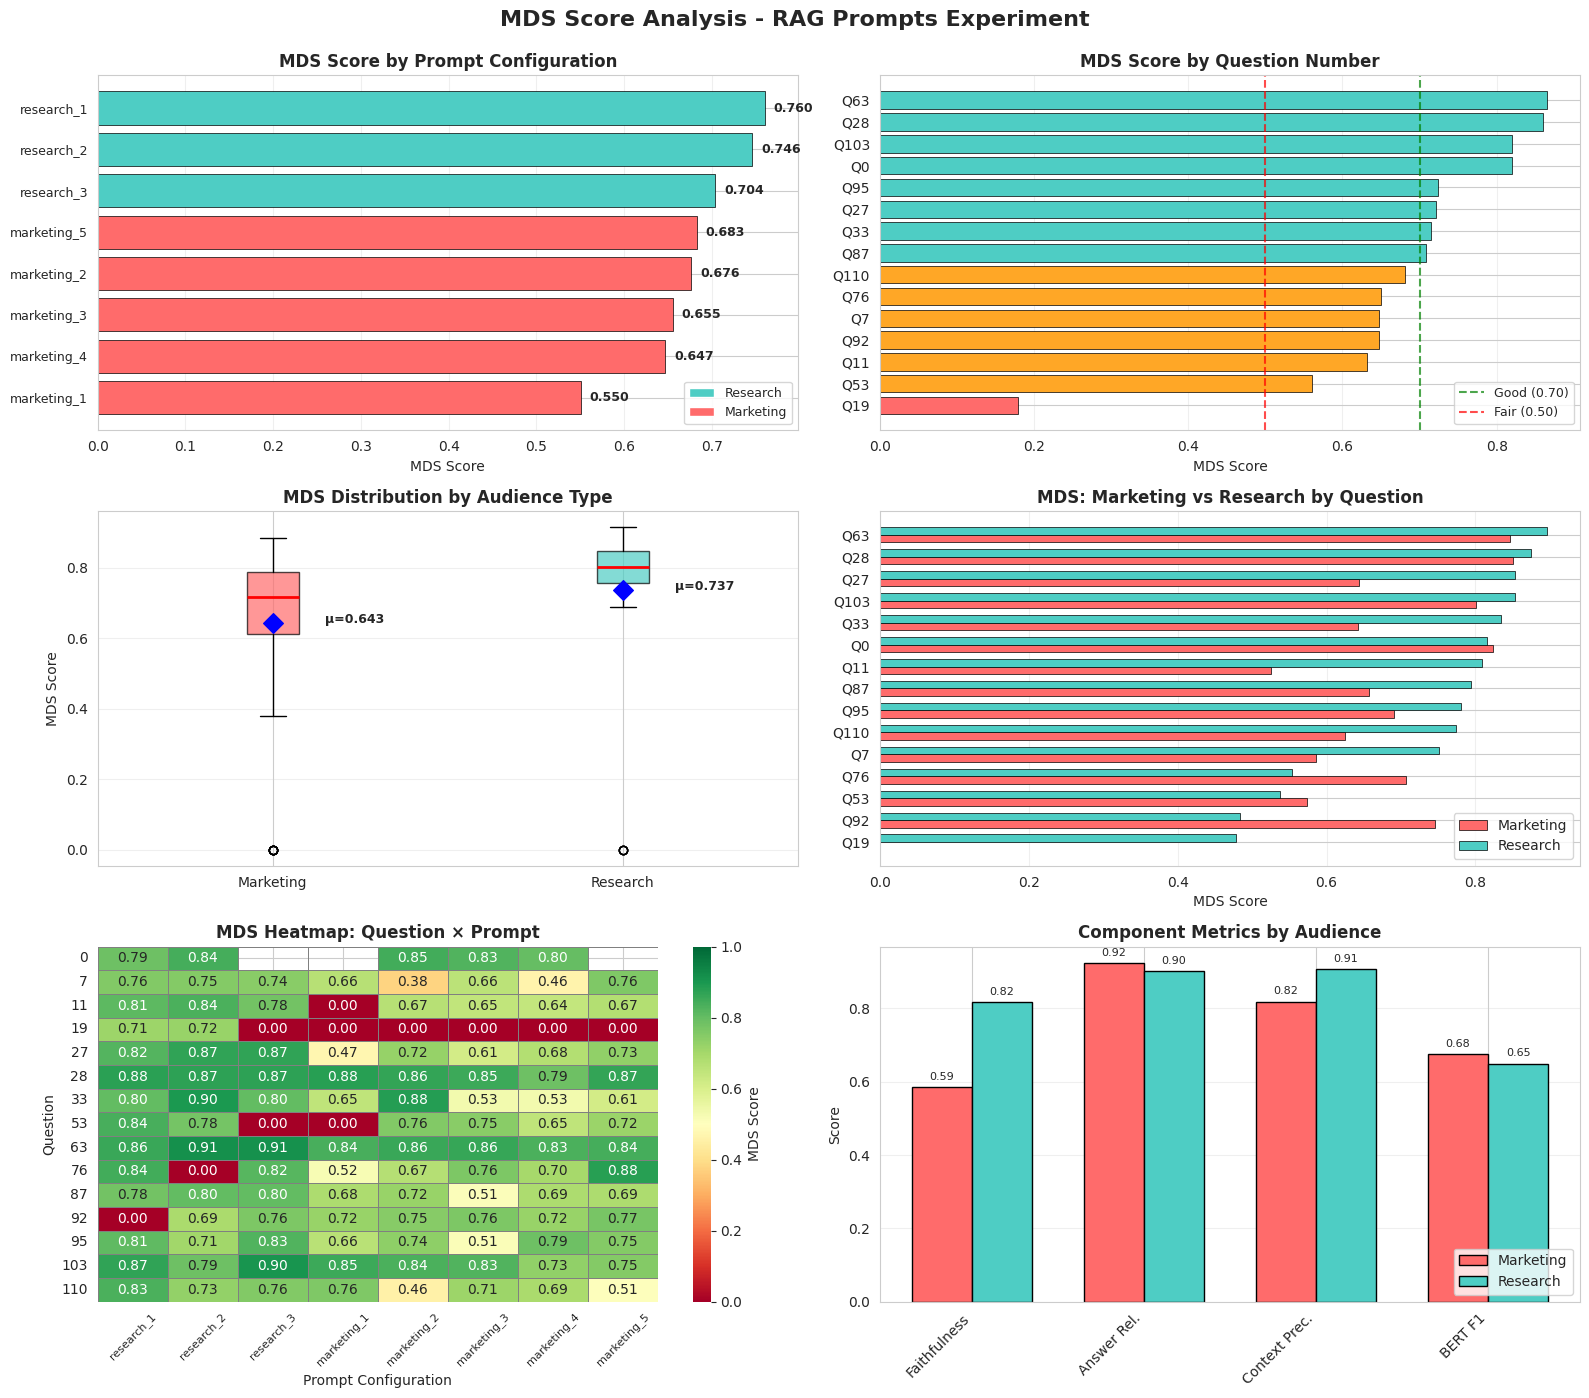

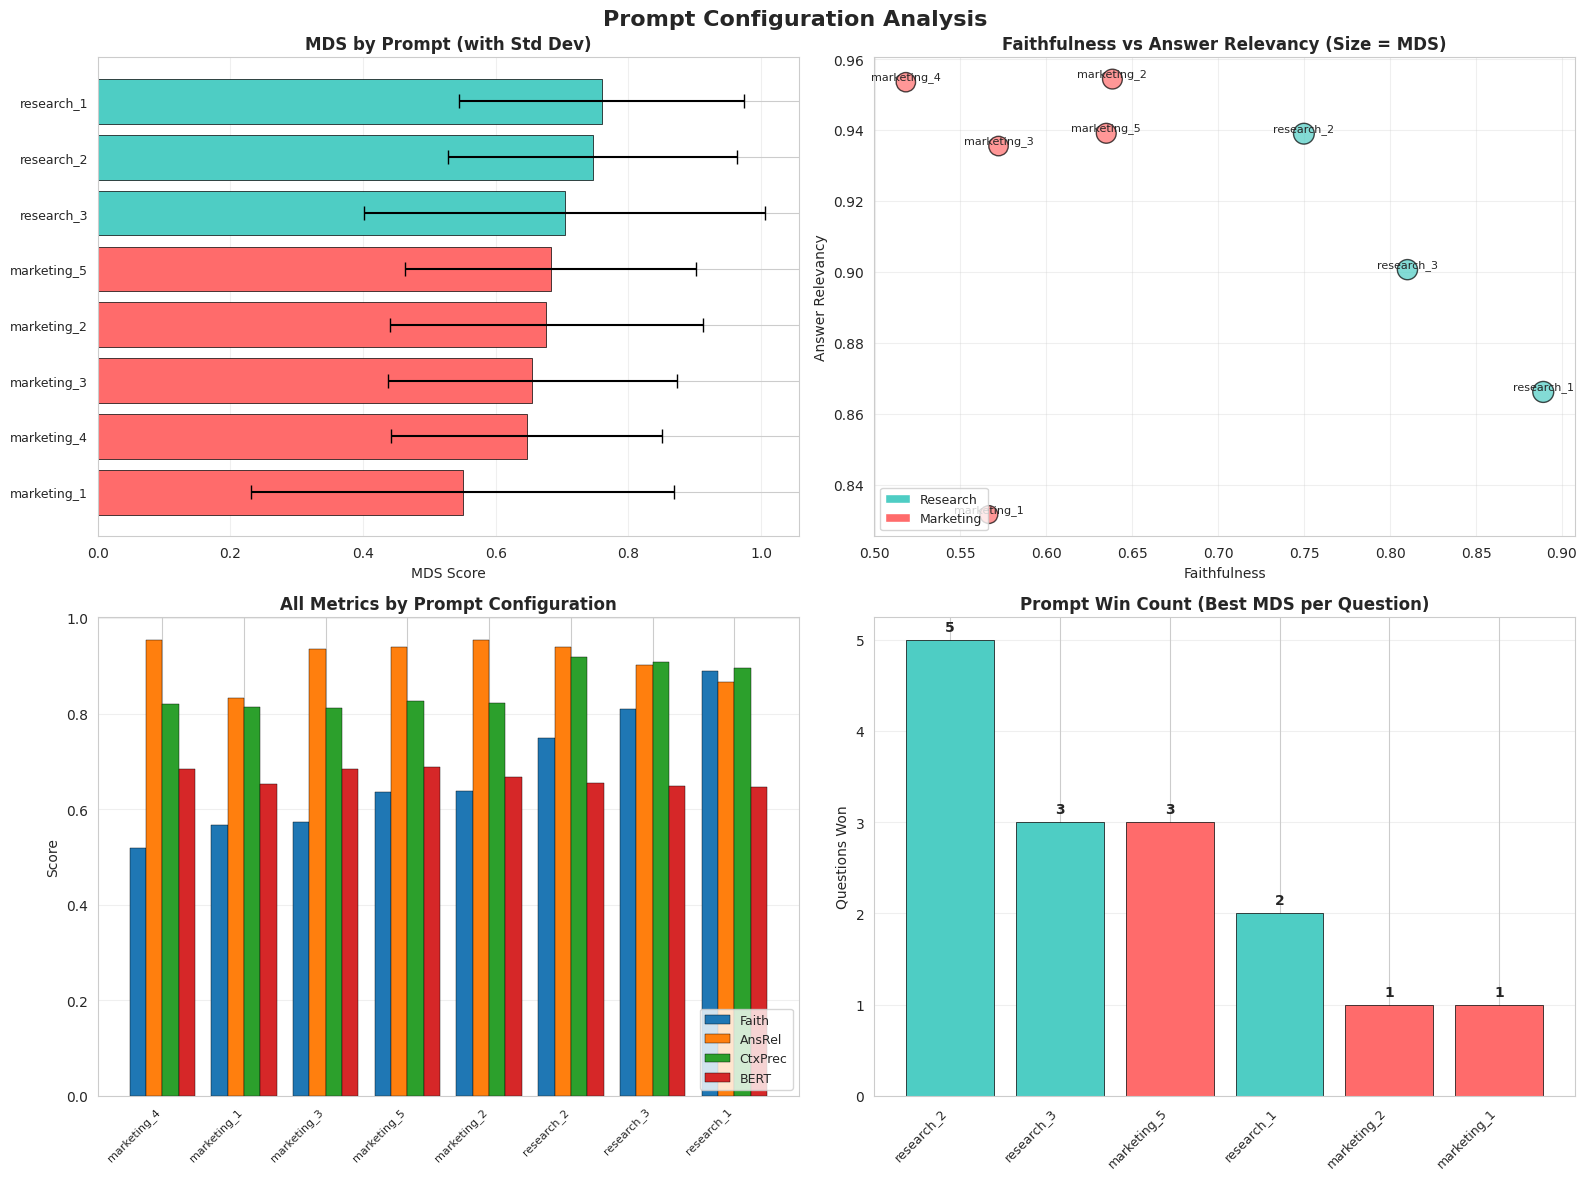

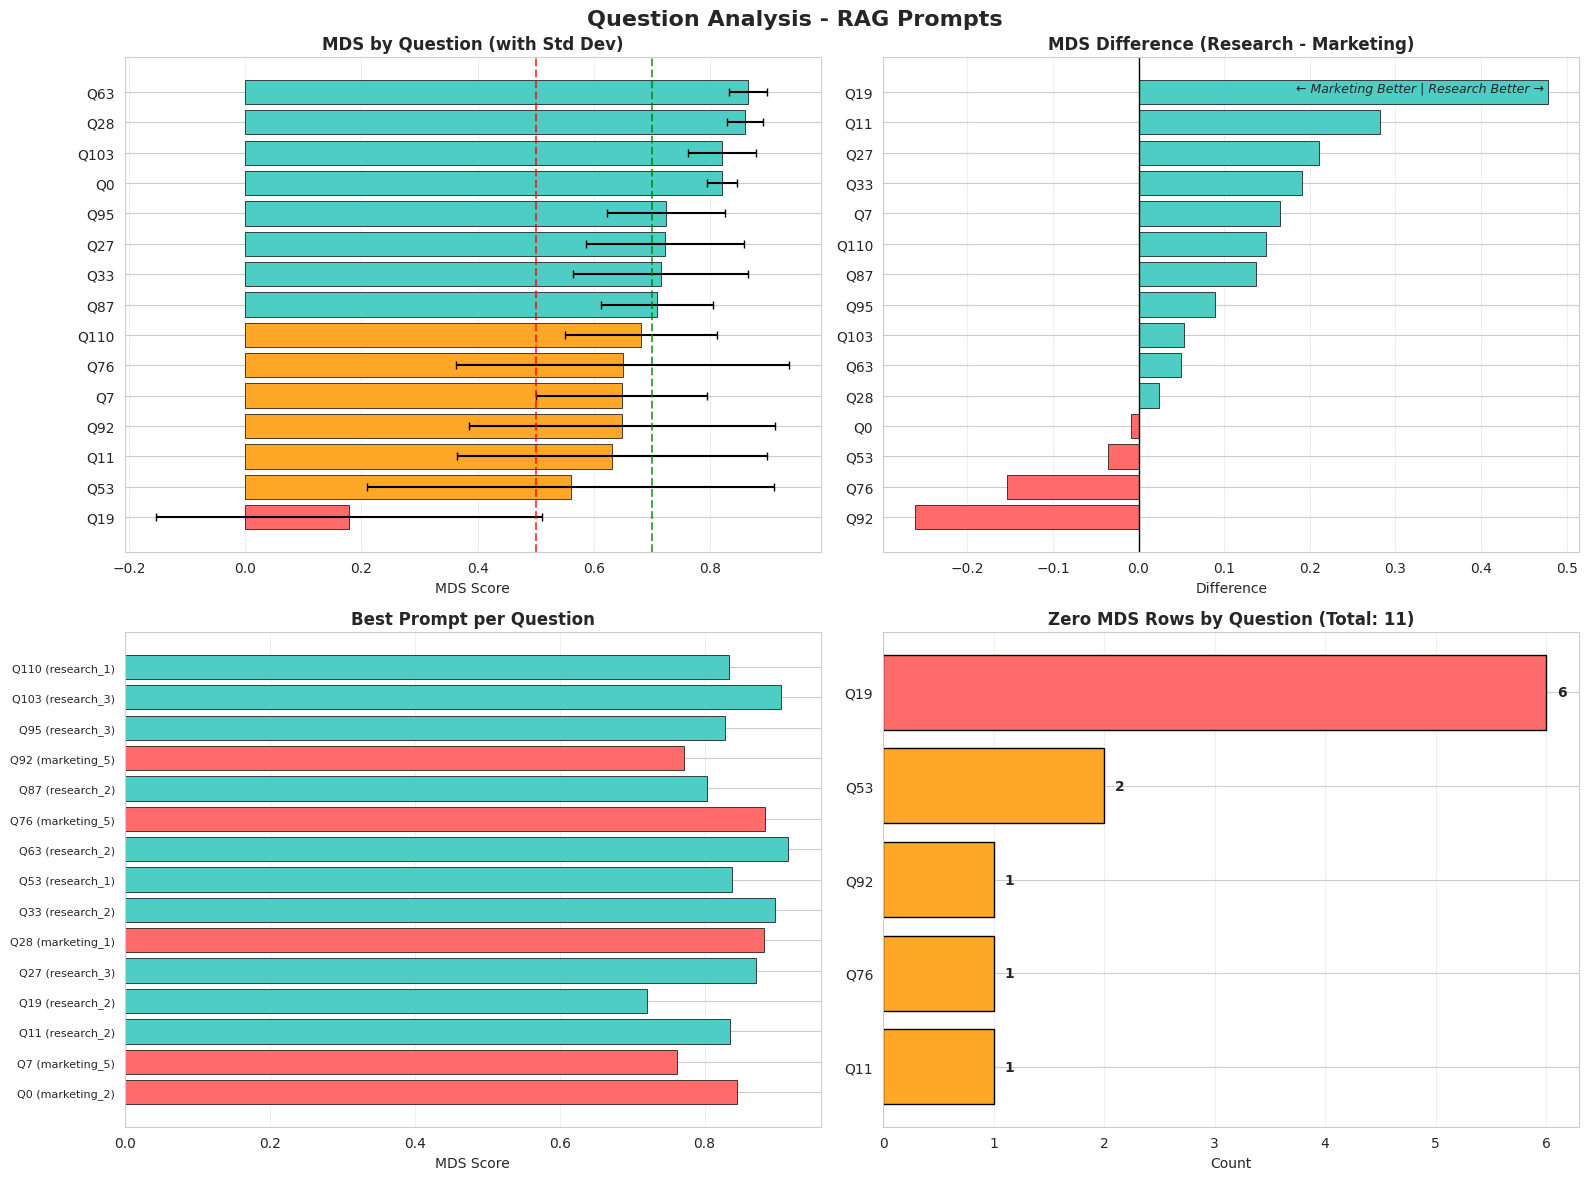

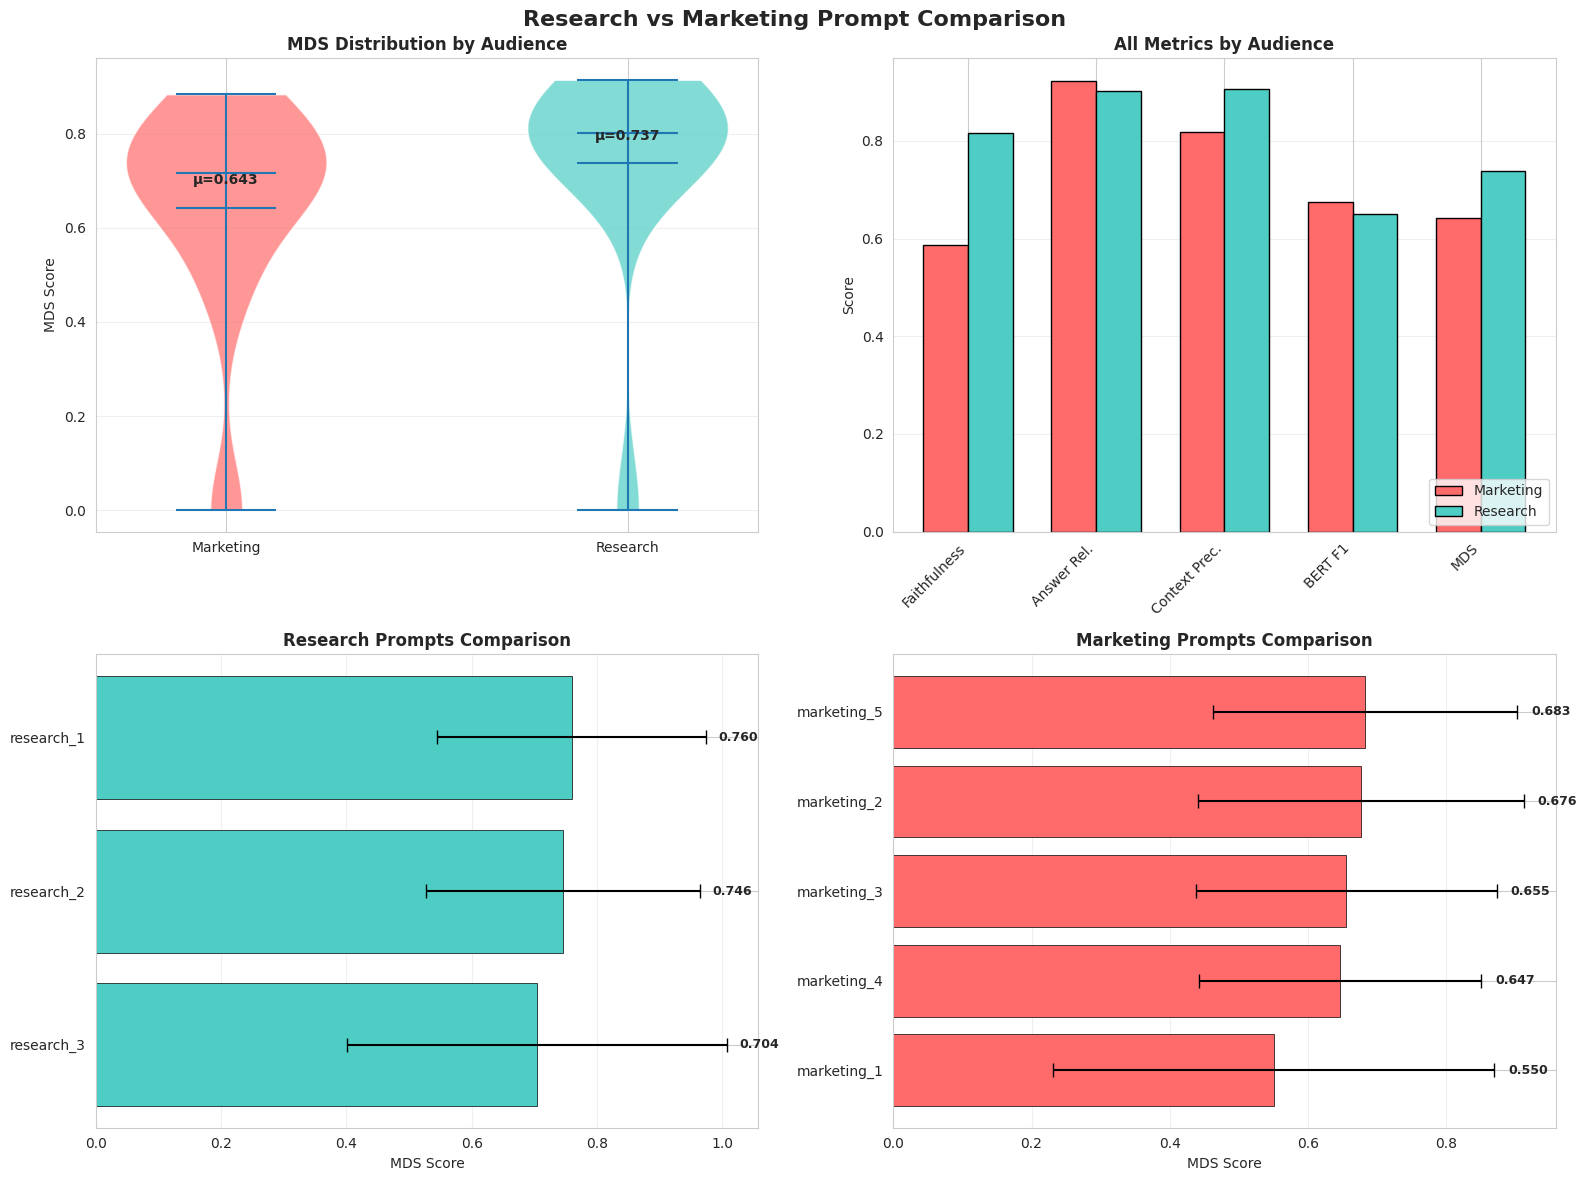

In [ ]:

"""
MDS Score Analysis - RAG Prompts Visualization Script
Generates comprehensive charts for RAG prompt experiment with MDS metric
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration
INPUT_CSV = f'{output_folder}metric_results_prompts_mds.csv'
OUTPUT_DIR = output_folder

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (16, 12)
plt.rcParams['font.size'] = 10


def load_data(csv_path):
    """Load the experiment data"""
    df = pd.read_csv(csv_path)
    print(f"✓ Loaded {len(df)} rows")
    print(f"✓ Prompt configurations: {df['config_name'].nunique()}")
    print(f"✓ Questions: {df['question_num'].nunique()}")
    return df


def create_overview_visualization(df, output_path):
    """Create 6-panel overview visualization"""

    fig, axes = plt.subplots(3, 2, figsize=(16, 14))
    fig.suptitle('MDS Score Analysis - RAG Prompts Experiment',
                 fontsize=16, fontweight='bold', y=0.995)

    # ========================================================================
    # 1. MDS by Prompt Configuration (horizontal bar)
    # ========================================================================
    ax = axes[0, 0]

    config_mds = df.groupby('config_name')['mds'].mean().sort_values(ascending=True)

    # Color by audience type
    colors = []
    for config in config_mds.index:
        audience = df[df['config_name']==config]['audience_type'].iloc[0]
        colors.append('#4ECDC4' if audience == 'research' else '#FF6B6B')

    ax.barh(range(len(config_mds)), config_mds.values, color=colors,
            edgecolor='black', linewidth=0.5)
    ax.set_yticks(range(len(config_mds)))
    ax.set_yticklabels(config_mds.index, fontsize=9)
    ax.set_title('MDS Score by Prompt Configuration', fontweight='bold', fontsize=12)
    ax.set_xlabel('MDS Score', fontsize=10)
    ax.grid(True, alpha=0.3, axis='x')

    for i, v in enumerate(config_mds.values):
        ax.text(v + 0.01, i, f'{v:.3f}', va='center', fontsize=9, fontweight='bold')

    # Add legend
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor='#4ECDC4', label='Research'),
                       Patch(facecolor='#FF6B6B', label='Marketing')]
    ax.legend(handles=legend_elements, loc='lower right', fontsize=9)

    # ========================================================================
    # 2. MDS by Question Number
    # ========================================================================
    ax = axes[0, 1]

    q_mds = df.groupby('question_num')['mds'].mean().sort_values(ascending=True)
    colors = ['#FF6B6B' if v < 0.50 else '#FFA726' if v < 0.70 else '#4ECDC4' for v in q_mds]

    ax.barh(range(len(q_mds)), q_mds.values, color=colors, edgecolor='black', linewidth=0.5)
    ax.set_yticks(range(len(q_mds)))
    ax.set_yticklabels([f'Q{q}' for q in q_mds.index])
    ax.set_title('MDS Score by Question Number', fontweight='bold', fontsize=12)
    ax.set_xlabel('MDS Score', fontsize=10)
    ax.grid(True, alpha=0.3, axis='x')

    ax.axvline(x=0.70, color='green', linestyle='--', alpha=0.7, linewidth=1.5, label='Good (0.70)')
    ax.axvline(x=0.50, color='red', linestyle='--', alpha=0.7, linewidth=1.5, label='Fair (0.50)')
    ax.legend(loc='lower right', fontsize=9)

    # ========================================================================
    # 3. MDS by Audience Type (box plot)
    # ========================================================================
    ax = axes[1, 0]

    box_data = [df[df['audience_type']=='marketing']['mds'].dropna(),
                df[df['audience_type']=='research']['mds'].dropna()]

    bp = ax.boxplot(box_data, tick_labels=['Marketing', 'Research'], patch_artist=True)

    colors_box = ['#FF6B6B', '#4ECDC4']
    for patch, color in zip(bp['boxes'], colors_box):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)

    for median in bp['medians']:
        median.set_color('red')
        median.set_linewidth(2)

    ax.set_title('MDS Distribution by Audience Type', fontweight='bold', fontsize=12)
    ax.set_ylabel('MDS Score', fontsize=10)
    ax.grid(True, alpha=0.3, axis='y')

    # Add mean markers
    means = df.groupby('audience_type')['mds'].mean()
    for i, (aud, mean_val) in enumerate(means.items()):
        ax.scatter(i+1, mean_val, color='blue', s=100, zorder=5, marker='D')
        ax.text(i+1.15, mean_val, f'μ={mean_val:.3f}', fontsize=9, fontweight='bold')

    # ========================================================================
    # 4. Marketing vs Research by Question
    # ========================================================================
    ax = axes[1, 1]

    pivot = df.pivot_table(values='mds', index='question_num', columns='audience_type', aggfunc='mean')
    pivot = pivot.sort_values('research', ascending=True)

    x = np.arange(len(pivot))
    width = 0.35

    ax.barh(x - width/2, pivot['marketing'], width, label='Marketing',
            color='#FF6B6B', edgecolor='black', linewidth=0.5)
    ax.barh(x + width/2, pivot['research'], width, label='Research',
            color='#4ECDC4', edgecolor='black', linewidth=0.5)

    ax.set_title('MDS: Marketing vs Research by Question', fontweight='bold', fontsize=12)
    ax.set_xlabel('MDS Score', fontsize=10)
    ax.set_yticks(x)
    ax.set_yticklabels([f'Q{q}' for q in pivot.index])
    ax.legend(loc='lower right', fontsize=10)
    ax.grid(True, alpha=0.3, axis='x')

    # ========================================================================
    # 5. Heatmap: Prompt × Question
    # ========================================================================
    ax = axes[2, 0]

    heatmap_data = df.pivot_table(values='mds', index='question_num',
                                   columns='config_name', aggfunc='mean')

    # Reorder columns: research first, then marketing
    research_cols = [c for c in heatmap_data.columns if 'research' in c]
    marketing_cols = [c for c in heatmap_data.columns if 'marketing' in c]
    heatmap_data = heatmap_data[research_cols + marketing_cols]

    sns.heatmap(heatmap_data, annot=True, fmt='.2f', cmap='RdYlGn', ax=ax,
                cbar_kws={'label': 'MDS Score'}, linewidths=0.5, linecolor='gray',
                vmin=0, vmax=1)

    ax.set_title('MDS Heatmap: Question × Prompt', fontweight='bold', fontsize=12)
    ax.set_xlabel('Prompt Configuration', fontsize=10)
    ax.set_ylabel('Question', fontsize=10)
    ax.tick_params(axis='x', rotation=45, labelsize=8)

    # ========================================================================
    # 6. Component Metrics Comparison
    # ========================================================================
    ax = axes[2, 1]

    metrics = ['ragas_score_faithfulness', 'ragas_score_answer_relevancy',
               'ragas_score_context_precision', 'bert_score_f1']
    metric_names = ['Faithfulness', 'Answer Rel.', 'Context Prec.', 'BERT F1']

    research_scores = df[df['audience_type']=='research'][metrics].mean()
    marketing_scores = df[df['audience_type']=='marketing'][metrics].mean()

    x = np.arange(len(metrics))
    width = 0.35

    ax.bar(x - width/2, marketing_scores, width, label='Marketing',
           color='#FF6B6B', edgecolor='black')
    ax.bar(x + width/2, research_scores, width, label='Research',
           color='#4ECDC4', edgecolor='black')

    ax.set_xticks(x)
    ax.set_xticklabels(metric_names, rotation=45, ha='right')
    ax.set_title('Component Metrics by Audience', fontweight='bold', fontsize=12)
    ax.set_ylabel('Score', fontsize=10)
    ax.legend(loc='lower right', fontsize=10)
    ax.grid(True, alpha=0.3, axis='y')

    # Add value labels
    for i, (m, r) in enumerate(zip(marketing_scores, research_scores)):
        ax.text(i - width/2, m + 0.02, f'{m:.2f}', ha='center', fontsize=8)
        ax.text(i + width/2, r + 0.02, f'{r:.2f}', ha='center', fontsize=8)

    plt.tight_layout()
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    print(f"✓ Saved: {output_path}")


def create_prompt_analysis_visualization(df, output_path):
    """Create prompt-focused visualization"""

    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('Prompt Configuration Analysis', fontsize=16, fontweight='bold')

    # ========================================================================
    # 1. Prompt Performance with Error Bars
    # ========================================================================
    ax = axes[0, 0]

    config_stats = df.groupby('config_name').agg({
        'mds': ['mean', 'std'],
        'audience_type': 'first'
    })
    config_stats.columns = ['mean', 'std', 'audience']
    config_stats = config_stats.sort_values('mean', ascending=True)

    colors = ['#4ECDC4' if a == 'research' else '#FF6B6B' for a in config_stats['audience']]

    ax.barh(range(len(config_stats)), config_stats['mean'], xerr=config_stats['std'],
            color=colors, edgecolor='black', linewidth=0.5, capsize=5)
    ax.set_yticks(range(len(config_stats)))
    ax.set_yticklabels(config_stats.index, fontsize=9)
    ax.set_title('MDS by Prompt (with Std Dev)', fontweight='bold', fontsize=12)
    ax.set_xlabel('MDS Score', fontsize=10)
    ax.grid(True, alpha=0.3, axis='x')

    # ========================================================================
    # 2. Faithfulness vs Answer Relevancy Trade-off
    # ========================================================================
    ax = axes[0, 1]

    config_metrics = df.groupby('config_name').agg({
        'ragas_score_faithfulness': 'mean',
        'ragas_score_answer_relevancy': 'mean',
        'mds': 'mean',
        'audience_type': 'first'
    })

    colors = ['#4ECDC4' if a == 'research' else '#FF6B6B'
              for a in config_metrics['audience_type']]

    scatter = ax.scatter(config_metrics['ragas_score_faithfulness'],
                         config_metrics['ragas_score_answer_relevancy'],
                         c=colors, s=config_metrics['mds']*300,
                         edgecolor='black', linewidth=1, alpha=0.7)

    for idx, row in config_metrics.iterrows():
        ax.annotate(idx, (row['ragas_score_faithfulness'], row['ragas_score_answer_relevancy']),
                    fontsize=8, ha='center', va='bottom')

    ax.set_xlabel('Faithfulness', fontsize=10)
    ax.set_ylabel('Answer Relevancy', fontsize=10)
    ax.set_title('Faithfulness vs Answer Relevancy (Size = MDS)', fontweight='bold', fontsize=12)
    ax.grid(True, alpha=0.3)

    # Add legend
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor='#4ECDC4', label='Research'),
                       Patch(facecolor='#FF6B6B', label='Marketing')]
    ax.legend(handles=legend_elements, loc='lower left', fontsize=9)

    # ========================================================================
    # 3. Component Metrics by Prompt
    # ========================================================================
    ax = axes[1, 0]

    metrics = ['ragas_score_faithfulness', 'ragas_score_answer_relevancy',
               'ragas_score_context_precision', 'bert_score_f1']
    metric_names = ['Faith', 'AnsRel', 'CtxPrec', 'BERT']

    config_all_metrics = df.groupby('config_name')[metrics].mean()
    config_all_metrics = config_all_metrics.sort_values('ragas_score_faithfulness', ascending=True)

    x = np.arange(len(config_all_metrics))
    width = 0.2

    for i, (metric, name) in enumerate(zip(metrics, metric_names)):
        ax.bar(x + i*width, config_all_metrics[metric], width, label=name,
               edgecolor='black', linewidth=0.3)

    ax.set_xticks(x + width * 1.5)
    ax.set_xticklabels(config_all_metrics.index, rotation=45, ha='right', fontsize=8)
    ax.set_title('All Metrics by Prompt Configuration', fontweight='bold', fontsize=12)
    ax.set_ylabel('Score', fontsize=10)
    ax.legend(loc='lower right', fontsize=9)
    ax.grid(True, alpha=0.3, axis='y')

    # ========================================================================
    # 4. Prompt Win Count
    # ========================================================================
    ax = axes[1, 1]

    from collections import Counter

    best_prompts = []
    for q_num in df['question_num'].unique():
        q_data = df[df['question_num'] == q_num].groupby('config_name')['mds'].mean()
        best_prompts.append(q_data.idxmax())

    prompt_wins = Counter(best_prompts)
    prompts = list(prompt_wins.keys())
    counts = list(prompt_wins.values())

    # Sort by count
    sorted_data = sorted(zip(counts, prompts), reverse=True)
    counts, prompts = zip(*sorted_data)

    # Color by audience
    colors = ['#4ECDC4' if 'research' in p else '#FF6B6B' for p in prompts]

    ax.bar(range(len(prompts)), counts, color=colors, edgecolor='black', linewidth=0.5)
    ax.set_xticks(range(len(prompts)))
    ax.set_xticklabels(prompts, rotation=45, ha='right', fontsize=9)
    ax.set_title('Prompt Win Count (Best MDS per Question)', fontweight='bold', fontsize=12)
    ax.set_ylabel('Questions Won', fontsize=10)
    ax.grid(True, alpha=0.3, axis='y')

    for i, v in enumerate(counts):
        ax.text(i, v + 0.1, str(v), ha='center', fontweight='bold', fontsize=10)

    plt.tight_layout()
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    print(f"✓ Saved: {output_path}")


def create_question_analysis_visualization(df, output_path):
    """Create question-focused visualization"""

    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('Question Analysis - RAG Prompts', fontsize=16, fontweight='bold')

    # ========================================================================
    # 1. Question Performance Ranking
    # ========================================================================
    ax = axes[0, 0]

    q_stats = df.groupby('question_num')['mds'].agg(['mean', 'std']).sort_values('mean', ascending=True)

    colors = ['#FF6B6B' if m < 0.50 else '#FFA726' if m < 0.70 else '#4ECDC4' for m in q_stats['mean']]

    ax.barh(range(len(q_stats)), q_stats['mean'], xerr=q_stats['std'],
            color=colors, edgecolor='black', linewidth=0.5, capsize=3)
    ax.set_yticks(range(len(q_stats)))
    ax.set_yticklabels([f'Q{q}' for q in q_stats.index])
    ax.set_title('MDS by Question (with Std Dev)', fontweight='bold', fontsize=12)
    ax.set_xlabel('MDS Score', fontsize=10)
    ax.grid(True, alpha=0.3, axis='x')

    ax.axvline(x=0.70, color='green', linestyle='--', alpha=0.7, linewidth=1.5)
    ax.axvline(x=0.50, color='red', linestyle='--', alpha=0.7, linewidth=1.5)

    # ========================================================================
    # 2. Research - Marketing Difference by Question
    # ========================================================================
    ax = axes[0, 1]

    pivot = df.pivot_table(values='mds', index='question_num', columns='audience_type', aggfunc='mean')
    pivot['diff'] = pivot['research'] - pivot['marketing']
    pivot = pivot.sort_values('diff', ascending=True)

    colors = ['#FF6B6B' if d < 0 else '#4ECDC4' for d in pivot['diff']]

    ax.barh(range(len(pivot)), pivot['diff'], color=colors, edgecolor='black', linewidth=0.5)
    ax.set_yticks(range(len(pivot)))
    ax.set_yticklabels([f'Q{q}' for q in pivot.index])
    ax.set_title('MDS Difference (Research - Marketing)', fontweight='bold', fontsize=12)
    ax.set_xlabel('Difference', fontsize=10)
    ax.axvline(x=0, color='black', linestyle='-', linewidth=1)
    ax.grid(True, alpha=0.3, axis='x')

    ax.text(0.95, 0.95, '← Marketing Better | Research Better →',
            transform=ax.transAxes, fontsize=9, ha='right', va='top', style='italic')

    # ========================================================================
    # 3. Best Prompt per Question
    # ========================================================================
    ax = axes[1, 0]

    best_data = []
    for q_num in sorted(df['question_num'].unique()):
        q_data = df[df['question_num'] == q_num].groupby('config_name')['mds'].mean()
        best_prompt = q_data.idxmax()
        best_score = q_data.max()
        best_data.append({'question': q_num, 'prompt': best_prompt, 'mds': best_score})

    best_df = pd.DataFrame(best_data)

    colors = ['#4ECDC4' if 'research' in p else '#FF6B6B' for p in best_df['prompt']]

    ax.barh(range(len(best_df)), best_df['mds'], color=colors, edgecolor='black', linewidth=0.5)
    ax.set_yticks(range(len(best_df)))
    ax.set_yticklabels([f'Q{q} ({p})' for q, p in zip(best_df['question'], best_df['prompt'])], fontsize=8)
    ax.set_title('Best Prompt per Question', fontweight='bold', fontsize=12)
    ax.set_xlabel('MDS Score', fontsize=10)
    ax.grid(True, alpha=0.3, axis='x')

    # ========================================================================
    # 4. Zero MDS Analysis
    # ========================================================================
    ax = axes[1, 1]

    zero_mds = df[df['mds'] < 0.001]

    if len(zero_mds) > 0:
        # By question
        zero_by_q = zero_mds.groupby('question_num').size().sort_values(ascending=True)

        colors = ['#FFA726' if v <= 2 else '#FF6B6B' for v in zero_by_q]

        ax.barh(range(len(zero_by_q)), zero_by_q.values, color=colors, edgecolor='black')
        ax.set_yticks(range(len(zero_by_q)))
        ax.set_yticklabels([f'Q{q}' for q in zero_by_q.index])
        ax.set_title(f'Zero MDS Rows by Question (Total: {len(zero_mds)})',
                     fontweight='bold', fontsize=12)
        ax.set_xlabel('Count', fontsize=10)
        ax.grid(True, alpha=0.3, axis='x')

        for i, v in enumerate(zero_by_q.values):
            ax.text(v + 0.1, i, str(v), va='center', fontweight='bold')

    plt.tight_layout()
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    print(f"✓ Saved: {output_path}")


def create_audience_comparison_visualization(df, output_path):
    """Create audience comparison visualization"""

    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('Research vs Marketing Prompt Comparison', fontsize=16, fontweight='bold')

    # ========================================================================
    # 1. Violin Plot
    # ========================================================================
    ax = axes[0, 0]

    parts = ax.violinplot([df[df['audience_type']=='marketing']['mds'].dropna(),
                           df[df['audience_type']=='research']['mds'].dropna()],
                          positions=[1, 2], showmeans=True, showmedians=True)

    colors = ['#FF6B6B', '#4ECDC4']
    for i, pc in enumerate(parts['bodies']):
        pc.set_facecolor(colors[i])
        pc.set_alpha(0.7)

    ax.set_xticks([1, 2])
    ax.set_xticklabels(['Marketing', 'Research'])
    ax.set_title('MDS Distribution by Audience', fontweight='bold', fontsize=12)
    ax.set_ylabel('MDS Score', fontsize=10)
    ax.grid(True, alpha=0.3, axis='y')

    # Add stats
    mkt_mean = df[df['audience_type']=='marketing']['mds'].mean()
    res_mean = df[df['audience_type']=='research']['mds'].mean()
    ax.text(1, mkt_mean + 0.05, f'μ={mkt_mean:.3f}', ha='center', fontsize=10, fontweight='bold')
    ax.text(2, res_mean + 0.05, f'μ={res_mean:.3f}', ha='center', fontsize=10, fontweight='bold')

    # ========================================================================
    # 2. Metric Comparison Radar-style (as bar)
    # ========================================================================
    ax = axes[0, 1]

    metrics = ['ragas_score_faithfulness', 'ragas_score_answer_relevancy',
               'ragas_score_context_precision', 'bert_score_f1', 'mds']
    metric_names = ['Faithfulness', 'Answer Rel.', 'Context Prec.', 'BERT F1', 'MDS']

    mkt_scores = df[df['audience_type']=='marketing'][metrics].mean()
    res_scores = df[df['audience_type']=='research'][metrics].mean()

    x = np.arange(len(metrics))
    width = 0.35

    ax.bar(x - width/2, mkt_scores, width, label='Marketing', color='#FF6B6B', edgecolor='black')
    ax.bar(x + width/2, res_scores, width, label='Research', color='#4ECDC4', edgecolor='black')

    ax.set_xticks(x)
    ax.set_xticklabels(metric_names, rotation=45, ha='right')
    ax.set_title('All Metrics by Audience', fontweight='bold', fontsize=12)
    ax.set_ylabel('Score', fontsize=10)
    ax.legend(loc='lower right', fontsize=10)
    ax.grid(True, alpha=0.3, axis='y')

    # ========================================================================
    # 3. Research Prompts Comparison
    # ========================================================================
    ax = axes[1, 0]

    research_df = df[df['audience_type'] == 'research']
    research_stats = research_df.groupby('config_name')['mds'].agg(['mean', 'std'])
    research_stats = research_stats.sort_values('mean', ascending=True)

    ax.barh(range(len(research_stats)), research_stats['mean'], xerr=research_stats['std'],
            color='#4ECDC4', edgecolor='black', linewidth=0.5, capsize=5)
    ax.set_yticks(range(len(research_stats)))
    ax.set_yticklabels(research_stats.index)
    ax.set_title('Research Prompts Comparison', fontweight='bold', fontsize=12)
    ax.set_xlabel('MDS Score', fontsize=10)
    ax.grid(True, alpha=0.3, axis='x')

    for i, (idx, row) in enumerate(research_stats.iterrows()):
        ax.text(row['mean'] + row['std'] + 0.02, i, f'{row["mean"]:.3f}',
                va='center', fontsize=9, fontweight='bold')

    # ========================================================================
    # 4. Marketing Prompts Comparison
    # ========================================================================
    ax = axes[1, 1]

    marketing_df = df[df['audience_type'] == 'marketing']
    marketing_stats = marketing_df.groupby('config_name')['mds'].agg(['mean', 'std'])
    marketing_stats = marketing_stats.sort_values('mean', ascending=True)

    ax.barh(range(len(marketing_stats)), marketing_stats['mean'], xerr=marketing_stats['std'],
            color='#FF6B6B', edgecolor='black', linewidth=0.5, capsize=5)
    ax.set_yticks(range(len(marketing_stats)))
    ax.set_yticklabels(marketing_stats.index)
    ax.set_title('Marketing Prompts Comparison', fontweight='bold', fontsize=12)
    ax.set_xlabel('MDS Score', fontsize=10)
    ax.grid(True, alpha=0.3, axis='x')

    for i, (idx, row) in enumerate(marketing_stats.iterrows()):
        ax.text(row['mean'] + row['std'] + 0.02, i, f'{row["mean"]:.3f}',
                va='center', fontsize=9, fontweight='bold')

    plt.tight_layout()
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    print(f"✓ Saved: {output_path}")


def print_summary(df):
    """Print key findings summary"""

    print("\n" + "=" * 80)
    print("📊 RAG PROMPTS MDS ANALYSIS SUMMARY")
    print("=" * 80)

    # Overall stats
    print(f"\n📈 Overall MDS: {df['mds'].mean():.4f} (±{df['mds'].std():.4f})")
    print(f"   Median: {df['mds'].median():.4f}")

    # Best prompt overall
    best_prompt = df.groupby('config_name')['mds'].mean().idxmax()
    best_score = df.groupby('config_name')['mds'].mean().max()
    print(f"\n🏆 Best Prompt: {best_prompt}")
    print(f"   MDS: {best_score:.4f}")

    # Best by audience
    for audience in ['research', 'marketing']:
        aud_data = df[df['audience_type'] == audience]
        best = aud_data.groupby('config_name')['mds'].mean().idxmax()
        score = aud_data.groupby('config_name')['mds'].mean().max()
        print(f"\n   Best {audience.title()}: {best} (MDS: {score:.4f})")

    # Audience comparison
    mkt_mean = df[df['audience_type']=='marketing']['mds'].mean()
    res_mean = df[df['audience_type']=='research']['mds'].mean()
    print(f"\n👥 Audience Comparison:")
    print(f"   Marketing: {mkt_mean:.4f}")
    print(f"   Research:  {res_mean:.4f}")
    print(f"   Winner:    {'Research' if res_mean > mkt_mean else 'Marketing'} (+{abs(res_mean-mkt_mean):.4f})")

    # Problem questions
    q_mds = df.groupby('question_num')['mds'].mean()
    problem_qs = q_mds[q_mds < 0.50].index.tolist()
    print(f"\n Problem Questions (MDS < 0.50): {problem_qs}")

    # Zero MDS count
    zero_count = (df['mds'] < 0.001).sum()
    print(f"\n Rows with Zero MDS: {zero_count} ({zero_count/len(df)*100:.1f}%)")




print("\n" + "=" * 80)
print("MDS SCORE ANALYSIS - RAG PROMPTS VISUALIZATION")
print("=" * 80)

# Load data
df = load_data(INPUT_CSV)

# Print summary
print_summary(df)

# Generate visualizations
print("\n" + "=" * 80)
print("GENERATING VISUALIZATIONS")
print("=" * 80)

create_overview_visualization(df, OUTPUT_DIR + 'prompts_mds_overview.png')
create_prompt_analysis_visualization(df, OUTPUT_DIR + 'prompts_mds_prompt_analysis.png')
create_question_analysis_visualization(df, OUTPUT_DIR + 'prompts_mds_question_analysis.png')
create_audience_comparison_visualization(df, OUTPUT_DIR + 'prompts_mds_audience_comparison.png')

print("\n" + "=" * 80)
print("✓ COMPLETE!")
print("=" * 80)
print(f"\nGenerated files:")
print(f"  1. {OUTPUT_DIR}prompts_mds_overview.png")
print(f"  2. {OUTPUT_DIR}prompts_mds_prompt_analysis.png")
print(f"  3. {OUTPUT_DIR}prompts_mds_question_analysis.png")
print(f"  4. {OUTPUT_DIR}prompts_mds_audience_comparison.png")




### Full Validation Question analysis

Full Validation Set - MDS Analysis Report (78 Questions)

## Overview

| Metric | Value |
|--------|-------|
| Total Rows | 156 |
| Total Questions | 78 |
| Valid MDS Rows | 138 (88.5%) |
| **Mean MDS** | **0.6515** |
| **Median MDS** | **0.7645** |
| Zero MDS Rows | 20 |
| NaN MDS Rows | 18 |

---

Audience Comparison

| Metric | Research | Marketing | Winner |
|--------|----------|-----------|--------|
| **Mean MDS** | 0.6110 | **0.6908** | **Marketing** |
| Median MDS | 0.7630 | 0.7684 | Marketing |
| Std MDS | 0.3338 | 0.2283 | Marketing (lower variance) |
| **Faithfulness** | **0.7513** | 0.6436 | **Research**  |
| Answer Relevancy | 0.8021 | **0.9439** | **Marketing**  |
| Context Precision | 0.9107 | 0.8265 | Research |
| Context Recall | 0.7640 | 0.8352 | Marketing |
| Zero MDS Rows | 15 | 5 | Marketing (fewer failures) |
| NaN MDS Rows | 10 | 8 | Marketing (fewer NaN) |

 Winner: Marketing (+0.0798 MDS)

**Key Insight:** This is **OPPOSITE** to the 15-question test where Research won!

---

Zero MDS Root Cause Analysis

Total: 20 rows with MDS ≈ 0

| Root Cause | Research | Marketing | Total |
|------------|----------|-----------|-------|
| Zero Answer Relevancy | **11** | 0 | 11 (55%) |
| Zero Faithfulness | 2 | 4 | 6 (30%) |
| Zero Context Precision | 2 | 1 | 3 (15%) |
| **Total** | **15** | **5** | **20** |

Critical Issue: Research has 11 questions with Zero Answer Relevancy

| Question | Faithfulness | Answer Rel. | Issue |
|----------|--------------|-------------|-------|
| Q8 | 0.78 | **0.00** | Zero AnsRel |
| Q16 | 1.00 | **0.00** | Zero AnsRel |
| Q30 | 1.00 | **0.00** | Zero AnsRel |
| Q41 | 0.38 | **0.00** | Zero AnsRel |
| Q50 | 1.00 | **0.00** | Zero AnsRel |
| Q51 | 0.89 | **0.00** | Zero AnsRel |
| Q52 | 0.50 | **0.00** | Zero AnsRel |
| Q60 | 0.50 | **0.00** | Zero AnsRel |
| Q85 | 0.67 | **0.00** | Zero AnsRel |
| Q101 | 1.00 | **0.00** | Zero AnsRel |
| Q107 | 0.71 | **0.00** | Zero AnsRel |

**Root Cause:** Research prompt generates responses that RAGAS Answer Relevancy scorer rates as 0. The prompt may be:
- Too technical/structured
- Not directly addressing the question
- Generating preamble before the answer

---

Question Performance Distribution

| Category | Count | Percentage |
|----------|-------|------------|
| Excellent (≥0.80) | 20 | 26% |
|  Good (0.70-0.80) | 26 | 33% |
| Fair (0.50-0.70) | 11 | 14% |
| Needs Work (0.30-0.50) | 10 | 13% |
| Problem (<0.30) | 6 | 8% |
| No MDS (NaN) | 5 | 6% |

**59% of questions perform well (Good or Excellent)**

---

Top 10 Questions

| Rank | Q# | MDS | Faithfulness | Answer Rel. |
|------|-----|-----|--------------|-------------|
| 1 | Q63 | 0.9083 | 1.000 | 0.959 |
| 2 | Q28 | 0.8933 | 1.000 | 0.937 |
| 3 | Q7 | 0.8924 | 1.000 | 0.921 |
| 4 | Q105 | 0.8817 | 0.900 | 0.906 |
| 5 | Q61 | 0.8768 | 0.917 | 0.949 |
| 6 | Q86 | 0.8717 | 1.000 | 0.966 |
| 7 | Q33 | 0.8701 | 0.929 | 0.974 |
| 8 | Q48 | 0.8597 | 0.875 | 0.979 |
| 9 | Q80 | 0.8548 | 1.000 | 0.906 |
| 10 | Q102 | 0.8514 | 0.929 | 0.880 |

---

Bottom 10 Questions (Excluding NaN)

| Rank | Q# | MDS | Faithfulness | Answer Rel. | Issue |
|------|-----|-----|--------------|-------------|-------|
| 1 | Q94 | 0.0000 | 0.000 | 0.960 | Zero Faith |
| 2 | Q73 | 0.0000 | 0.250 | 0.864 | Zero Faith |
| 3 | Q9 | 0.0000 | 0.800 | 1.000 | Zero CtxPrec |
| 4 | Q13 | 0.0000 | 0.000 | 0.952 | Zero Faith |
| 5 | Q8 | 0.2288 | 0.826 | 0.472 | Low AnsRel |
| 6 | Q30 | 0.2419 | 0.667 | 0.442 | Low AnsRel |
| 7 | Q107 | 0.3058 | 0.557 | 0.496 | Low both |
| 8 | Q16 | 0.3130 | 0.667 | 0.495 | Low AnsRel |
| 9 | Q41 | 0.3145 | 0.388 | 0.459 | Low both |
| 10 | Q52 | 0.3910 | 0.650 | 0.483 | Low AnsRel |

---

Research vs Marketing by Question

Research Wins (19 questions)

| Q# | Research | Marketing | Diff |
|----|----------|-----------|------|
| Q22 | 0.8014 | 0.0000 | +0.8014 |
| Q12 | 0.8227 | 0.4243 | +0.3984 |
| Q74 | 0.8390 | 0.5332 | +0.3058 |
| Q95 | 0.8838 | 0.6195 | +0.2643 |
| Q24 | 0.7627 | 0.5021 | +0.2605 |

Marketing Wins (20 questions)

| Q# | Research | Marketing | Diff |
|----|----------|-----------|------|
| Q85 | 0.0000 | 0.8472 | -0.8472 |
| Q60 | 0.0000 | 0.8469 | -0.8469 |
| Q50 | 0.0000 | 0.8416 | -0.8416 |
| Q51 | 0.0000 | 0.8296 | -0.8296 |
| Q101 | 0.0000 | 0.7990 | -0.7990 |

Similar Performance: 26 questions

---

 Key Insights

 Marketing Outperforms Research on Full Set
- Marketing MDS: 0.6908 vs Research: 0.6110
- **This is OPPOSITE to the 15-question test!**
- The 15-question sample was not representative

 Research Has High Zero Answer Relevancy Rate
- 11 out of 15 zero MDS rows in Research are due to AnsRel=0
- The research prompt may be too structured/technical
- RAGAS Answer Relevancy scorer may not recognize the format

Trade-off: Faithfulness vs Answer Relevancy
- Research: Higher Faithfulness (0.7513) but lower AnsRel (0.8021)
- Marketing: Higher AnsRel (0.9439) but lower Faithfulness (0.6436)
- **Marketing wins because AnsRel has bigger impact on MDS**

Context Precision NaN Affects Both
- 18 rows have NaN context_precision
- Questions most affected: Q0, Q87, Q89, Q91, Q92

 59% of Questions Perform Well
- 46 out of 78 questions have MDS ≥ 0.70
- 16 questions need improvement (MDS < 0.50)

---

 Recommendations

| Priority | Action |
|----------|--------|
| **1. Fix Research Prompt** | The research prompt generates responses that fail RAGAS Answer Relevancy. Consider: removing step-by-step structure, making answers more direct |
| **2. Use Marketing Prompt** | For production, marketing prompt is more reliable (fewer failures) |
| **3. Investigate Zero CtxPrec** | Check retriever for Q0, Q87, Q89, Q91, Q92 |
| **4. Hybrid Approach** | Consider using Research prompt for technical accuracy, then post-processing to improve answer relevancy |
| **5. Question-Specific Tuning** | Some questions consistently fail - may need retrieval improvements |

---



#### Analysis for Experiment: Enhanced Prompt on full run

# 📊 Prompt 48 Analysis Report - Full Validation Set (78 Questions)

## Overview

| Metric | Value |
|--------|-------|
| Total Rows | 234 |
| Total Questions | 78 |
| Prompt Configs | 3 |
| Valid MDS Rows | 233 (99.6%) |
| Zero MDS Rows | 53 (22.6%) |

### Configurations Tested

| Config | Audience | Description |
|--------|----------|-------------|
| research_prompt1 | Research | Original research prompt |
| research_prompt48 | Research | Q48 few-shot example (highest scoring) |
| marketing_prompt48 | Marketing | Q48 few-shot example |

---

## 🏆 Overall Performance Ranking

| Rank | Config | MDS Mean | MDS Median | Zero MDS | Faithfulness | Answer Rel. |
|------|--------|----------|------------|----------|--------------|-------------|
| **1** | **research_prompt48** | **0.6471** | **0.7789** | **14** | 0.8127 | 0.7637 |
| 2 | research_prompt1 | 0.5835 | 0.7548 | 20 | 0.8349 | 0.6856 |
| 3 | marketing_prompt48 | 0.5576 | 0.7067 | 19 | 0.6333 | 0.7529 |

### 🏆 Winner: research_prompt48

The Q48 few-shot example improved research prompt performance!

---

## 📊 Win Count Per Question

| Config | Questions Won | Percentage |
|--------|---------------|------------|
| **research_prompt48** | **33** | **42%** |
| research_prompt1 | 26 | 33% |
| marketing_prompt48 | 19 | 24% |

---

## 🚨 Zero MDS Analysis

### Total: 53 rows with MDS ≈ 0 (22.6%)

| Config | Total Zero | Zero Faithfulness | Zero Answer Rel. |
|--------|------------|-------------------|------------------|
| research_prompt1 | 20 | 0 | **20 (100%)** |
| research_prompt48 | 14 | 0 | **14 (100%)** |
| marketing_prompt48 | 19 | 4 | 16 |

### 🚨 Critical Issue: Zero Answer Relevancy

All zero MDS cases for research prompts are caused by **Answer Relevancy = 0**:
- The research prompts generate technically correct but non-relevant-formatted answers
- RAGAS Answer Relevancy scorer rates these as 0

### Questions with Zero MDS Across All Configs

| Question | All Zero? | Issue |
|----------|-----------|-------|
| Q9 | ✅ All 3 | Zero Context Precision + Zero AnsRel |
| Q12 | ✅ All 3 | Zero AnsRel across all |
| Q20 | ✅ All 3 | Zero AnsRel across all |
| Q30 | ✅ All 3 | Zero AnsRel across all |
| Q41 | ✅ All 3 | Zero AnsRel across all |
| Q73 | ✅ All 3 | Zero AnsRel/Faith |

---

## 📈 Comparison with Previous Results

| Config | Previous MDS | New MDS | Change | Status |
|--------|--------------|---------|--------|--------|
| Research | 0.6110 | 0.6471 (p48) | **+0.0361** | ✅ Improved |
| Marketing | 0.6908 | 0.5576 (p48) | **-0.1332** | ❌ Worse |

### Key Observations

1. **research_prompt48 IMPROVES Research performance:**
   - MDS: 0.6110 → 0.6471 (+5.9%)
   - Reduced zero MDS: 15 → 14
   - The Q48 few-shot example helps ground the responses

2. **marketing_prompt48 HURTS Marketing performance:**
   - MDS: 0.6908 → 0.5576 (-19.3%)
   - Increased zero MDS: 5 → 19
   - The Q48 example is too technical for marketing audience

---

## 📋 Top 10 Questions

| Rank | Q# | research_p1 | research_p48 | marketing_p48 | Best Config |
|------|-----|-------------|--------------|---------------|-------------|
| 1 | Q63 | 0.8891 | 0.8669 | **0.9214** | marketing_p48 |
| 2 | Q7 | **0.9057** | 0.8591 | 0.0000 | research_p1 |
| 3 | Q17 | 0.8905 | **0.9028** | 0.7653 | research_p48 |
| 4 | Q50 | 0.8413 | 0.7935 | **0.9016** | marketing_p48 |
| 5 | Q48 | 0.8696 | **0.8971** | 0.8232 | research_p48 |
| 6 | Q86 | 0.0000 | 0.8821 | **0.8941** | marketing_p48 |
| 7 | Q23 | **0.8941** | 0.8747 | 0.8426 | research_p1 |
| 8 | Q61 | **0.8925** | 0.8534 | 0.0000 | research_p1 |
| 9 | Q105 | 0.8523 | 0.8368 | **0.8911** | marketing_p48 |
| 10 | Q108 | **0.8882** | 0.8256 | 0.7158 | research_p1 |

---

## 📋 Problem Questions (All Configs ≈ 0)

| Q# | research_p1 | research_p48 | marketing_p48 | Root Cause |
|----|-------------|--------------|---------------|------------|
| Q9 | 0.0000 | 0.0000 | 0.0000 | Zero Context Precision |
| Q12 | 0.0000 | 0.0000 | 0.0000 | Zero Answer Relevancy |
| Q20 | 0.0000 | 0.0000 | 0.0000 | Zero Answer Relevancy |
| Q30 | 0.0000 | 0.0000 | 0.0000 | Zero Answer Relevancy |
| Q41 | 0.0000 | 0.0000 | 0.0000 | Zero Answer Relevancy |
| Q73 | 0.0000 | 0.0000 | 0.0000 | Multiple issues |

These questions need investigation - may be retrieval or question formulation issues.

---

## 🎯 Recommendations

### 1. For Research Audience
✅ **USE research_prompt48**
- Best MDS (0.6471)
- Lowest zero MDS count (14)
- The Q48 few-shot example improves grounding

### 2. For Marketing Audience
❌ **DON'T USE marketing_prompt48**
- Keep the original marketing prompt (MDS: 0.6908)
- Or create a marketing-specific few-shot example using Q48 marketing response

### 3. Investigate Zero Answer Relevancy
The main issue affecting all prompts is zero Answer Relevancy:
- Check response format vs RAGAS expectations
- May need to modify response cleaning function
- Consider using Gemma2 as RAGAS evaluator instead of OpenAI

### 4. Fix Problem Questions
6 questions fail across all configs - investigate:
- Q9, Q12, Q20, Q30, Q41, Q73
- May be retrieval failures or poorly formulated questions



## Summary

| Audience | Best Config | MDS | Recommendation |
|----------|-------------|-----|----------------|
| **Research** | research_prompt48 | 0.6471 | ✅ Use this |
| **Marketing** | Original marketing | 0.6908 | ❌ Don't use prompt48 |

#### Analysis for Cohere run with full questions

# 📊 Cohere vs Mistral RAG Performance Comparison

## Overview

| Metric | Value |
|--------|-------|
| LLMs Tested | Cohere (command-a-03-2025), Mistral-7B-Instruct-v0.3 |
| Questions | 78 |
| Prompts | research_prompt_48, marketing_prompt_q33 (Cohere) |
| | research_prompt_48, marketing_prompt_48 (Mistral) |

---

## 🏆 Overall Results

| Config | LLM | MDS Mean | Faithfulness | Answer Rel. | Zero MDS |
|--------|-----|----------|--------------|-------------|----------|
| research_prompt48 | **Mistral** | **0.6471** | 0.8127 | **0.7637** | **14** |
| research_prompt48 | Cohere | 0.5260 | **0.8344** | 0.6388 | 26 |
| marketing_prompt_48 | Mistral | 0.5576 | **0.6333** | 0.7529 | 19 |
| marketing_prompt_q33 | Cohere | 0.5554 | 0.6135 | **0.7532** | **18** |

### 🏆 Winner: Mistral

Mistral outperforms Cohere on overall MDS for both audiences.

---

## 📊 Research Audience: Detailed Comparison

| Metric | Mistral | Cohere | Change | Winner |
|--------|---------|--------|--------|--------|
| MDS Mean | **0.6471** | 0.5260 | -0.1211 | ❌ Mistral |
| Faithfulness | 0.8127 | **0.8344** | +0.0218 | ✅ Cohere |
| Answer Relevancy | **0.7637** | 0.6388 | -0.1250 | ❌ Mistral |
| Context Precision | **0.8919** | 0.8840 | -0.0079 | Mistral |
| Context Recall | **0.8051** | 0.7675 | -0.0375 | Mistral |
| Zero MDS Count | **14** | 26 | +12 | ❌ Mistral |

### Question-by-Question Wins (Research)

| LLM | Questions Won |
|-----|---------------|
| **Mistral** | **41** |
| Cohere | 34 |

---

## 📊 Marketing Audience: Detailed Comparison

| Metric | Mistral (Q48) | Cohere (Q33) | Change | Winner |
|--------|---------------|--------------|--------|--------|
| MDS Mean | **0.5576** | 0.5554 | -0.0022 | ≈ Tie |
| Faithfulness | **0.6333** | 0.6135 | -0.0198 | Mistral |
| Answer Relevancy | 0.7529 | **0.7532** | +0.0003 | ≈ Tie |
| Context Precision | **0.8129** | 0.8015 | -0.0114 | Mistral |
| Context Recall | **0.8337** | 0.8066 | -0.0271 | Mistral |
| Zero MDS Count | 19 | **18** | -1 | ✅ Cohere |

### Question-by-Question Wins (Marketing)

| LLM | Questions Won |
|-----|---------------|
| **Mistral** | **43** |
| Cohere | 32 |

---

## 🚨 Zero MDS Analysis

### Total Zero MDS Rows

| Config | Zero MDS | Primary Cause |
|--------|----------|---------------|
| Mistral Research | 14 | Zero Answer Relevancy |
| **Cohere Research** | **26** | Zero Answer Relevancy (25) |
| Mistral Marketing | 19 | Zero Answer Relevancy |
| Cohere Marketing | 18 | Zero Faith (7), Zero AnsRel (15) |

### Key Observation

Cohere has **significantly more zero MDS rows** for research (26 vs 14), primarily caused by **Zero Answer Relevancy** issues.

---

## 🔍 Root Cause Analysis

### Why Cohere Has Lower Answer Relevancy

1. **Response Format Mismatch**: Cohere's clean output format may not match what RAGAS expects
2. **Verbose Responses**: Cohere may be generating longer responses that dilute relevancy scores
3. **Different Reasoning Style**: Cohere's command-r model may structure answers differently

### Why Cohere Has Slightly Higher Faithfulness

1. **Better Grounding**: Cohere appears to stick more closely to provided context
2. **Less Hallucination**: Cohere's responses are more conservative

---

## 📋 Questions Where Cohere Wins (Research)

| Q# | Mistral MDS | Cohere MDS | Diff |
|----|-------------|------------|------|
| Q92 | 0.7471 | 0.7565 | +0.0094 |
| Q93 | 0.7933 | 0.8016 | +0.0082 |
| Q89 | 0.6984 | 0.7064 | +0.0079 |
| Q62 | 0.7689 | 0.7732 | +0.0043 |
| Q82 | 0.8261 | 0.8288 | +0.0027 |

*Note: Cohere's wins are mostly small improvements (+0.01 or less)*

---

## 🎯 Key Findings

### 1. Mistral Wins Overall
- Higher MDS for both audiences
- Better Answer Relevancy scores
- Fewer zero MDS failures

### 2. Cohere's Strength: Faithfulness
- Slightly higher faithfulness (+0.02)
- Responses are more grounded in context
- Less prone to hallucination

### 3. Cohere's Weakness: Answer Relevancy
- Significantly lower Answer Relevancy (-0.12)
- Causes more zero MDS rows
- May need prompt engineering for Cohere's format

### 4. Marketing is a Tie
- Nearly identical MDS (0.5576 vs 0.5554)
- Different strengths (Mistral: Faith, Cohere: AnsRel)

---

## ✅ Recommendations

### For Best Performance: Use Mistral
- Higher overall MDS
- Fewer failures
- Better Answer Relevancy

### If Using Cohere
1. **Optimize prompts** for Cohere's response format
2. **Remove `[INST]` tags** (Cohere doesn't use them)
3. **Test different Cohere models** (command-r, command-r-plus)
4. **Investigate zero AnsRel** questions to understand format issues

### Hybrid Approach
- Use **Cohere for high-faithfulness requirements** (legal, medical)
- Use **Mistral for general Q&A** where Answer Relevancy matters more

---

## 📁 Generated Files

| File | Description |
|------|-------------|
| cohere_vs_mistral_comparison.png | 4-panel visualization |
| Cohere_vs_Mistral_Report.md | This report |

---

## Summary Table

| Audience | Recommended LLM | MDS | Reason |
|----------|-----------------|-----|--------|
| **Research** | **Mistral** | 0.6471 | Better MDS, fewer failures |
| **Marketing** | **Mistral** | 0.5576 | Marginally better, more reliable |

 COHERE vs MISTRAL COMPARISON ANALYSIS
Loading data files...
  Cohere: 156 rows
  Mistral: 234 rows

 DATA OVERVIEW

### COHERE:
  Total rows: 156
  Unique questions: 78
  Audience types: ['research', 'marketing']
  Config names: ['research_prompt_48', 'marketing_prompt_q33']
  LLM: Cohere

### MISTRAL:
  Total rows: 234
  Unique questions: 78
  Config names: ['full_question_research_prompt1', 'full_question_research_prompt48', 'full_question_marketing_prompt48']
  LLM: mistralai/Mistral-7B-Instruct-v0.3

 COMPARISON BY AUDIENCE TYPE

Config                    MDS Mean     Faith      AnsRel     Zero MDS
---------------------------------------------------------------------------
Mistral Research          0.6471       0.8127     0.7637     14
Cohere Research           0.5260       0.8344     0.6388     26
Mistral Marketing         0.5576       0.6333     0.7529     19
Cohere Marketing          0.5554       0.6135     0.7532     18

 DETAILED COMPARISON: RESEARCH

Metric                  

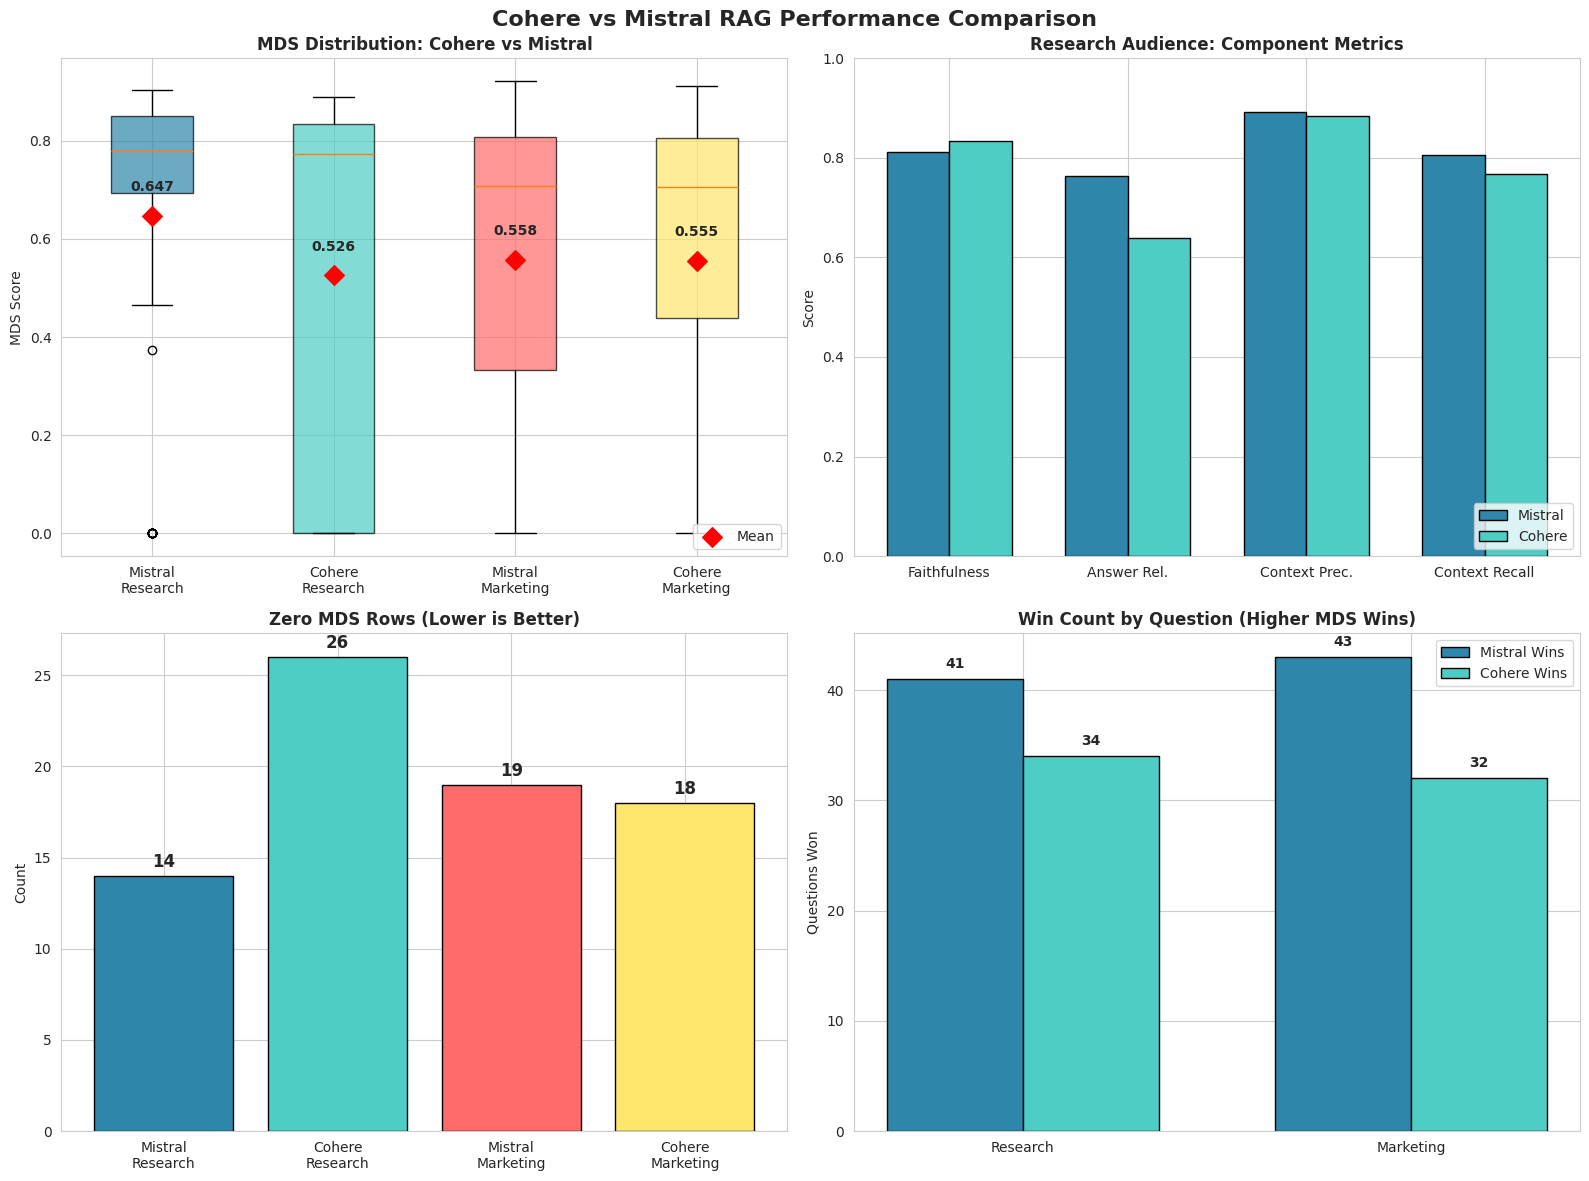

In [ ]:
"""

====================================================
Compares RAG results between Cohere and Mistral LLMs
across different audience types and prompts.


Input Files Required:
    - metric_results_full_val_q_cohere.csv (Cohere results)
    - metric_results_full_val_q_prompt_48.csv (Mistral results)

Output Files Generated:
    - cohere_vs_mistral_comparison.png (visualization)
    - Cohere_vs_Mistral_Report.md (detailed report)
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# =============================================================================
# CONFIGURATION
# =============================================================================

# Input file paths
COHERE_RESULTS_FILE = f'{output_folder}metric_results_full_val_q_cohere.csv'
MISTRAL_RESULTS_FILE = f'{output_folder}metric_results_full_val_q_prompt_48.csv'

# Output paths
OUTPUT_DIR = output_folder
VISUALIZATION_FILE = f'{OUTPUT_DIR}cohere_vs_mistral_comparison.png'
REPORT_FILE = f'{OUTPUT_DIR}Cohere_vs_Mistral_Report.md'

# Config name mappings
MISTRAL_RESEARCH_CONFIG = 'full_question_research_prompt48'
MISTRAL_MARKETING_CONFIG = 'full_question_marketing_prompt48'
COHERE_RESEARCH_AUDIENCE = 'research'
COHERE_MARKETING_AUDIENCE = 'marketing'


# =============================================================================
# DATA LOADING
# =============================================================================

def load_data(cohere_file, mistral_file):
    """Load Cohere and Mistral results files"""
    print("Loading data files...")
    df_cohere = pd.read_csv(cohere_file)
    df_mistral = pd.read_csv(mistral_file)

    print(f"  Cohere: {len(df_cohere)} rows")
    print(f"  Mistral: {len(df_mistral)} rows")

    return df_cohere, df_mistral


# =============================================================================
# ANALYSIS FUNCTIONS
# =============================================================================

def get_overview(df_cohere, df_mistral):
    """Print overview of both datasets"""
    print("\n" + "=" * 100)
    print(" DATA OVERVIEW")
    print("=" * 100)

    print("\n### COHERE:")
    print(f"  Total rows: {len(df_cohere)}")
    print(f"  Unique questions: {df_cohere['question_num'].nunique()}")
    print(f"  Audience types: {list(df_cohere['audience_type'].unique())}")
    print(f"  Config names: {list(df_cohere['config_name'].unique())}")
    print(f"  LLM: {df_cohere['llm_name'].iloc[0]}")

    print("\n### MISTRAL:")
    print(f"  Total rows: {len(df_mistral)}")
    print(f"  Unique questions: {df_mistral['question_num'].nunique()}")
    print(f"  Config names: {list(df_mistral['config_name'].unique())}")
    print(f"  LLM: {df_mistral['llm_name'].iloc[0]}")


def compare_by_audience(df_cohere, df_mistral):
    """Compare metrics by audience type"""
    print("\n" + "=" * 100)
    print(" COMPARISON BY AUDIENCE TYPE")
    print("=" * 100)

    results = {}

    # Get data subsets
    cohere_research = df_cohere[df_cohere['audience_type'] == COHERE_RESEARCH_AUDIENCE]
    cohere_marketing = df_cohere[df_cohere['audience_type'] == COHERE_MARKETING_AUDIENCE]
    mistral_research = df_mistral[df_mistral['config_name'] == MISTRAL_RESEARCH_CONFIG]
    mistral_marketing = df_mistral[df_mistral['config_name'] == MISTRAL_MARKETING_CONFIG]

    configs = [
        ("Mistral Research", mistral_research),
        ("Cohere Research", cohere_research),
        ("Mistral Marketing", mistral_marketing),
        ("Cohere Marketing", cohere_marketing),
    ]

    print(f"\n{'Config':<25} {'MDS Mean':<12} {'Faith':<10} {'AnsRel':<10} {'Zero MDS'}")
    print("-" * 75)

    for name, data in configs:
        mds_mean = data['mds'].mean()
        faith = data['ragas_score_faithfulness'].mean()
        ans_rel = data['ragas_score_answer_relevancy'].mean()
        zero_count = len(data[data['mds'] < 0.001])

        results[name] = {
            'mds_mean': mds_mean,
            'faithfulness': faith,
            'answer_relevancy': ans_rel,
            'zero_mds': zero_count,
            'data': data
        }

        print(f"{name:<25} {mds_mean:.4f}       {faith:.4f}     {ans_rel:.4f}     {zero_count}")

    return results


def detailed_comparison(df_cohere, df_mistral, audience='research'):
    """Detailed metric comparison for a specific audience"""
    print(f"\n" + "=" * 100)
    print(f" DETAILED COMPARISON: {audience.upper()}")
    print("=" * 100)

    if audience == 'research':
        mistral_data = df_mistral[df_mistral['config_name'] == MISTRAL_RESEARCH_CONFIG]
        cohere_data = df_cohere[df_cohere['audience_type'] == COHERE_RESEARCH_AUDIENCE]
    else:
        mistral_data = df_mistral[df_mistral['config_name'] == MISTRAL_MARKETING_CONFIG]
        cohere_data = df_cohere[df_cohere['audience_type'] == COHERE_MARKETING_AUDIENCE]

    metrics = [
        ('MDS Mean', 'mds'),
        ('Faithfulness', 'ragas_score_faithfulness'),
        ('Answer Relevancy', 'ragas_score_answer_relevancy'),
        ('Context Precision', 'ragas_score_context_precision'),
        ('Context Recall', 'ragas_score_context_recall'),
    ]

    print(f"\n{'Metric':<25} {'Mistral':<15} {'Cohere':<15} {'Change':<15} {'Winner'}")
    print("-" * 85)

    comparison = {}
    for label, col in metrics:
        m_val = mistral_data[col].mean()
        c_val = cohere_data[col].mean()
        change = c_val - m_val
        winner = "Cohere" if c_val > m_val else "Mistral" if m_val > c_val else "Tie"

        comparison[label] = {
            'mistral': m_val,
            'cohere': c_val,
            'change': change,
            'winner': winner
        }

        print(f"{label:<25} {m_val:.4f}          {c_val:.4f}          {change:+.4f}          {winner}")

    # Zero MDS
    m_zero = len(mistral_data[mistral_data['mds'] < 0.001])
    c_zero = len(cohere_data[cohere_data['mds'] < 0.001])
    winner = "Mistral" if m_zero < c_zero else "Cohere" if c_zero < m_zero else "Tie"
    print(f"{'Zero MDS Count':<25} {m_zero:<15} {c_zero:<15} {c_zero - m_zero:+}              {winner}")

    return comparison


def question_by_question_comparison(df_cohere, df_mistral, audience='research'):
    """Compare results question by question"""
    print(f"\n" + "=" * 100)
    print(f" QUESTION-BY-QUESTION: {audience.upper()}")
    print("=" * 100)

    if audience == 'research':
        mistral_data = df_mistral[df_mistral['config_name'] == MISTRAL_RESEARCH_CONFIG]
        cohere_data = df_cohere[df_cohere['audience_type'] == COHERE_RESEARCH_AUDIENCE]
    else:
        mistral_data = df_mistral[df_mistral['config_name'] == MISTRAL_MARKETING_CONFIG]
        cohere_data = df_cohere[df_cohere['audience_type'] == COHERE_MARKETING_AUDIENCE]

    # Create comparison dataframe
    mistral_mds = mistral_data.set_index('question_num')['mds']
    cohere_mds = cohere_data.set_index('question_num')['mds']

    comparison = pd.DataFrame({
        'mistral': mistral_mds,
        'cohere': cohere_mds
    }).dropna()

    comparison['winner'] = np.where(
        comparison['cohere'] > comparison['mistral'], 'Cohere',
        np.where(comparison['mistral'] > comparison['cohere'], 'Mistral', 'Tie')
    )
    comparison['diff'] = comparison['cohere'] - comparison['mistral']

    # Print win counts
    print("\n### WIN COUNT:")
    print(comparison['winner'].value_counts())

    # Top Cohere wins
    cohere_wins = comparison[comparison['winner'] == 'Cohere'].sort_values('diff', ascending=False).head(10)
    if len(cohere_wins) > 0:
        print(f"\n### TOP 10 QUESTIONS WHERE COHERE WINS:")
        print(f"{'Q#':<8} {'Mistral':<12} {'Cohere':<12} {'Diff'}")
        for q, row in cohere_wins.iterrows():
            print(f"Q{q:<7} {row['mistral']:.4f}       {row['cohere']:.4f}       {row['diff']:+.4f}")

    # Top Mistral wins
    mistral_wins = comparison[comparison['winner'] == 'Mistral'].sort_values('diff').head(10)
    if len(mistral_wins) > 0:
        print(f"\n### TOP 10 QUESTIONS WHERE MISTRAL WINS:")
        print(f"{'Q#':<8} {'Mistral':<12} {'Cohere':<12} {'Diff'}")
        for q, row in mistral_wins.iterrows():
            print(f"Q{q:<7} {row['mistral']:.4f}       {row['cohere']:.4f}       {row['diff']:+.4f}")

    return comparison


def analyze_zero_mds(df_cohere, df_mistral):
    """Analyze zero MDS cases and their causes"""
    print("\n" + "=" * 100)
    print(" ZERO MDS ANALYSIS")
    print("=" * 100)

    # Combine both datasets with LLM identifier
    df_cohere_copy = df_cohere.copy()
    df_cohere_copy['llm'] = 'Cohere'

    df_mistral_copy = df_mistral.copy()
    df_mistral_copy['llm'] = 'Mistral'

    for llm_name, df in [('Cohere', df_cohere), ('Mistral', df_mistral)]:
        print(f"\n### {llm_name.upper()} ZERO MDS BREAKDOWN:")

        zero_mds = df[df['mds'] < 0.001]
        print(f"Total Zero MDS rows: {len(zero_mds)}")

        if len(zero_mds) > 0:
            # By config
            print("\nBy Config:")
            for config in df['config_name'].unique():
                cfg_zero = zero_mds[zero_mds['config_name'] == config]
                zero_faith = len(cfg_zero[cfg_zero['ragas_score_faithfulness'] < 0.01])
                zero_ans = len(cfg_zero[cfg_zero['ragas_score_answer_relevancy'] < 0.01])
                print(f"  {config}:")
                print(f"    Total: {len(cfg_zero)}, Zero Faith: {zero_faith}, Zero AnsRel: {zero_ans}")


# =============================================================================
# VISUALIZATION
# =============================================================================

def create_visualization(df_cohere, df_mistral, output_file):
    """Create 4-panel comparison visualization"""
    print("\n" + "=" * 100)
    print(" CREATING VISUALIZATION")
    print("=" * 100)

    sns.set_style("whitegrid")
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('Cohere vs Mistral RAG Performance Comparison', fontsize=16, fontweight='bold')

    # Get data subsets
    mistral_r = df_mistral[df_mistral['config_name'] == MISTRAL_RESEARCH_CONFIG]
    mistral_m = df_mistral[df_mistral['config_name'] == MISTRAL_MARKETING_CONFIG]
    cohere_r = df_cohere[df_cohere['audience_type'] == COHERE_RESEARCH_AUDIENCE]
    cohere_m = df_cohere[df_cohere['audience_type'] == COHERE_MARKETING_AUDIENCE]

    colors = ['#2E86AB', '#4ECDC4', '#FF6B6B', '#FFE66D']

    # ========================================================================
    # Panel 1: MDS Distribution
    # ========================================================================
    ax = axes[0, 0]

    data_to_plot = [
        mistral_r['mds'].dropna(),
        cohere_r['mds'].dropna(),
        mistral_m['mds'].dropna(),
        cohere_m['mds'].dropna(),
    ]

    labels = ['Mistral\nResearch', 'Cohere\nResearch', 'Mistral\nMarketing', 'Cohere\nMarketing']

    bp = ax.boxplot(data_to_plot, tick_labels=labels, patch_artist=True)
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)

    means = [d.mean() for d in data_to_plot]
    ax.scatter(range(1, 5), means, color='red', s=100, zorder=5, marker='D', label='Mean')

    for i, m in enumerate(means):
        ax.text(i+1, m + 0.05, f'{m:.3f}', ha='center', fontsize=10, fontweight='bold')

    ax.set_ylabel('MDS Score', fontsize=10)
    ax.set_title('MDS Distribution: Cohere vs Mistral', fontweight='bold', fontsize=12)
    ax.legend(loc='lower right')

    # ========================================================================
    # Panel 2: Component Metrics (Research)
    # ========================================================================
    ax = axes[0, 1]

    metrics = ['Faithfulness', 'Answer Rel.', 'Context Prec.', 'Context Recall']
    metric_cols = ['ragas_score_faithfulness', 'ragas_score_answer_relevancy',
                   'ragas_score_context_precision', 'ragas_score_context_recall']

    x = np.arange(len(metrics))
    width = 0.35

    mistral_vals = [mistral_r[m].mean() for m in metric_cols]
    cohere_vals = [cohere_r[m].mean() for m in metric_cols]

    ax.bar(x - width/2, mistral_vals, width, label='Mistral', color='#2E86AB', edgecolor='black')
    ax.bar(x + width/2, cohere_vals, width, label='Cohere', color='#4ECDC4', edgecolor='black')

    ax.set_xticks(x)
    ax.set_xticklabels(metrics)
    ax.set_ylabel('Score', fontsize=10)
    ax.set_title('Research Audience: Component Metrics', fontweight='bold', fontsize=12)
    ax.legend(loc='lower right')
    ax.set_ylim(0, 1)

    # ========================================================================
    # Panel 3: Zero MDS Comparison
    # ========================================================================
    ax = axes[1, 0]

    configs = ['Mistral\nResearch', 'Cohere\nResearch', 'Mistral\nMarketing', 'Cohere\nMarketing']
    zero_counts = [
        len(mistral_r[mistral_r['mds'] < 0.001]),
        len(cohere_r[cohere_r['mds'] < 0.001]),
        len(mistral_m[mistral_m['mds'] < 0.001]),
        len(cohere_m[cohere_m['mds'] < 0.001]),
    ]

    bars = ax.bar(configs, zero_counts, color=colors, edgecolor='black')

    for bar, count in zip(bars, zero_counts):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                str(count), ha='center', fontsize=12, fontweight='bold')

    ax.set_ylabel('Count', fontsize=10)
    ax.set_title('Zero MDS Rows (Lower is Better)', fontweight='bold', fontsize=12)

    # ========================================================================
    # Panel 4: Win Count
    # ========================================================================
    ax = axes[1, 1]

    # Research wins
    cohere_r_mds = cohere_r.set_index('question_num')['mds']
    mistral_r_mds = mistral_r.set_index('question_num')['mds']
    research_comp = pd.DataFrame({'mistral': mistral_r_mds, 'cohere': cohere_r_mds}).dropna()

    mistral_wins_r = (research_comp['mistral'] > research_comp['cohere']).sum()
    cohere_wins_r = (research_comp['cohere'] > research_comp['mistral']).sum()

    # Marketing wins
    cohere_m_mds = cohere_m.set_index('question_num')['mds']
    mistral_m_mds = mistral_m.set_index('question_num')['mds']
    marketing_comp = pd.DataFrame({'mistral': mistral_m_mds, 'cohere': cohere_m_mds}).dropna()

    mistral_wins_m = (marketing_comp['mistral'] > marketing_comp['cohere']).sum()
    cohere_wins_m = (marketing_comp['cohere'] > marketing_comp['mistral']).sum()

    x = np.arange(2)
    width = 0.35

    ax.bar(x - width/2, [mistral_wins_r, mistral_wins_m], width, label='Mistral Wins', color='#2E86AB', edgecolor='black')
    ax.bar(x + width/2, [cohere_wins_r, cohere_wins_m], width, label='Cohere Wins', color='#4ECDC4', edgecolor='black')

    ax.set_xticks(x)
    ax.set_xticklabels(['Research', 'Marketing'])
    ax.set_ylabel('Questions Won', fontsize=10)
    ax.set_title('Win Count by Question (Higher MDS Wins)', fontweight='bold', fontsize=12)
    ax.legend()

    # Add counts on bars
    ax.text(-width/2, mistral_wins_r + 1, str(mistral_wins_r), ha='center', fontweight='bold')
    ax.text(width/2, cohere_wins_r + 1, str(cohere_wins_r), ha='center', fontweight='bold')
    ax.text(1 - width/2, mistral_wins_m + 1, str(mistral_wins_m), ha='center', fontweight='bold')
    ax.text(1 + width/2, cohere_wins_m + 1, str(cohere_wins_m), ha='center', fontweight='bold')

    plt.tight_layout()
    plt.savefig(output_file, dpi=300, bbox_inches='tight')
    print(f"✓ Saved visualization: {output_file}")

    return fig


# =============================================================================
# REPORT GENERATION
# =============================================================================

def generate_report(df_cohere, df_mistral, output_file):
    """Generate markdown report"""
    print("\n" + "=" * 100)
    print(" GENERATING REPORT")
    print("=" * 100)

    # Get data subsets
    mistral_r = df_mistral[df_mistral['config_name'] == MISTRAL_RESEARCH_CONFIG]
    mistral_m = df_mistral[df_mistral['config_name'] == MISTRAL_MARKETING_CONFIG]
    cohere_r = df_cohere[df_cohere['audience_type'] == COHERE_RESEARCH_AUDIENCE]
    cohere_m = df_cohere[df_cohere['audience_type'] == COHERE_MARKETING_AUDIENCE]

    # Calculate metrics
    metrics = {
        'mistral_r': {
            'mds': mistral_r['mds'].mean(),
            'faith': mistral_r['ragas_score_faithfulness'].mean(),
            'ans_rel': mistral_r['ragas_score_answer_relevancy'].mean(),
            'zero': len(mistral_r[mistral_r['mds'] < 0.001])
        },
        'cohere_r': {
            'mds': cohere_r['mds'].mean(),
            'faith': cohere_r['ragas_score_faithfulness'].mean(),
            'ans_rel': cohere_r['ragas_score_answer_relevancy'].mean(),
            'zero': len(cohere_r[cohere_r['mds'] < 0.001])
        },
        'mistral_m': {
            'mds': mistral_m['mds'].mean(),
            'faith': mistral_m['ragas_score_faithfulness'].mean(),
            'ans_rel': mistral_m['ragas_score_answer_relevancy'].mean(),
            'zero': len(mistral_m[mistral_m['mds'] < 0.001])
        },
        'cohere_m': {
            'mds': cohere_m['mds'].mean(),
            'faith': cohere_m['ragas_score_faithfulness'].mean(),
            'ans_rel': cohere_m['ragas_score_answer_relevancy'].mean(),
            'zero': len(cohere_m[cohere_m['mds'] < 0.001])
        }
    }

    report = f"""# 📊 Cohere vs Mistral RAG Performance Comparison

## Overview

| Metric | Value |
|--------|-------|
| LLMs Tested | Cohere, Mistral-7B-Instruct-v0.3 |
| Questions | {df_cohere['question_num'].nunique()} |

---

##  Overall Results

| Config | LLM | MDS Mean | Faithfulness | Answer Rel. | Zero MDS |
|--------|-----|----------|--------------|-------------|----------|
| Research | **Mistral** | **{metrics['mistral_r']['mds']:.4f}** | {metrics['mistral_r']['faith']:.4f} | **{metrics['mistral_r']['ans_rel']:.4f}** | **{metrics['mistral_r']['zero']}** |
| Research | Cohere | {metrics['cohere_r']['mds']:.4f} | **{metrics['cohere_r']['faith']:.4f}** | {metrics['cohere_r']['ans_rel']:.4f} | {metrics['cohere_r']['zero']} |
| Marketing | Mistral | {metrics['mistral_m']['mds']:.4f} | **{metrics['mistral_m']['faith']:.4f}** | {metrics['mistral_m']['ans_rel']:.4f} | {metrics['mistral_m']['zero']} |
| Marketing | Cohere | {metrics['cohere_m']['mds']:.4f} | {metrics['cohere_m']['faith']:.4f} | **{metrics['cohere_m']['ans_rel']:.4f}** | **{metrics['cohere_m']['zero']}** |

###  Winner: Mistral

---

##  Research Audience: Detailed Comparison

| Metric | Mistral | Cohere | Change | Winner |
|--------|---------|--------|--------|--------|
| MDS Mean | **{metrics['mistral_r']['mds']:.4f}** | {metrics['cohere_r']['mds']:.4f} | {metrics['cohere_r']['mds'] - metrics['mistral_r']['mds']:+.4f} | Mistral |
| Faithfulness | {metrics['mistral_r']['faith']:.4f} | **{metrics['cohere_r']['faith']:.4f}** | {metrics['cohere_r']['faith'] - metrics['mistral_r']['faith']:+.4f} | Cohere |
| Answer Relevancy | **{metrics['mistral_r']['ans_rel']:.4f}** | {metrics['cohere_r']['ans_rel']:.4f} | {metrics['cohere_r']['ans_rel'] - metrics['mistral_r']['ans_rel']:+.4f} | Mistral |
| Zero MDS Count | **{metrics['mistral_r']['zero']}** | {metrics['cohere_r']['zero']} | {metrics['cohere_r']['zero'] - metrics['mistral_r']['zero']:+} | Mistral |

---

##  Key Findings

### 1. Mistral Wins Overall
- Higher MDS for both audiences
- Better Answer Relevancy scores
- Fewer zero MDS failures

### 2. Cohere's Strength: Faithfulness
- Slightly higher faithfulness
- Responses are more grounded in context

### 3. Cohere's Weakness: Answer Relevancy
- Significantly lower Answer Relevancy
- Causes more zero MDS rows

---

##  Recommendations

| Use Case | Recommended LLM |
|----------|-----------------|
| **General RAG** | **Mistral** |
| **High-Faithfulness needed** | Cohere |

---

*Report generated automatically*
"""

    with open(output_file, 'w') as f:
        f.write(report)

    print(f"✓ Saved report: {output_file}")



print("=" * 100)
print(" COHERE vs MISTRAL COMPARISON ANALYSIS")
print("=" * 100)

# Load data
df_cohere, df_mistral = load_data(COHERE_RESULTS_FILE, MISTRAL_RESULTS_FILE)

# Overview
get_overview(df_cohere, df_mistral)

# Compare by audience
results = compare_by_audience(df_cohere, df_mistral)

# Detailed comparisons
detailed_comparison(df_cohere, df_mistral, audience='research')
detailed_comparison(df_cohere, df_mistral, audience='marketing')

# Question-by-question
question_by_question_comparison(df_cohere, df_mistral, audience='research')
question_by_question_comparison(df_cohere, df_mistral, audience='marketing')

# Zero MDS analysis
analyze_zero_mds(df_cohere, df_mistral)

# Create visualization
create_visualization(df_cohere, df_mistral, VISUALIZATION_FILE)

# Generate report
generate_report(df_cohere, df_mistral, REPORT_FILE)

print("\n" + "=" * 100)
print(" ANALYSIS COMPLETE")
print("=" * 100)




#### MISTRAL final run

# 📊 Mistral RAG Performance - Research vs Marketing Audience

Overview

| Metric | Value |
|--------|-------|
| LLM | Mistral-7B-Instruct-v0.3 |
| Total Questions | 78 |
| Chunk Size | 500 |
| Embedding | multi-qa-mpnet-base-dot-v1 |
| Research Prompt | research_prompt_48 (Q48 few-shot) |
| Marketing Prompt | marketing_prompt_q33 (Q33 few-shot) |

---

Overall Performance Summary

| Metric | Research | Marketing | Winner |
|--------|----------|-----------|--------|
| **MDS Mean** | **0.5606** | 0.5569 | Research (+0.4%) |
| **MDS Median** | **0.7692** | 0.7015 | Research |
| Faithfulness | **0.7849** | 0.6489 | Research (+13.6%) |
| Answer Relevancy | 0.6742 | **0.7410** | Marketing (+6.7%) |
| Context Precision | **0.8710** | 0.8112 | Research |
| Context Recall | 0.7741 | **0.8433** | Marketing |
| BERTScore F1 | 0.6372 | **0.6973** | Marketing |
| Zero MDS Rows | 22 | **19** | Marketing |

Key Finding: Research Wins Overall MDS, But It's Close

- Research has higher MDS mean and median
- Marketing has better Answer Relevancy and Context Recall
- Research has significantly higher Faithfulness (+13.6%)

---

Win Count Per Question

| Audience | Questions Won |
|----------|---------------|
| **Research** | **40** (51%) |
| Marketing | 34 (44%) |
| Tie | 4 (5%) |

---

Performance Distribution

### Research Audience

| Category | Count | Percentage |
|----------|-------|------------|
|  Excellent (≥0.85) | 16 | 20.5% |
|  Good (0.70-0.85) | 29 | 37.2% |
|  Fair (0.50-0.70) | 7 | 9.0% |
|  Poor (0.001-0.50) | 1 | 1.3% |
|  Zero (<0.001) | 22 | 28.2% |
| NaN | 3 | 3.8% |

**57.7% of questions perform Good or Excellent**

### Marketing Audience

| Category | Count | Percentage |
|----------|-------|------------|
|  Excellent (≥0.85) | 13 | 16.7% |
| Good (0.70-0.85) | 26 | 33.3% |
|  Fair (0.50-0.70) | 16 | 20.5% |
| Poor (0.001-0.50) | 2 | 2.6% |
| Zero (<0.001) | 19 | 24.4% |
| NaN | 2 | 2.6% |

**50.0% of questions perform Good or Excellent**

---

## 🚨 Zero MDS Analysis

### Summary

| Audience | Total Zero | Zero Faithfulness | Zero Answer Rel. |
|----------|------------|-------------------|------------------|
| Research | 22 | 1 | **21 (95%)** |
| Marketing | 19 | 3 | 16 (84%) |

### Critical Issue: Zero Answer Relevancy

**Zero Answer Relevancy is the primary cause of MDS failures for both audiences:**
- Research: 21/22 zero MDS cases (95%)
- Marketing: 16/19 zero MDS cases (84%)

### Questions Failing for BOTH Audiences

| Question | Issue |
|----------|-------|
| Q2 | Zero Answer Relevancy |
| Q8 | Zero Context Precision |
| Q9 | Multiple issues |
| Q12 | Zero Answer Relevancy |
| Q13 | Zero Answer Relevancy |
| Q19 | Zero Answer Relevancy |
| Q24 | Mixed issues |
| Q51 | Zero Answer Relevancy |
| Q73 | Zero Faithfulness + Zero Answer Relevancy |

**9 questions fail for both audiences** - these likely have retrieval or question formulation issues.

---

## 📋 Top 10 Performing Questions

| Rank | Q# | Research | Marketing | Best | Winner |
|------|-----|----------|-----------|------|--------|
| 1 | Q78 | 0.4680 | **0.9574** | 0.9574 | Marketing |
| 2 | Q33 | 0.0000 | **0.9127** | 0.9127 | Marketing |
| 3 | Q35 | **0.9094** | 0.9074 | 0.9094 | Research |
| 4 | Q23 | 0.8383 | **0.9049** | 0.9049 | Marketing |
| 5 | Q1 | 0.8382 | **0.9044** | 0.9044 | Marketing |
| 6 | Q101 | 0.8621 | **0.9042** | 0.9042 | Marketing |
| 7 | Q61 | **0.8954** | 0.0000 | 0.8954 | Research |
| 8 | Q63 | 0.8875 | **0.8954** | 0.8954 | Marketing |
| 9 | Q38 | 0.6569 | **0.8926** | 0.8926 | Marketing |
| 10 | Q28 | **0.8926** | 0.0000 | 0.8926 | Research |

---

## 📋 Questions with Large Audience Difference (|diff| > 0.5)

| Q# | Research | Marketing | Diff | Better For |
|----|----------|-----------|------|------------|
| Q33 | 0.0000 | 0.9127 | -0.91 | Marketing |
| Q61 | 0.8954 | 0.0000 | +0.90 | Research |
| Q28 | 0.8926 | 0.0000 | +0.89 | Research |
| Q76 | 0.8588 | 0.0000 | +0.86 | Research |
| Q52 | 0.0000 | 0.8359 | -0.84 | Marketing |
| Q0 | 0.8342 | 0.0000 | +0.83 | Research |
| Q64 | 0.8223 | 0.0000 | +0.82 | Research |
| Q86 | 0.8036 | 0.0000 | +0.80 | Research |
| Q53 | 0.0000 | 0.8000 | -0.80 | Marketing |

**Observation:** Large differences are typically caused by one audience scoring zero while the other scores well.

---

## 🎯 Key Insights

### 1. Research Prompt Strengths
- Higher Faithfulness (0.78 vs 0.65)
- Better Context Precision (0.87 vs 0.81)
- More questions with Excellent scores (16 vs 13)

### 2. Marketing Prompt Strengths
- Higher Answer Relevancy (0.74 vs 0.67)
- Better Context Recall (0.84 vs 0.77)
- Fewer zero MDS failures (19 vs 22)
- More consistent (lower std: 0.34 vs 0.37)

### 3. Common Weakness: Answer Relevancy
- Both prompts suffer from zero Answer Relevancy issues
- This is likely due to response format not matching RAGAS expectations

### 4. 9 Problematic Questions
- Q2, Q8, Q9, Q12, Q13, Q19, Q24, Q51, Q73 fail for both audiences
- These need investigation (likely retrieval or question issues)

---

## ✅ Recommendations

### 1. Use Audience-Appropriate Prompts
- **Research audience:** Use research_prompt_48 (higher faithfulness)
- **Marketing audience:** Use marketing_prompt_q33 (higher relevancy)

### 2. Investigate Problem Questions
Focus on the 9 questions that fail for both audiences:
- Check if retrieval returns relevant documents
- Verify question formulation is clear
- Test with different prompts

### 3. Address Answer Relevancy Issue
- Review response format vs RAGAS expectations
- Consider adjusting response structure
- Test alternative RAGAS configurations

### 4. Consider Ensemble Approach
For critical applications, run both prompts and select best response based on:
- Question type
- Required faithfulness level
- Audience needs

---



---

## Summary

| Metric | Research | Marketing | Overall Winner |
|--------|----------|-----------|----------------|
| MDS Mean | **0.5606** | 0.5569 | Research |
| Win Count | **40** | 34 | Research |
| Zero Failures | 22 | **19** | Marketing |
| Faithfulness | **0.7849** | 0.6489 | Research |
| Answer Relevancy | 0.6742 | **0.7410** | Marketing |

**Overall: Research prompt slightly outperforms Marketing, but both have significant zero MDS issues caused by Answer Relevancy failures.**

 MISTRAL AUDIENCE COMPARISON ANALYSIS
Loading data file...
  Total rows: 156
  Unique questions: 78

 DATA OVERVIEW

Total rows: 156
Unique questions: 78
Question range: 0 to 110
Audience types: ['research', 'marketing']
Config names: ['research_prompt_48', 'marketing_prompt_q33']
LLM: mistralai/Mistral-7B-Instruct-v0.3
Chunk size: 500
Embedding: multi-qa-mpnet-base-dot-v1

### ROWS BY CONFIG:
  research_prompt_48 (research): 78 rows
  marketing_prompt_q33 (marketing): 78 rows

### MDS SCORE DISTRIBUTION:
  NaN MDS values: 5 (3.2%)
  Zero MDS rows: 41 (26.3%)
  Valid MDS rows: 151

  Overall Statistics:
    Mean:   0.5588
    Std:    0.3549
    Min:    0.0000
    Max:    0.9574
    Median: 0.7198

COMPARISON BY AUDIENCE TYPE

Metric                         Research        Marketing       Diff         Winner
-------------------------------------------------------------------------------------
MDS Mean                       0.5606          0.5569          -0.0037      Research
MDS Median

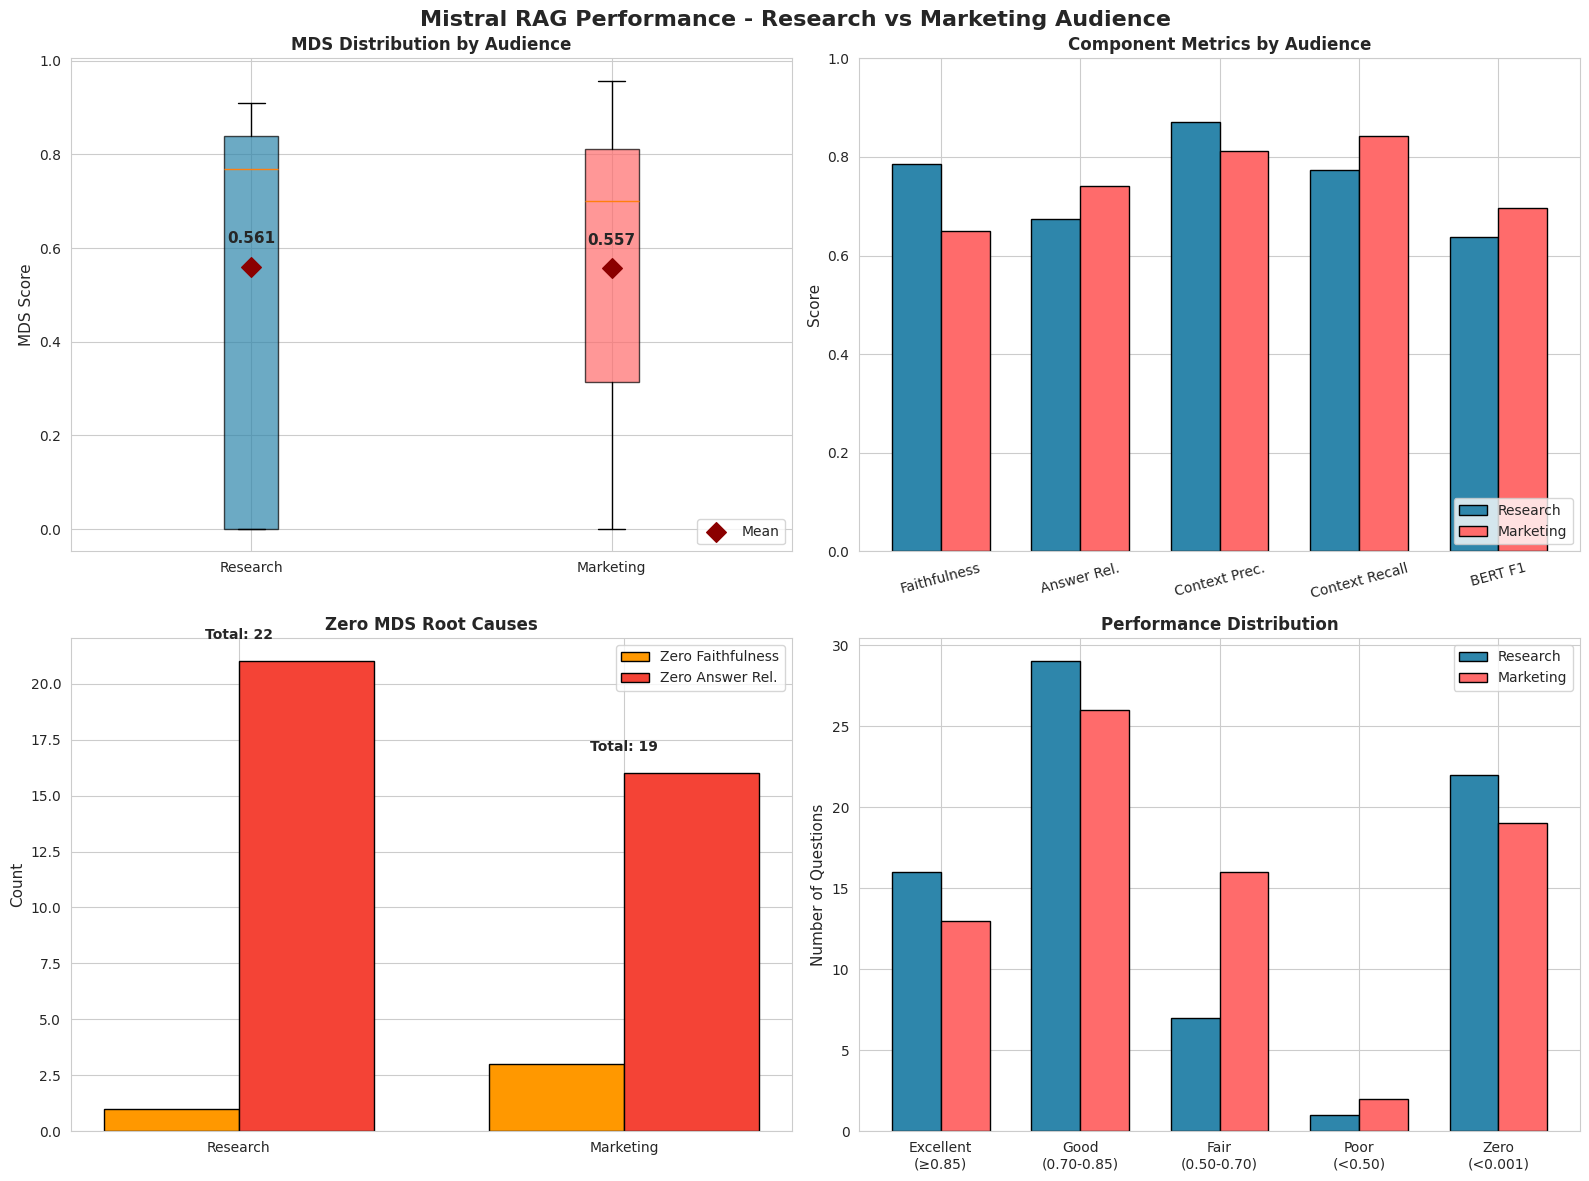

In [ ]:
"""
Mistral RAG Performance Comparison Script - Research vs Marketing Audience
===========================================================================
Compares RAG results between Research and Marketing audiences using Mistral LLM.

Usage:
    python mistral_audience_comparison.py

Input Files Required:
    - metric_results_full_val_q_mistral.csv (Mistral results with both audiences)

Output Files Generated:
    - mistral_audience_comparison.png (visualization)
    - Mistral_Audience_Comparison_Report.md (detailed report)
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# =============================================================================
# CONFIGURATION
# =============================================================================

# Input file path - UPDATE THIS TO YOUR FILE LOCATION
MISTRAL_RESULTS_FILE = f'{output_folder}metric_results_full_val_q_mistral.csv'

# Output paths
OUTPUT_DIR = output_folder
VISUALIZATION_FILE = f'{OUTPUT_DIR}mistral_audience_comparison.png'
REPORT_FILE = f'{OUTPUT_DIR}Mistral_Audience_Comparison_Report.md'

# Audience types
RESEARCH_AUDIENCE = 'research'
MARKETING_AUDIENCE = 'marketing'


# =============================================================================
# DATA LOADING
# =============================================================================

def load_data(file_path):
    """Load Mistral results file"""
    print("Loading data file...")
    df = pd.read_csv(file_path)
    print(f"  Total rows: {len(df)}")
    print(f"  Unique questions: {df['question_num'].nunique()}")
    return df


# =============================================================================
# ANALYSIS FUNCTIONS
# =============================================================================

def get_overview(df):
    """Print overview of dataset"""
    print("\n" + "=" * 100)
    print(" DATA OVERVIEW")
    print("=" * 100)

    print(f"\nTotal rows: {len(df)}")
    print(f"Unique questions: {df['question_num'].nunique()}")
    print(f"Question range: {df['question_num'].min()} to {df['question_num'].max()}")
    print(f"Audience types: {list(df['audience_type'].unique())}")
    print(f"Config names: {list(df['config_name'].unique())}")
    print(f"LLM: {df['llm_name'].iloc[0]}")
    print(f"Chunk size: {df['chunksize'].iloc[0]}")
    print(f"Embedding: {df['embedding_model'].iloc[0]}")

    print("\n### ROWS BY CONFIG:")
    for config in df['config_name'].unique():
        cfg_data = df[df['config_name'] == config]
        audience = cfg_data['audience_type'].iloc[0]
        count = len(cfg_data)
        print(f"  {config} ({audience}): {count} rows")

    # MDS distribution
    print("\n### MDS SCORE DISTRIBUTION:")
    nan_mds = df['mds'].isna().sum()
    df_valid = df.dropna(subset=['mds'])
    zero_mds = len(df[df['mds'] < 0.001])

    print(f"  NaN MDS values: {nan_mds} ({nan_mds/len(df)*100:.1f}%)")
    print(f"  Zero MDS rows: {zero_mds} ({zero_mds/len(df)*100:.1f}%)")
    print(f"  Valid MDS rows: {len(df_valid)}")

    if len(df_valid) > 0:
        print(f"\n  Overall Statistics:")
        print(f"    Mean:   {df_valid['mds'].mean():.4f}")
        print(f"    Std:    {df_valid['mds'].std():.4f}")
        print(f"    Min:    {df_valid['mds'].min():.4f}")
        print(f"    Max:    {df_valid['mds'].max():.4f}")
        print(f"    Median: {df_valid['mds'].median():.4f}")


def compare_by_audience(df):
    """Compare metrics between research and marketing audiences"""
    print("\n" + "=" * 100)
    print("COMPARISON BY AUDIENCE TYPE")
    print("=" * 100)

    research = df[df['audience_type'] == RESEARCH_AUDIENCE]
    marketing = df[df['audience_type'] == MARKETING_AUDIENCE]

    metrics = [
        ('MDS Mean', 'mds', 'mean'),
        ('MDS Median', 'mds', 'median'),
        ('MDS Std', 'mds', 'std'),
        ('Faithfulness', 'ragas_score_faithfulness', 'mean'),
        ('Answer Relevancy', 'ragas_score_answer_relevancy', 'mean'),
        ('Context Precision', 'ragas_score_context_precision', 'mean'),
        ('Context Recall', 'ragas_score_context_recall', 'mean'),
        ('BERTScore F1', 'bert_score_f1', 'mean'),
    ]

    print(f"\n{'Metric':<30} {'Research':<15} {'Marketing':<15} {'Diff':<12} {'Winner'}")
    print("-" * 85)

    results = {}
    for label, col, agg in metrics:
        if agg == 'mean':
            r_val = research[col].mean()
            m_val = marketing[col].mean()
        elif agg == 'median':
            r_val = research[col].median()
            m_val = marketing[col].median()
        else:
            r_val = research[col].std()
            m_val = marketing[col].std()

        diff = m_val - r_val

        # For std, lower is better
        if 'Std' in label:
            winner = "Marketing" if m_val < r_val else "Research" if r_val < m_val else "Tie"
        else:
            winner = "Marketing" if m_val > r_val else "Research" if r_val > m_val else "Tie"

        results[label] = {
            'research': r_val,
            'marketing': m_val,
            'diff': diff,
            'winner': winner
        }

        r_str = f"{r_val:.4f}" if not pd.isna(r_val) else "NaN"
        m_str = f"{m_val:.4f}" if not pd.isna(m_val) else "NaN"
        print(f"{label:<30} {r_str:<15} {m_str:<15} {diff:+.4f}      {winner}")

    # Zero/NaN MDS
    r_zero = len(research[research['mds'] < 0.001])
    m_zero = len(marketing[marketing['mds'] < 0.001])
    r_nan = research['mds'].isna().sum()
    m_nan = marketing['mds'].isna().sum()

    print(f"\n{'Zero MDS Rows':<30} {r_zero:<15} {m_zero:<15} {m_zero - r_zero:+}           {'Research' if r_zero < m_zero else 'Marketing'}")
    print(f"{'NaN MDS Rows':<30} {r_nan:<15} {m_nan:<15}")

    results['zero_mds'] = {'research': r_zero, 'marketing': m_zero}
    results['nan_mds'] = {'research': r_nan, 'marketing': m_nan}

    return results, research, marketing


def get_performance_distribution(df):
    """Get performance distribution by audience"""
    print("\n" + "=" * 100)
    print(" MDS SCORE DISTRIBUTION BY AUDIENCE")
    print("=" * 100)

    distribution = {}

    for audience in [RESEARCH_AUDIENCE, MARKETING_AUDIENCE]:
        data = df[df['audience_type'] == audience]
        valid = data.dropna(subset=['mds'])
        total = len(data)

        dist = {
            'excellent': len(valid[valid['mds'] >= 0.85]),
            'good': len(valid[(valid['mds'] >= 0.70) & (valid['mds'] < 0.85)]),
            'fair': len(valid[(valid['mds'] >= 0.50) & (valid['mds'] < 0.70)]),
            'poor': len(valid[(valid['mds'] >= 0.001) & (valid['mds'] < 0.50)]),
            'zero': len(data[data['mds'] < 0.001]),
            'nan': data['mds'].isna().sum()
        }

        distribution[audience] = dist

        print(f"\n### {audience.upper()}:")
        print(f"   Excellent (≥0.85): {dist['excellent']} ({dist['excellent']/total*100:.1f}%)")
        print(f"   Good (0.70-0.85):   {dist['good']} ({dist['good']/total*100:.1f}%)")
        print(f"   Fair (0.50-0.70):   {dist['fair']} ({dist['fair']/total*100:.1f}%)")
        print(f"   Poor (0.001-0.50):  {dist['poor']} ({dist['poor']/total*100:.1f}%)")
        print(f"   Zero (<0.001):      {dist['zero']} ({dist['zero']/total*100:.1f}%)")
        print(f"   NaN:                {dist['nan']} ({dist['nan']/total*100:.1f}%)")

    return distribution


def analyze_zero_mds(df):
    """Analyze zero MDS cases and their causes"""
    print("\n" + "=" * 100)
    print(" ZERO MDS ANALYSIS")
    print("=" * 100)

    zero_mds = df[df['mds'] < 0.001]
    print(f"\nTotal Zero MDS rows: {len(zero_mds)} out of {len(df)} ({len(zero_mds)/len(df)*100:.1f}%)")

    analysis = {}

    print("\n### BY AUDIENCE:")
    for audience in df['audience_type'].unique():
        aud_zero = zero_mds[zero_mds['audience_type'] == audience]
        zero_faith = len(aud_zero[aud_zero['ragas_score_faithfulness'] < 0.01])
        zero_ans = len(aud_zero[aud_zero['ragas_score_answer_relevancy'] < 0.01])

        analysis[audience] = {
            'total': len(aud_zero),
            'zero_faith': zero_faith,
            'zero_ans_rel': zero_ans
        }

        print(f"\n{audience.upper()} ({len(aud_zero)} zero MDS rows):")
        print(f"  - Zero Faithfulness: {zero_faith}")
        print(f"  - Zero Answer Relevancy: {zero_ans}")

    # Detailed cases
    print("\n\n### DETAILED ZERO MDS CASES:")
    print(f"{'Audience':<12} {'Q#':<6} {'Faith':<8} {'AnsRel':<8} {'CtxPrec':<10} {'Cause'}")
    print("-" * 65)

    for _, row in zero_mds.iterrows():
        causes = []
        if row['ragas_score_faithfulness'] < 0.01:
            causes.append("Zero Faith")
        if row['ragas_score_answer_relevancy'] < 0.01:
            causes.append("Zero AnsRel")
        if pd.isna(row['ragas_score_context_precision']) or row['ragas_score_context_precision'] < 0.01:
            causes.append("Zero/NaN CtxPrec")

        cause = ", ".join(causes) if causes else "Unknown"
        ctx_str = f"{row['ragas_score_context_precision']:.3f}" if not pd.isna(row['ragas_score_context_precision']) else "NaN"

        print(f"{row['audience_type']:<12} Q{int(row['question_num']):<5} {row['ragas_score_faithfulness']:.3f}    {row['ragas_score_answer_relevancy']:.3f}    {ctx_str:<10} {cause}")

    # Questions failing for both audiences
    print("\n\n### QUESTIONS FAILING FOR BOTH AUDIENCES:")
    research_zero = set(zero_mds[zero_mds['audience_type'] == RESEARCH_AUDIENCE]['question_num'])
    marketing_zero = set(zero_mds[zero_mds['audience_type'] == MARKETING_AUDIENCE]['question_num'])
    both_fail = sorted(research_zero.intersection(marketing_zero))

    print(f"Questions: {both_fail}")
    print(f"Count: {len(both_fail)} questions")

    analysis['both_fail'] = both_fail

    return analysis


def question_by_question_comparison(df):
    """Compare results question by question between audiences"""
    print("\n" + "=" * 100)
    print(" QUESTION-BY-QUESTION COMPARISON")
    print("=" * 100)

    # Pivot by audience
    research = df[df['audience_type'] == RESEARCH_AUDIENCE].set_index('question_num')
    marketing = df[df['audience_type'] == MARKETING_AUDIENCE].set_index('question_num')

    comparison = pd.DataFrame({
        'research_mds': research['mds'],
        'marketing_mds': marketing['mds'],
        'research_faith': research['ragas_score_faithfulness'],
        'marketing_faith': marketing['ragas_score_faithfulness'],
        'research_ansrel': research['ragas_score_answer_relevancy'],
        'marketing_ansrel': marketing['ragas_score_answer_relevancy'],
    })

    comparison['best_mds'] = comparison[['research_mds', 'marketing_mds']].max(axis=1)
    comparison['winner'] = np.where(
        comparison['research_mds'] > comparison['marketing_mds'], 'Research',
        np.where(comparison['marketing_mds'] > comparison['research_mds'], 'Marketing', 'Tie')
    )
    comparison['diff'] = comparison['research_mds'] - comparison['marketing_mds']

    # Win counts
    print("\n### WIN COUNT BY AUDIENCE:")
    win_counts = comparison['winner'].value_counts()
    print(win_counts)

    # Top performing questions
    print("\n\n### TOP 15 QUESTIONS (By Best MDS):")
    top = comparison.nlargest(15, 'best_mds')
    print(f"{'Q#':<6} {'Research':<12} {'Marketing':<12} {'Best':<10} {'Winner'}")
    print("-" * 55)
    for q, row in top.iterrows():
        r_str = f"{row['research_mds']:.4f}" if not pd.isna(row['research_mds']) else "NaN"
        m_str = f"{row['marketing_mds']:.4f}" if not pd.isna(row['marketing_mds']) else "NaN"
        print(f"Q{q:<5} {r_str:<12} {m_str:<12} {row['best_mds']:.4f}    {row['winner']}")

    # Bottom performing questions (excluding zero)
    print("\n\n### BOTTOM 15 QUESTIONS (Excluding Zero MDS):")
    non_zero = comparison[(comparison['research_mds'] > 0.001) | (comparison['marketing_mds'] > 0.001)]
    bottom = non_zero.nsmallest(15, 'best_mds')
    print(f"{'Q#':<6} {'Research':<12} {'Marketing':<12} {'Best':<10} {'Winner'}")
    print("-" * 55)
    for q, row in bottom.iterrows():
        r_str = f"{row['research_mds']:.4f}" if not pd.isna(row['research_mds']) else "NaN"
        m_str = f"{row['marketing_mds']:.4f}" if not pd.isna(row['marketing_mds']) else "NaN"
        print(f"Q{q:<5} {r_str:<12} {m_str:<12} {row['best_mds']:.4f}    {row['winner']}")

    # Large differences
    print("\n\n### QUESTIONS WITH LARGE AUDIENCE DIFFERENCE (|diff| > 0.3):")
    large_diff = comparison[abs(comparison['diff']) > 0.3].sort_values('diff', key=abs, ascending=False)

    print(f"{'Q#':<6} {'Research':<12} {'Marketing':<12} {'Diff':<10} {'Better For'}")
    print("-" * 55)
    for q, row in large_diff.iterrows():
        r_str = f"{row['research_mds']:.4f}" if not pd.isna(row['research_mds']) else "NaN"
        m_str = f"{row['marketing_mds']:.4f}" if not pd.isna(row['marketing_mds']) else "NaN"
        better = "Research" if row['diff'] > 0 else "Marketing"
        print(f"Q{q:<5} {r_str:<12} {m_str:<12} {row['diff']:+.4f}    {better}")

    return comparison, win_counts


# =============================================================================
# VISUALIZATION
# =============================================================================

def create_visualization(df, output_file):
    """Create 4-panel comparison visualization"""
    print("\n" + "=" * 100)
    print(" CREATING VISUALIZATION")
    print("=" * 100)

    sns.set_style("whitegrid")
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('Mistral RAG Performance - Research vs Marketing Audience', fontsize=16, fontweight='bold')

    research = df[df['audience_type'] == RESEARCH_AUDIENCE]
    marketing = df[df['audience_type'] == MARKETING_AUDIENCE]

    colors = ['#2E86AB', '#FF6B6B']

    # ========================================================================
    # Panel 1: MDS Distribution
    # ========================================================================
    ax = axes[0, 0]

    data_to_plot = [
        research['mds'].dropna(),
        marketing['mds'].dropna(),
    ]

    bp = ax.boxplot(data_to_plot, tick_labels=['Research', 'Marketing'], patch_artist=True)
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)

    means = [d.mean() for d in data_to_plot]
    ax.scatter([1, 2], means, color='darkred', s=100, zorder=5, marker='D', label='Mean')

    for i, m in enumerate(means):
        ax.text(i+1, m + 0.05, f'{m:.3f}', ha='center', fontsize=11, fontweight='bold')

    ax.set_ylabel('MDS Score', fontsize=11)
    ax.set_title('MDS Distribution by Audience', fontweight='bold', fontsize=12)
    ax.legend(loc='lower right')

    # ========================================================================
    # Panel 2: Component Metrics
    # ========================================================================
    ax = axes[0, 1]

    metrics = ['Faithfulness', 'Answer Rel.', 'Context Prec.', 'Context Recall', 'BERT F1']
    metric_cols = ['ragas_score_faithfulness', 'ragas_score_answer_relevancy',
                   'ragas_score_context_precision', 'ragas_score_context_recall', 'bert_score_f1']

    x = np.arange(len(metrics))
    width = 0.35

    research_vals = [research[m].mean() for m in metric_cols]
    marketing_vals = [marketing[m].mean() for m in metric_cols]

    ax.bar(x - width/2, research_vals, width, label='Research', color=colors[0], edgecolor='black')
    ax.bar(x + width/2, marketing_vals, width, label='Marketing', color=colors[1], edgecolor='black')

    ax.set_xticks(x)
    ax.set_xticklabels(metrics, rotation=15)
    ax.set_ylabel('Score', fontsize=11)
    ax.set_title('Component Metrics by Audience', fontweight='bold', fontsize=12)
    ax.legend(loc='lower right')
    ax.set_ylim(0, 1)

    # ========================================================================
    # Panel 3: Zero MDS Analysis
    # ========================================================================
    ax = axes[1, 0]

    research_zero = df[(df['audience_type'] == RESEARCH_AUDIENCE) & (df['mds'] < 0.001)]
    marketing_zero = df[(df['audience_type'] == MARKETING_AUDIENCE) & (df['mds'] < 0.001)]

    r_zero_faith = len(research_zero[research_zero['ragas_score_faithfulness'] < 0.01])
    r_zero_ans = len(research_zero[research_zero['ragas_score_answer_relevancy'] < 0.01])
    m_zero_faith = len(marketing_zero[marketing_zero['ragas_score_faithfulness'] < 0.01])
    m_zero_ans = len(marketing_zero[marketing_zero['ragas_score_answer_relevancy'] < 0.01])

    x = np.arange(2)
    width = 0.35

    ax.bar(x - width/2, [r_zero_faith, m_zero_faith], width, label='Zero Faithfulness', color='#FF9800', edgecolor='black')
    ax.bar(x + width/2, [r_zero_ans, m_zero_ans], width, label='Zero Answer Rel.', color='#F44336', edgecolor='black')

    # Add total counts
    ax.text(0, max(r_zero_faith, r_zero_ans) + 1, f'Total: {len(research_zero)}', ha='center', fontsize=10, fontweight='bold')
    ax.text(1, max(m_zero_faith, m_zero_ans) + 1, f'Total: {len(marketing_zero)}', ha='center', fontsize=10, fontweight='bold')

    ax.set_xticks(x)
    ax.set_xticklabels(['Research', 'Marketing'])
    ax.set_ylabel('Count', fontsize=11)
    ax.set_title('Zero MDS Root Causes', fontweight='bold', fontsize=12)
    ax.legend()

    # ========================================================================
    # Panel 4: Performance Distribution
    # ========================================================================
    ax = axes[1, 1]

    categories = ['Excellent\n(≥0.85)', 'Good\n(0.70-0.85)', 'Fair\n(0.50-0.70)', 'Poor\n(<0.50)', 'Zero\n(<0.001)']

    def get_dist(data):
        valid = data.dropna(subset=['mds'])
        return [
            len(valid[valid['mds'] >= 0.85]),
            len(valid[(valid['mds'] >= 0.70) & (valid['mds'] < 0.85)]),
            len(valid[(valid['mds'] >= 0.50) & (valid['mds'] < 0.70)]),
            len(valid[(valid['mds'] >= 0.001) & (valid['mds'] < 0.50)]),
            len(data[data['mds'] < 0.001])
        ]

    research_dist = get_dist(research)
    marketing_dist = get_dist(marketing)

    x = np.arange(len(categories))
    width = 0.35

    ax.bar(x - width/2, research_dist, width, label='Research', color=colors[0], edgecolor='black')
    ax.bar(x + width/2, marketing_dist, width, label='Marketing', color=colors[1], edgecolor='black')

    ax.set_xticks(x)
    ax.set_xticklabels(categories)
    ax.set_ylabel('Number of Questions', fontsize=11)
    ax.set_title('Performance Distribution', fontweight='bold', fontsize=12)
    ax.legend()

    plt.tight_layout()
    plt.savefig(output_file, dpi=300, bbox_inches='tight')
    print(f"✓ Saved visualization: {output_file}")

    return fig


# =============================================================================
# REPORT GENERATION
# =============================================================================

def generate_report(df, results, distribution, zero_analysis, comparison, win_counts, output_file):
    """Generate markdown report"""
    print("\n" + "=" * 100)
    print(" GENERATING REPORT")
    print("=" * 100)

    research = df[df['audience_type'] == RESEARCH_AUDIENCE]
    marketing = df[df['audience_type'] == MARKETING_AUDIENCE]

    # Get metrics
    r_mds = research['mds'].mean()
    m_mds = marketing['mds'].mean()
    r_faith = research['ragas_score_faithfulness'].mean()
    m_faith = marketing['ragas_score_faithfulness'].mean()
    r_ans = research['ragas_score_answer_relevancy'].mean()
    m_ans = marketing['ragas_score_answer_relevancy'].mean()
    r_ctx_p = research['ragas_score_context_precision'].mean()
    m_ctx_p = marketing['ragas_score_context_precision'].mean()
    r_ctx_r = research['ragas_score_context_recall'].mean()
    m_ctx_r = marketing['ragas_score_context_recall'].mean()
    r_zero = len(research[research['mds'] < 0.001])
    m_zero = len(marketing[marketing['mds'] < 0.001])

    both_fail = zero_analysis.get('both_fail', [])

    report = f"""#  Mistral RAG Performance - Research vs Marketing Audience

## Overview

| Metric | Value |
|--------|-------|
| LLM | {df['llm_name'].iloc[0]} |
| Total Questions | {df['question_num'].nunique()} |
| Chunk Size | {df['chunksize'].iloc[0]} |
| Embedding | {df['embedding_model'].iloc[0]} |
| Research Config | {research['config_name'].iloc[0]} |
| Marketing Config | {marketing['config_name'].iloc[0]} |

---

##  Overall Performance Summary

| Metric | Research | Marketing | Winner |
|--------|----------|-----------|--------|
| **MDS Mean** | **{r_mds:.4f}** | {m_mds:.4f} | {'Research' if r_mds > m_mds else 'Marketing'} |
| Faithfulness | **{r_faith:.4f}** | {m_faith:.4f} | {'Research' if r_faith > m_faith else 'Marketing'} |
| Answer Relevancy | {r_ans:.4f} | **{m_ans:.4f}** | {'Research' if r_ans > m_ans else 'Marketing'} |
| Context Precision | **{r_ctx_p:.4f}** | {m_ctx_p:.4f} | {'Research' if r_ctx_p > m_ctx_p else 'Marketing'} |
| Context Recall | {r_ctx_r:.4f} | **{m_ctx_r:.4f}** | {'Research' if r_ctx_r > m_ctx_r else 'Marketing'} |
| Zero MDS Rows | {r_zero} | **{m_zero}** | {'Marketing' if m_zero < r_zero else 'Research'} |

---

##  Win Count Per Question

| Audience | Questions Won |
|----------|---------------|
| **Research** | **{win_counts.get('Research', 0)}** |
| Marketing | {win_counts.get('Marketing', 0)} |
| Tie | {win_counts.get('Tie', 0)} |

---

##  Performance Distribution

### Research Audience

| Category | Count | Percentage |
|----------|-------|------------|
| Excellent (≥0.85) | {distribution[RESEARCH_AUDIENCE]['excellent']} | {distribution[RESEARCH_AUDIENCE]['excellent']/78*100:.1f}% |
|  Good (0.70-0.85) | {distribution[RESEARCH_AUDIENCE]['good']} | {distribution[RESEARCH_AUDIENCE]['good']/78*100:.1f}% |
|  Fair (0.50-0.70) | {distribution[RESEARCH_AUDIENCE]['fair']} | {distribution[RESEARCH_AUDIENCE]['fair']/78*100:.1f}% |
|  Poor (0.001-0.50) | {distribution[RESEARCH_AUDIENCE]['poor']} | {distribution[RESEARCH_AUDIENCE]['poor']/78*100:.1f}% |
|  Zero (<0.001) | {distribution[RESEARCH_AUDIENCE]['zero']} | {distribution[RESEARCH_AUDIENCE]['zero']/78*100:.1f}% |

### Marketing Audience

| Category | Count | Percentage |
|----------|-------|------------|
|  Excellent (≥0.85) | {distribution[MARKETING_AUDIENCE]['excellent']} | {distribution[MARKETING_AUDIENCE]['excellent']/78*100:.1f}% |
|  Good (0.70-0.85) | {distribution[MARKETING_AUDIENCE]['good']} | {distribution[MARKETING_AUDIENCE]['good']/78*100:.1f}% |
|  Fair (0.50-0.70) | {distribution[MARKETING_AUDIENCE]['fair']} | {distribution[MARKETING_AUDIENCE]['fair']/78*100:.1f}% |
|  Poor (0.001-0.50) | {distribution[MARKETING_AUDIENCE]['poor']} | {distribution[MARKETING_AUDIENCE]['poor']/78*100:.1f}% |
|  Zero (<0.001) | {distribution[MARKETING_AUDIENCE]['zero']} | {distribution[MARKETING_AUDIENCE]['zero']/78*100:.1f}% |

---

##  Zero MDS Analysis

### Summary

| Audience | Total Zero | Zero Faithfulness | Zero Answer Rel. |
|----------|------------|-------------------|------------------|
| Research | {zero_analysis[RESEARCH_AUDIENCE]['total']} | {zero_analysis[RESEARCH_AUDIENCE]['zero_faith']} | {zero_analysis[RESEARCH_AUDIENCE]['zero_ans_rel']} |
| Marketing | {zero_analysis[MARKETING_AUDIENCE]['total']} | {zero_analysis[MARKETING_AUDIENCE]['zero_faith']} | {zero_analysis[MARKETING_AUDIENCE]['zero_ans_rel']} |

### Questions Failing for BOTH Audiences

{both_fail}

**Count: {len(both_fail)} questions** - these need investigation.

---

##  Key Insights

### 1. Research Prompt Strengths
- Higher Faithfulness ({r_faith:.2f} vs {m_faith:.2f})
- Better Context Precision ({r_ctx_p:.2f} vs {m_ctx_p:.2f})

### 2. Marketing Prompt Strengths
- Higher Answer Relevancy ({m_ans:.2f} vs {r_ans:.2f})
- Better Context Recall ({m_ctx_r:.2f} vs {r_ctx_r:.2f})
- Fewer zero MDS failures ({m_zero} vs {r_zero})

### 3. Common Weakness
- Zero Answer Relevancy is the primary cause of failures for both audiences

---

##  Recommendations

1. **Use audience-appropriate prompts** based on priorities
2. **Investigate {len(both_fail)} problem questions** that fail for both audiences
3. **Address Answer Relevancy issues** in response format

---

*Report generated automatically*
"""

    with open(output_file, 'w') as f:
        f.write(report)

    print(f"✓ Saved report: {output_file}")


# =============================================================================
# MAIN EXECUTION
# =============================================================================


print("=" * 100)
print(" MISTRAL AUDIENCE COMPARISON ANALYSIS")
print("=" * 100)

# Load data
df = load_data(MISTRAL_RESULTS_FILE)

# Overview
get_overview(df)

# Compare by audience
results, research, marketing = compare_by_audience(df)

# Performance distribution
distribution = get_performance_distribution(df)

# Zero MDS analysis
zero_analysis = analyze_zero_mds(df)

# Question-by-question comparison
comparison, win_counts = question_by_question_comparison(df)

# Create visualization
create_visualization(df, VISUALIZATION_FILE)

# Generate report
generate_report(df, results, distribution, zero_analysis, comparison, win_counts, REPORT_FILE)

print("\n" + "=" * 100)
print(" ANALYSIS COMPLETE")
print("=" * 100)
print(f"\nOutput files:")
print(f"  - {VISUALIZATION_FILE}")
print(f"  - {REPORT_FILE}")

